# Landing-Test Plotter (project copy)

Restructured 2026-06-11 from `~/ws/scripts/soft_precise_landing/plotter_landing_test.ipynb` (the
working-baseline original is untouched). Data paths point at THIS project's `test_data/`.

**Sections**
1. Run selection & loading — latest run, or any `Landing_Test`/sweep-rep dir via `RUN_DIR`
2. Outcome & validity summary — ⚠ run this before trusting anything (rejects truncated/empty-GT runs)
3. Data pre-processing — image / control / telemetry / IMU / ground-truth frames
4. Performance plots — relative position & velocity
5. State plots — position, velocity, acceleration, Euler angles
6. Output plots — image-parameter error, optic-flow error
7. Control parameters — S, ζ, ∫ζ, κ, G, θ, σ, a_v, ḣ_d, h_d, s_e
8. Calibration plots — body rates, thrust, optic flow
9. Numerical scratchpad — ad-hoc single-value checks (grouped from scattered cells)
10. Test plots


## 1. Run selection & loading

In [1]:
# **************************************************************************
# Landing-Test plotter — project copy (PX4_Gazebo/notebooks)
# Original: ~/ws/scripts/soft_precise_landing/plotter_landing_test.ipynb
# **************************************************************************
import os
import glob
import ast

import matplotlib.pyplot as plt 
import numpy as np
from ahrs import Quaternion, DCM, RAD2DEG
from scipy.signal import savgol_filter as sgf
from scipy.ndimage import uniform_filter1d

In [2]:
def get_latest_folder(directory):
    # Get all subdirectories in the specified directory
    subdirs = [d for d in glob.glob(os.path.join(directory, '*')) if os.path.isdir(d)]
    
    # If there are no subdirectories, return None
    if not subdirs:
        return None
    
    # Get the latest subdirectory based on modification time
    latest_subdir = max(subdirs, key=os.path.getmtime)
    
    return latest_subdir

In [3]:
# ── Run picker ──────────────────────────────────────────────────────────────
# Default: the LATEST run in this project's Landing_Test. To analyze a specific
# run or a sweep rep, set RUN_DIR to any directory containing the .npy files, e.g.:
#   RUN_DIR = f"{BASE}/Landing_Test/Thu Jun 11 15-46-08 2026"
#   RUN_DIR = f"{BASE}/RingLoomFix_IC1/20260611-171732/RING_LOOM_NCORN=12/rep3"
#   # 2026-06-20 session runs (lateral-wall command-bounding + loom/CV-KF):
#   RUN_DIR = f"{BASE}/CapSweep_IC1_cap08/<run>"      # command-bounding WIN (var collapse, td<2.4m)
#   RUN_DIR = f"{BASE}/CapSweep_IC1_baseline/<run>"   # baseline fly-aways (compare)
#   RUN_DIR = f"{BASE}/CapGate_IC2_cap08/<run>"       # IC2-5 gate (off-center, FAILED)
#   RUN_DIR = f"{BASE}/Loom_IC1_loomdec/<run>"        # FLOW_LOOM_DECOUPLE moment-loom
BASE = "/home/shubham/Soft-Precise-Landing/PX4_Gazebo/test_data"
RUN_DIR = None                      # None -> latest in Landing_Test

def get_latest_run(base):
    # GLOBALLY-latest run dir across ALL of test_data (session A/Bs go to
    # CapSweep_IC1_*, CapGate_*, etc. -- NOT just Landing_Test). Pick the most
    # recently-modified dir that actually holds a Ground_Truth.npy.
    cands = [os.path.dirname(g) for g in glob.glob(f"{base}/**/Ground_Truth.npy", recursive=True)]
    return max(cands, key=os.path.getmtime) if cands else None

latest_folder = RUN_DIR or get_latest_run(BASE)
print(f"Run: {latest_folder}")

file_names = ["Img_Data", "Telemetry_Data", "Control_Data", "Control_Params", "Ground_Truth"]
data = {name: np.load(f"{latest_folder}/{name}.npy", allow_pickle=True)[()] for name in file_names}

print("=== Data Keys ===")
for name in file_names:
    print(f"For {name.replace('_', ' ')}: {list(data[name].keys())}")

with open(f"{latest_folder}/Img_Params.txt", 'r') as f_logs:
    img_params = f_logs.readlines()[-1]
data['Img_Params'] = ast.literal_eval(img_params)


Run: /home/shubham/Soft-Precise-Landing/PX4_Gazebo/test_data/Landing_Test/Sun Jul  5 02-42-56 2026
=== Data Keys ===
For Img Data: ['Time', 'Image Feature Pts', 'Virtual Feature Pts', 'Feature Params', 'Opt Flow Ang Vel', 'IMU AngVel', 'Quat', 'N Flow Corners', 'Ring Opt Flow Ang Vel', 'Ring Divergence', 'Ring Moment', 'Ring Opt Flow KF', 'N Ring Corners', 'Opt Flow KF', 'Opt Flow Savgol', 'Opt Flow Fused', 'Target Vel', 'FPS', 'Image Stamp']
For Telemetry Data: ['Position Body', 'Quaternion', 'Velocity Body', 'Angular Velocity Body', 'Odometry Timestamp', 'Acceleration', 'Angular Velocity FRD', 'IMU Timestamp']
For Control Data: ['t', 'w_i(t)', 'w(t)', 'h(t)', 'h_d(t)', 'h_d_noS(t)', 's_dot_meas(t)', 'hd_rate(t)', 'MARKER_EXTENT_PX(t)', 'dh_d(t)', 's(t)', 's_e(t)', 's_e_n(t)', 'is_e_n(t)', 'ds_d(t)', 'p_s(t)', 'dp_s(t)', 'p_r(t)', 'zeta_r(t)', 'p(t)', 'dp(t)', 'S(t)', 'zeta(t)', 'izeta(t)', 'G(t)', 'theta(t)', 'sigma(t)', 'kappa(t)', 'e_a(t)', 'ie_a(t)', 'sigma_a(t)', 'kappa_a(t)', 'u

In [4]:
end_time = data["Img_Data"]['Time'][-1] - data["Ground_Truth"]['Start Time']
end_time

7.875999999999998

## 2. Outcome & validity summary

⚠ **Eval rule (2026-06-11):** a run is only trustworthy if the GT trajectory is NON-EMPTY and ends at
deck altitude. A crashed controller thread ends the main loop instantly → empty GT + the landing
classified while still hovering (fake "SOFT" at 5 m). Check this BEFORE reading any plot below.

In [5]:
# ── Outcome & validity ───────────────────────────────────────────────────────
_gt = data["Ground_Truth"]
_up = np.array([[q.position.x, q.position.y, q.position.z] for q in _gt["UAV Pose"]])
_tp = np.array([[q.position.x, q.position.y, q.position.z] for q in _gt["Target Pose"]])
_m = min(len(_up), len(_tp))
if _m == 0:
    print("✗ INVALID RUN: empty GT trajectory (controller thread died before/at loop entry).")
else:
    _xy  = np.linalg.norm(_up[:_m, :2] - _tp[:_m, :2], axis=1)
    _alt = np.abs(_up[:_m, 2] - _tp[:_m, 2])
    print(f"GT frames: {_m} | final alt: {_alt[-1]:.2f} m | final xy: {_xy[-1]:.2f} m | min xy: {_xy.min():.2f} m")
    print("VALID ✓ (trajectory reaches the deck)" if _alt[-1] < 0.25 else
          f"⚠ TRUNCATED: trajectory ends at {_alt[-1]:.2f} m — classification was MID-AIR; do not trust outcome numbers")
    # touchdown hops: local minima below 0.3 m followed by a >5 cm re-climb
    _hops = [(_alt[i], _alt[i:min(_m, i+80)].max() - _alt[i]) for i in range(10, _m-10)
             if _alt[i] < 0.3 and _alt[i] == _alt[max(0, i-12):i+12].min()
             and _alt[i:min(_m, i+80)].max() - _alt[i] > 0.05]
    print(f"touchdown hops (<0.3 m, re-climb >5 cm): {[(f'{a:.2f}m +{r:.2f}m') for a, r in _hops[:5]] or 'NONE'}")
    if "SoftPrecise" in _gt: print(f"SoftPrecise record: {_gt['SoftPrecise']}")

GT frames: 687 | final alt: 0.01 m | final xy: 0.10 m | min xy: 0.01 m
VALID ✓ (trajectory reaches the deck)
touchdown hops (<0.3 m, re-climb >5 cm): NONE
SoftPrecise record: {'xy_err': 0.09752718132518201, 'rel_vel': 0.07094035691951818, 'precise': True, 'soft': True, 'target_lost': False, 'terminal_perception_loss': False, 'min_alt': -0.010042769908179872, 'min_alt_xy': 0.09532533693248782, 'min_alt_rel_vel': 0.43131915282329186}


## 3. Data pre-processing

#### From Image Data

In [6]:
# Find the index where the timestamp is greater than the start time
start_idx = np.searchsorted(data["Img_Data"]['Time'], data["Ground_Truth"]['Start Time'])

# Find the index where the timestamp is lesser than the end time
end_idx = np.searchsorted(data["Img_Data"]['Time'], data["Ground_Truth"]['Start Time'] + end_time)

# Compute time relative to the start time
t_i = np.array(data["Img_Data"]['Time'][start_idx:]) - data["Ground_Truth"]['Start Time']

# Extract and smooth optical flow and angular velocity data together
y_i, w_i = np.split(np.array(data["Img_Data"]['Opt Flow Ang Vel'])[start_idx:end_idx], [3], axis=1)

In [7]:
# ── Control-data preprocessing (schema-aware, project version) ──────────────
# FUNNEL CONVENTION (cleaned 2026-06-29): only TWO funnels are kept ->
#   p_r = COMBINED-BARRIER position funnel on s_e_n (active in combined mode); logged.
#   p_h = optic-flow funnel on h_e (the middle/ASMC funnel); logged (was 'p').
# The old back-mapped OUTER sen-funnel (p_s / p_v / S_v / zeta_v / G_v) is INACTIVE in
# combined-barrier mode (ds_d is zeroed) and has been REMOVED to avoid confusion.
start_idx = np.searchsorted(data['Control_Data']['t'], data["Ground_Truth"]['Start Time'])
N = len(data['Control_Data']['t'])
N1 = N - start_idx

t_c = np.array(data['Control_Data']['t'][-N1:]) - data["Ground_Truth"]['Start Time']

w    = np.array(data['Control_Data']['w(t)'][-N1:])
h_d  = np.array(data['Control_Data']['h_d(t)'][-N1:])
dh_d = np.array(data['Control_Data']['dh_d(t)'][-N1:])
h    = np.array(data['Control_Data']['h(t)'][-N1:])
h_e  = h - h_d

s     = np.array(data['Control_Data']['s(t)'][-N1:])
s_e   = np.array(data['Control_Data']['s_e(t)'][-N1:])
s_e_n = np.array(data['Control_Data']['s_e_n(t)'][-N1:])
ds_d  = np.array(data['Control_Data']['ds_d(t)'][-N1:])
ds_e  = np.gradient(s_e, t_c, axis=0)          # not logged -> numerical derivative of s_e

# ── Position funnel p_r (combined-barrier; on s_e_n) — logged directly ───────
_cd = data['Control_Data']
p_r    = np.array(_cd['p_r(t)'][-N1:])    if 'p_r(t)'    in _cd else None   # (N,2) FoV units
zeta_r = np.array(_cd['zeta_r(t)'][-N1:]) if 'zeta_r(t)' in _cd else None   # position barrier
dp_r   = np.gradient(p_r, t_c, axis=0)    if p_r is not None else None      # dp_r not logged -> numeric
if p_r is None:
    print("NOTE: no p_r(t) in log -> non-combined (back-mapped) run; position funnel unavailable.")

# ── Flow funnel p_h (middle/optic-flow; on h_e) — logged directly ────────────
p_h   = np.array(data['Control_Data']['p(t)'][-N1:])    # flow funnel half-width (was 'p')
dp_h  = np.array(data['Control_Data']['dp(t)'][-N1:])   # (was 'dp')
S     = np.array(data['Control_Data']['S(t)'][-N1:])
zeta  = np.array(data['Control_Data']['zeta(t)'][-N1:])
izeta = np.array(data['Control_Data']['izeta(t)'][-N1:])
kappa = np.array(data['Control_Data']['kappa(t)'][-N1:])
G     = np.array(data['Control_Data']['G(t)'][-N1:])
theta = np.array(data['Control_Data']['theta(t)'][-N1:])
sigma = np.array(data['Control_Data']['sigma(t)'][-N1:])
a_v   = np.array(data['Control_Data']['a_v(t)'][-N1:])
a_u   = np.array(data['Control_Data']['a_u(t)'][-N1:])
EA_d  = np.array(data['Control_Data']['EA_d(t)'][-N1:])


In [8]:
idx = 0
dim = 2
print(f'p_h(t) = {p_h[idx][dim]} \nS(t) = {S[idx][idx][dim]} \nzeta(t) = {zeta[idx][dim]} \nkappa(t) = {kappa[idx][dim]} \
      \nG(t) = {G[idx][idx][dim]} \ntheta(t) = {theta[idx]} \nsigma(t) = {sigma[idx][dim]} \na_v(t) = {a_v[idx][dim]} \
      \na_u(t) = {a_u[idx][dim]}')


p_h(t) = 9.966067909423947 
S(t) = 0.0 
zeta(t) = 0.05884980814866094 
kappa(t) = 0.25       
G(t) = 0.0 
theta(t) = 1.843861924803625 
sigma(t) = 0.05884980814866094 
a_v(t) = -0.10617369750947854       
a_u(t) = 0.5286093245229108


In [9]:
s_d = np.array(data['Control_Params']['Des Img Feature Param'])
print(f"s_d = {s_d}")
gamma = np.array(data['Control_Params']['gamma'])
print(f"gamma = {gamma}")
p_0 = np.array(data['Control_Params']['p_0'])
print(f"p_0 = {p_0}")
p_inf = np.array(data['Control_Params']['p_inf'])
print(f"p_inf = {p_inf}")
Omega = np.array(data['Control_Params']['Omega'])
print(f"Omega = {Omega}")
Gamma = np.array(data['Control_Params']['Gamma'])
print(f"Gamma = {Gamma}")
# Project key names differ from the old ~/ws baseline: epsilon->E (boundary layer),
# rho->P (kappa-ODE leakage), eta_c->N (kappa-ODE growth). Old variable names kept
# so downstream cells (sat(sigma/epsilon) etc.) work unchanged.
epsilon = np.diag(np.atleast_2d(np.array(data['Control_Params']['E'])))   # vector (diag)
print(f"epsilon (E) = {epsilon}")
rho = np.diag(np.atleast_2d(np.array(data['Control_Params']['P'])))
print(f"rho (P) = {rho}")
eta_c = np.diag(np.atleast_2d(np.array(data['Control_Params']['N'])))
print(f"eta_c (N) = {eta_c}")
kappa_0 = np.array(data['Control_Params']['kappa_0'])
print(f"kappa_0 = {kappa_0}")

s_d = [0. 0. 1. 0.]
gamma = [[0.7 0.  0. ]
 [0.  0.7 0. ]
 [0.  0.  1. ]]
p_0 = [15. 15. 10.]
p_inf = [1.  1.  1.5]
Omega = [[0.1 0.  0. ]
 [0.  0.1 0. ]
 [0.  0.  0.1]]
Gamma = [[0.25 0.   0.  ]
 [0.   0.25 0.  ]
 [0.   0.   0.75]]
epsilon (E) = [1.  1.  0.5]
rho (P) = [1.5 1.5 5. ]
eta_c (N) = [0.1 0.1 0.1]
kappa_0 = [0.5  0.5  0.25]


#### From Telemetry Data

In [10]:
# Find the starting index where the timestamp is greater than the start time
start_idx = np.searchsorted(data["Telemetry_Data"]['Odometry Timestamp'], data["Ground_Truth"]['Start Time'])

# Extract relevant slices of data starting from the calculated index
positions = data["Telemetry_Data"]["Position Body"][start_idx:]  # Keep as a list or array of objects
quaternions = data["Telemetry_Data"]["Quaternion"][start_idx:]  # Keep as a list or array of objects
velocities = data["Telemetry_Data"]["Velocity Body"][start_idx:]  # Keep as a list or array of objects
ang_velocities = data["Telemetry_Data"]["Angular Velocity Body"][start_idx:]  # Keep as a list or array of objects

# Compute time relative to the start time
t_o = np.array(data["Telemetry_Data"]["Odometry Timestamp"][start_idx:]) - data["Ground_Truth"]['Start Time']


# Compute the UAV position in the body frame from the odometry data
B_x_ut = np.zeros((len(positions), 3))
EA_t = np.zeros((len(positions), 3))
I_R_B = np.zeros((len(positions), 3, 3))
for i, (pos, quaternion) in enumerate(zip(positions, quaternions)):
    I_x_u = np.array([pos.x_m, pos.y_m, pos.z_m])
    I_R_B[i] = Quaternion([quaternion.w, quaternion.x, quaternion.y, quaternion.z]).to_DCM()
    EA_t[i] = Quaternion([quaternion.w, quaternion.x, quaternion.y, quaternion.z]).to_angles()
    B_x_ut[i] = np.linalg.inv(I_R_B[i]) @ I_x_u

# Compute the UAV linear velocity in the body frame from the odometry data
B_v_ut = np.zeros((len(positions), 3))  # Initialize linear velocity array
B_w_ut = np.zeros((len(positions), 3))  # Initialize angular velocity array
for i, (R, vel, ang_vel) in enumerate(zip(I_R_B, velocities, ang_velocities)):
    B_v_ut[i] = (np.linalg.inv(R) @ np.array([[vel.x_m_s, vel.y_m_s, vel.z_m_s]]).T).T
    B_w_ut[i] = np.array([ang_vel.roll_rad_s, ang_vel.pitch_rad_s, ang_vel.yaw_rad_s])


# Compute optical flow from the telemetry data
B_y_t_raw = -B_v_ut / B_x_ut[:, 2][:, np.newaxis]  # Divide by z (broadcasting)
B_y_t = B_y_t_raw
# B_y_t = sgf(B_y_t_raw, 51, 2, axis=0)

#### From IMU Data

In [11]:
# Find the starting index where the timestamp is greater than the start time
start_idx = np.searchsorted(data["Telemetry_Data"]['IMU Timestamp'], data["Ground_Truth"]['Start Time'])

# Compute time relative to the start time
t_a = np.array(data["Telemetry_Data"]["IMU Timestamp"][start_idx:]) - data["Ground_Truth"]['Start Time']
mass = 2.114 # in kg

# Extract position and velocity components in NED format and store them in vectors in FRD format
# Convert NED to FRD format
a_t = np.array([[a.forward_m_s2, a.right_m_s2, a.down_m_s2] for a in data["Telemetry_Data"]["Acceleration"][start_idx:]])
w_t = np.array([[w.forward_rad_s, w.right_rad_s, w.down_rad_s] for w in data["Telemetry_Data"]["Angular Velocity FRD"][start_idx:]])

T_t = mass * a_t[:,2]

#### From Ground Truth

"W" - World Frame   &emsp;    Gazebo World Frame

Position & Velocity in Body Frame

In [12]:
# FRD to FLU frame configuration
FRD_2_FLU = np.array(DCM(x=180))

# Compute time relative to the start time
t_g = np.array(data["Ground_Truth"]['Time'], dtype=float)
# Project GT lists can differ in length (Time vs poses) — truncate to the common length
# BEFORE building the valid mask, else the boolean index mismatches.
_n_g = min(len(t_g), len(data["Ground_Truth"]["UAV Pose"]), len(data["Ground_Truth"]["Target Pose"]))
t_g = t_g[:_n_g]

dt = np.diff(t_g)
valid = np.hstack(([True], dt > 1e-6))

t_g = t_g[valid]

pose0 = data["Ground_Truth"]["Start Pose"]
EA_g0 = Quaternion([pose0.orientation.w, pose0.orientation.x, pose0.orientation.y, pose0.orientation.z]).to_angles()

# Compute the UAV position in the GAZEBO world frame
UAV_poses = np.array(data["Ground_Truth"]["UAV Pose"][:_n_g])[valid]
target_poses = np.array(data["Ground_Truth"]["Target Pose"][:_n_g])[valid]
W_R_B = np.zeros((len(UAV_poses), 3, 3))
W_R_Bz = np.zeros((len(UAV_poses), 3, 3))
W_x_u = np.zeros((len(UAV_poses), 3))
EA_g = np.zeros((len(UAV_poses), 3))
W_x_tu = np.zeros((len(UAV_poses), 3))
B_x_tu = np.zeros((len(UAV_poses), 3))
V_x_tu = np.zeros((len(UAV_poses), 3))
W_R_T = np.zeros((len(target_poses), 3, 3))
for i, (uav_pose, target_pose) in enumerate(zip(UAV_poses, target_poses)):
    W_R_B[i] = Quaternion([uav_pose.orientation.w, uav_pose.orientation.x, uav_pose.orientation.y, uav_pose.orientation.z]).to_DCM() @ FRD_2_FLU
    W_x_u[i] = np.array([uav_pose.position.x, uav_pose.position.y, uav_pose.position.z])
    EA_g[i] = np.linalg.inv(FRD_2_FLU) @ (Quaternion([uav_pose.orientation.w, uav_pose.orientation.x, uav_pose.orientation.y, uav_pose.orientation.z]).to_angles() - EA_g0)
    EA_g[i,2] -= EA_g0[2] - EA_t[0,2]
    W_R_Bz[i] = FRD_2_FLU @ np.array(DCM(z=EA_g[i,2]*RAD2DEG))
    
    W_R_T[i] = Quaternion([target_pose.orientation.w, target_pose.orientation.x, target_pose.orientation.y, target_pose.orientation.z]).to_DCM()
    W_x_t = np.array([target_pose.position.x, target_pose.position.y, target_pose.position.z])
    
    W_x_tu[i] = W_x_t - W_x_u[i]
    B_x_tu[i] = np.linalg.inv(W_R_B[i]) @ W_x_tu[i]
    V_x_tu[i] = np.linalg.inv(W_R_Bz[i]) @ W_x_tu[i]


# Compute the UAV velocity in the GAZEBO world frame
# W_x_u_filtered = sgf(W_x_u, 101, 5, axis=0)
# W_x_u_filtered = uniform_filter1d(W_x_u, size=101, axis=0)
W_x_u_filtered = W_x_u
W_v_u = np.gradient(W_x_u_filtered, t_g, axis=0)  # Time derivative of position
# W_v_u = finite_diff(W_x_u_filtered, t_g)  # Time derivative of position

W_a_u = np.gradient(W_v_u, t_g, axis=0)  # Time derivative of velocity

# # Find the indices of valid and NaN values
# nans, x = np.isnan(W_v_u), lambda z: z.nonzero()[0]
# # Use numpy.interp to fill the NaNs
# W_v_u[nans] = np.interp(x(nans), x(~nans), W_v_u[~nans])

# # Remove any NaN values that may have been introduced
# W_v_u = np.nan_to_num(W_v_u, nan=0.0)


# # Find the indices of valid and NaN values
# nans, x = np.isnan(W_a_u), lambda z: z.nonzero()[0]
# # Use numpy.interp to fill the NaNs
# W_a_u[nans] = np.interp(x(nans), x(~nans), W_a_u[~nans])


# Compute the UAV position & velocity in the body frame
B_x_ug_raw = np.zeros((len(UAV_poses), 3))  # Initialize position array
B_v_ug_raw = np.zeros((len(UAV_poses), 3))  # Initialize velocity array
B_a_ug_raw = np.zeros((len(UAV_poses), 3))  # Initialize acceleration array
for i, (W_R_Bi, W_x_ui, W_v_ui, W_a_ui) in enumerate(zip(W_R_B, W_x_u, W_v_u, W_a_u)):
    B_x_ug_raw[i] = np.linalg.inv(W_R_Bi) @ W_x_ui  # Transforming position from world frame to body frame
    B_v_ug_raw[i] = np.linalg.inv(W_R_Bi) @ W_v_ui  # Transforming velocity from world frame to body frame
    B_a_ug_raw[i] = np.linalg.inv(W_R_Bi) @ W_a_ui  # Transforming velocity from world frame to body frame

# B_v_ug = B_v_ug_raw
B_x_ug = B_x_ug_raw
# B_x_ug = sgf(B_x_ug_raw, 51, 2, axis=0)
# B_v_ug = uniform_filter1d(B_v_ug_raw, size=2, axis=0)
B_v_ug = sgf(B_v_ug_raw, 101, 2, axis=0)
B_a_ug = B_a_ug_raw
# B_a_ug = sgf(B_a_ug_raw, 301, 2, axis=0)

In [13]:
# Compute optical flow wrt image plane
B_s_g = B_x_tu / B_x_tu[:, 2][:, np.newaxis]  # Divide by z (broadcasting)
B_s_g[:, 2] = - EA_g[:, 2]  # Set orientation component

# Compute optical flow wrt virtual image plane
V_s_g = V_x_tu / V_x_tu[:, 2][:, np.newaxis]  # Divide by z (broadcasting)
V_s_g[:, 2] = - EA_g[:, 2]  # Set orientation component

Optical Flow and Angular Velocity of Target wrt UAV

In [14]:
# Compute the target velocity wrt UAV in the world frame
# W_x_tu_filtered = sgf(W_x_tu, 101, 5, axis=0)
# W_x_tu_filtered = uniform_filter1d(W_x_tu, size=101, axis=0)
W_x_tu_filtered = W_x_tu
W_v_tu = np.gradient(W_x_tu_filtered, t_g, axis=0)  # Time derivative of position
# W_v_tu = finite_diff(W_x_tu_filtered, t_g)  # Time derivative of position

# Find the indices of valid and NaN values
# nans, x = np.isnan(W_v_tu), lambda z: z.nonzero()[0]
# # Use numpy.interp to fill the NaNs
# W_v_tu[nans] = np.interp(x(nans), x(~nans), W_v_tu[~nans])

# Compute the target velocity wrt UAV in the body frame
B_v_tu = np.zeros((len(UAV_poses), 3))  # Initialize velocity array
V_v_tu = np.zeros((len(UAV_poses), 3))  # Initialize velocity array
for i, (R, Rz, v) in enumerate(zip(W_R_B, W_R_Bz, W_v_tu)):
    B_v_tu[i] = np.linalg.inv(R) @ v  # Transforming velocity from inertial frame to body frame
    V_v_tu[i] = np.linalg.inv(Rz) @ v

B_v_tu = sgf(B_v_tu, 51, 5, axis=0)


# Compute optical flow directly
B_y_g_raw = B_v_tu / (B_x_tu[:, 2][:, np.newaxis]+0.1)  # Divide by z (broadcasting)
B_y_g = B_y_g_raw
# B_y_g = sgf(B_y_g_raw, 51, 2, axis=0)

# Compute optical flow directly
V_y_g_raw = V_v_tu / V_x_tu[:, 2][:, np.newaxis]  # Divide by z (broadcasting)
V_y_g = V_y_g_raw
# V_y_g = sgf(V_y_g_raw, 51, 2, axis=0)


# Compute the UAV angular velocity in the body frame
W_dR_B = np.gradient(W_R_B, t_g, axis=0)  # Time derivative of rotation matrices
B_w_ug = np.zeros((len(W_R_B), 3))  # Initialize angular velocity array
for i, (W_R_Bi, W_dR_Bi) in enumerate(zip(W_R_B, W_dR_B)):
    # skew_symmetric = R_dot[i] @ R[i].T  # Compute skew-symmetric matrix
    skew_symmetric = W_R_Bi.T @ W_dR_Bi  # Compute skew-symmetric matrix
    B_w_ug[i] = (np.array([[
        skew_symmetric[2, 1],  # ω_x = (R_dot * R^T)[2, 1]
        skew_symmetric[0, 2],  # ω_y = (R_dot * R^T)[0, 2]
        skew_symmetric[1, 0]   # ω_z = (R_dot * R^T)[1, 0]
    ]]).T).T


# Compute the target angular velocity in the body frame
W_dR_T = np.gradient(W_R_T, t_g, axis=0)  # Time derivative of rotation matrices
B_w_tg = np.zeros((len(W_R_T), 3))  # Initialize angular velocity array
for i, (W_R_Ti, W_dR_Ti) in enumerate(zip(W_R_T, W_dR_T)):
    # skew_symmetric = R_dot[i] @ R[i].T  # Compute skew-symmetric matrix
    skew_symmetric = W_R_Ti.T @ W_dR_Ti  # Compute skew-symmetric matrix
    B_w_tg[i] = (np.array([[
        skew_symmetric[2, 1],  # ω_x = (R_dot * R^T)[2, 1]
        skew_symmetric[0, 2],  # ω_y = (R_dot * R^T)[0, 2]
        skew_symmetric[1, 0]   # ω_z = (R_dot * R^T)[1, 0]
    ]]).T).T

# Compute the target angular velocity wrt UAV in the body frame
B_w_tug = B_w_tg - B_w_ug

In [15]:
# Compute time relative to the start time
cmd = np.array(data["Ground_Truth"]["Command"])
mask = valid
# If lengths mismatch, align by truncating to the smaller length
if valid.shape[0] != cmd.shape[0]:
    L = min(mask.shape[0], cmd.shape[0])
    mask = mask[:L]
    cmd = cmd[:L]
# Apply boolean mask to commands
w_u = cmd[mask][:,:3]
T_u = cmd[mask][:,3]

## 4. Performance plots

### Relative Position ($^Br_{tu}$) Plot

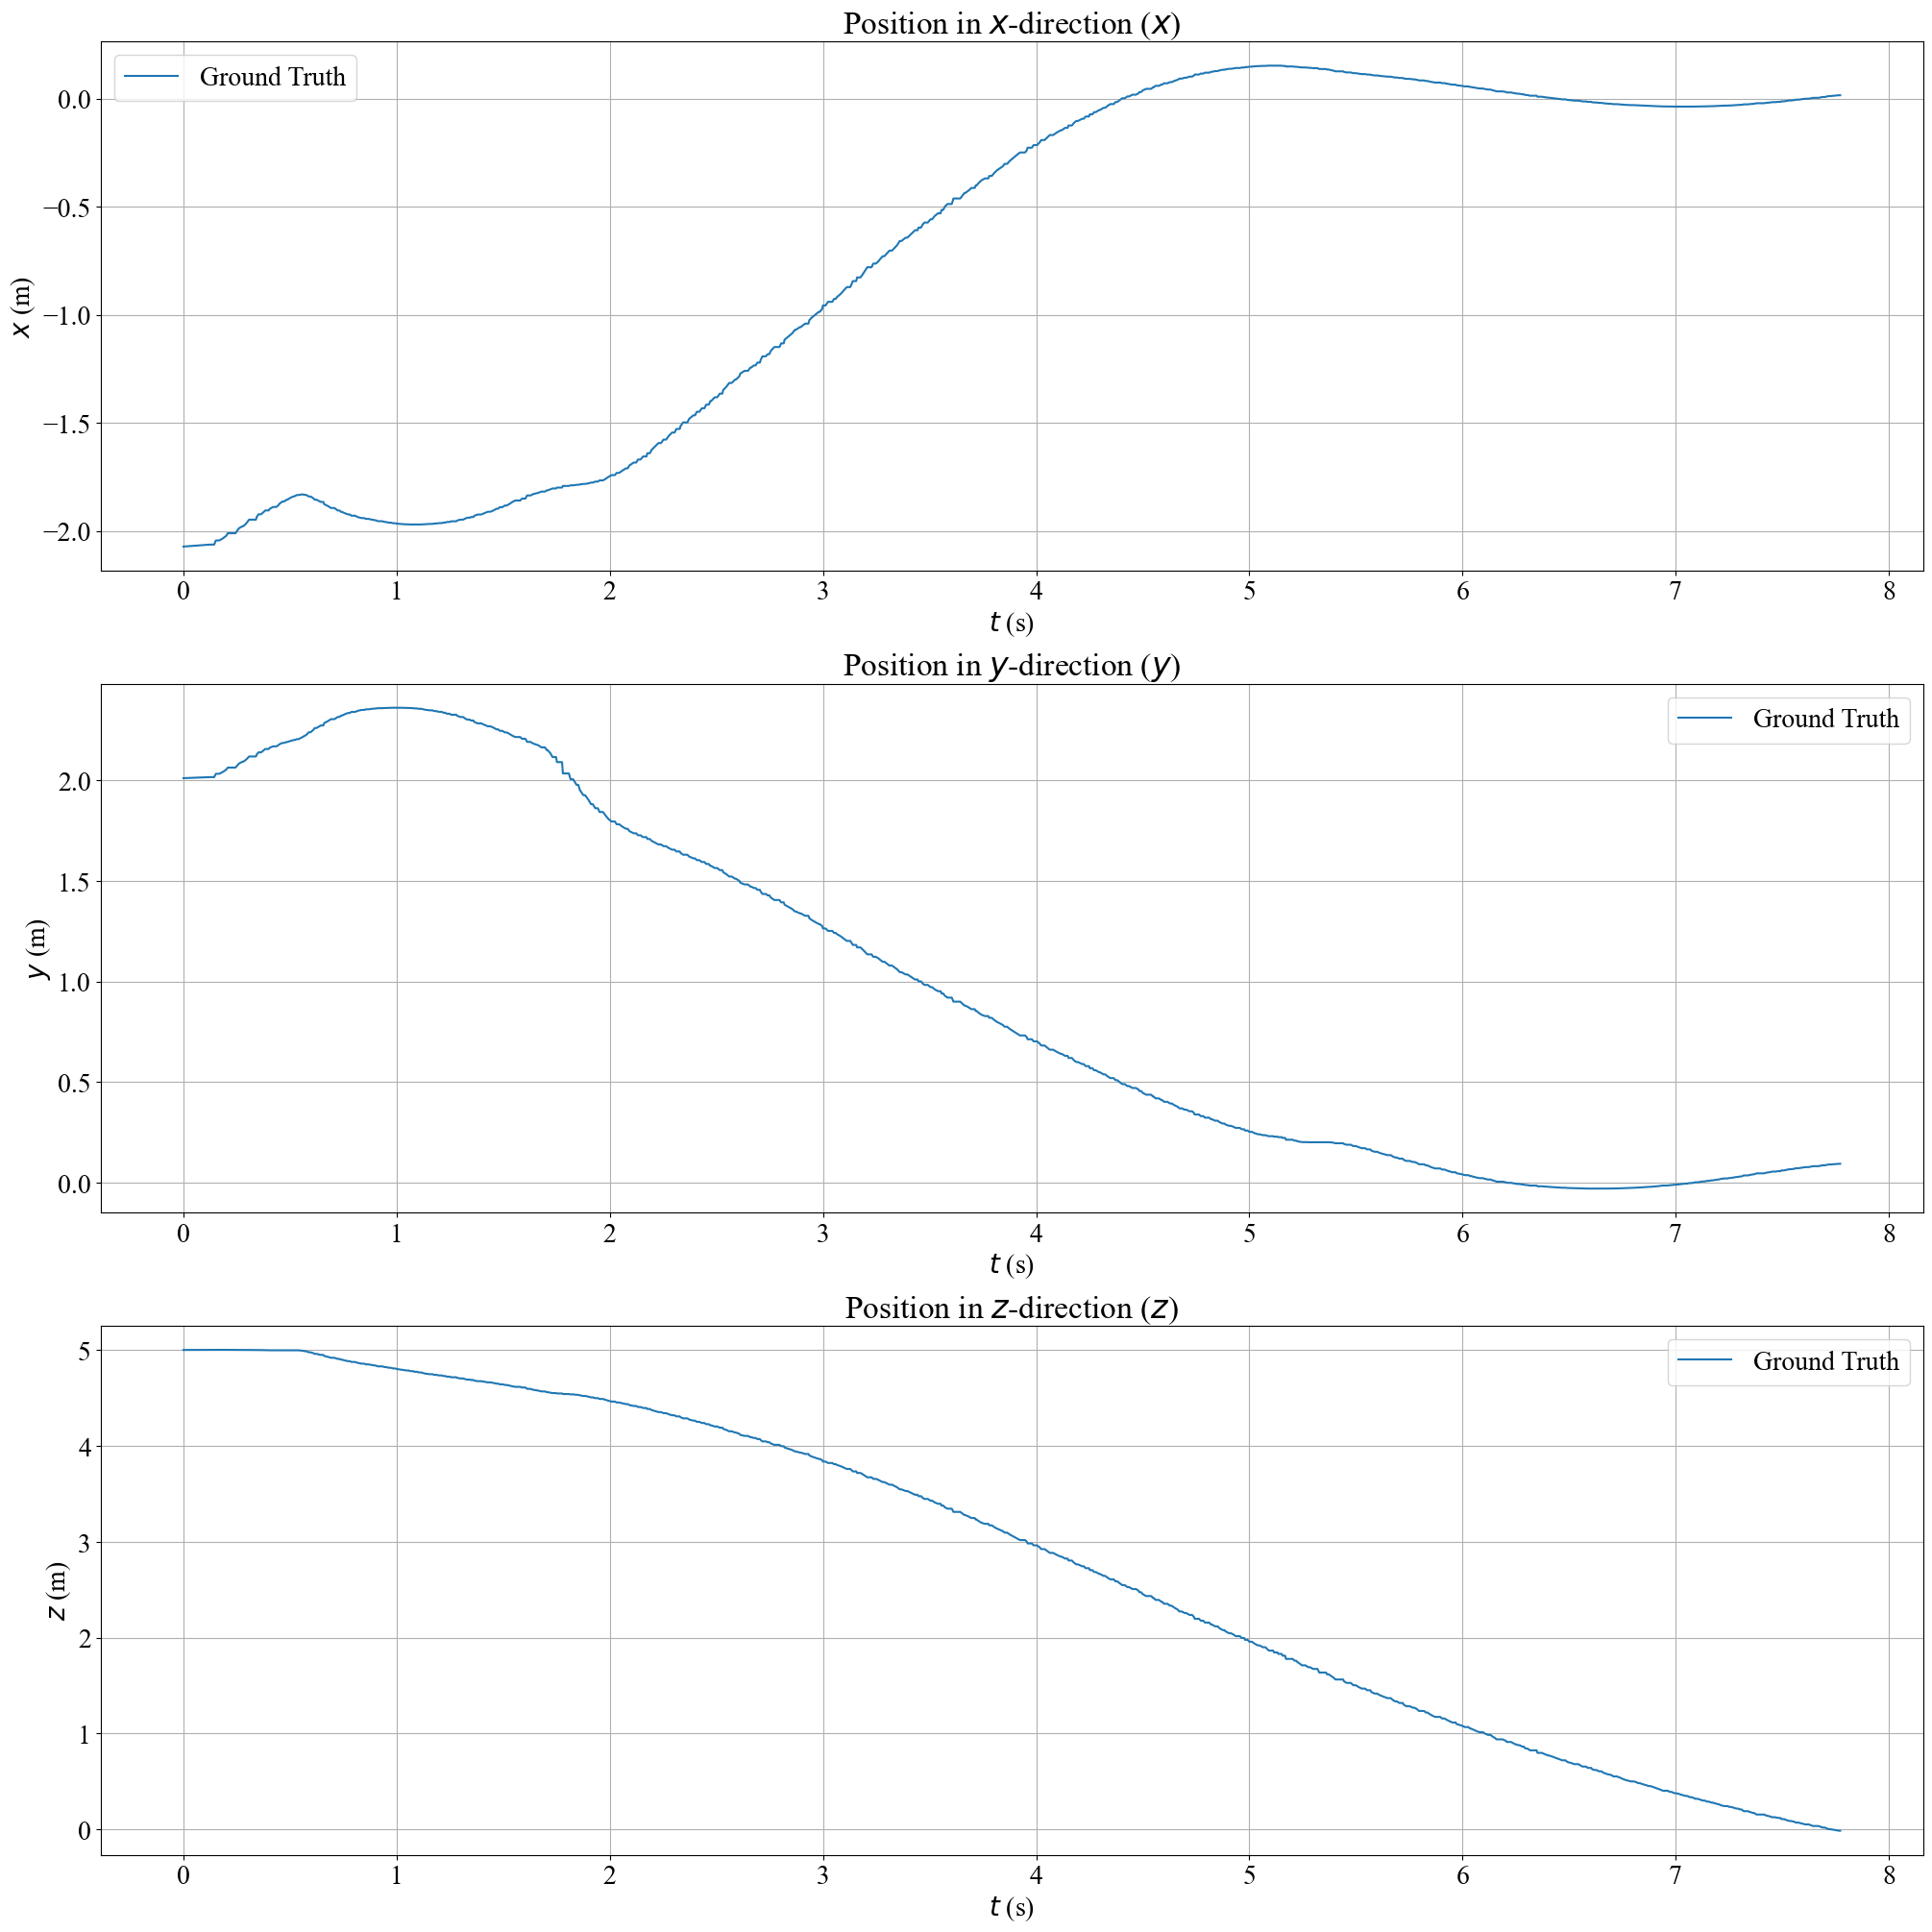

In [16]:
# Configure global plot settings
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = "20"

# Create the figure and subplots
fig, axes = plt.subplots(3, 1, figsize=(20, 20), constrained_layout=True)
# fig, axes = plt.subplots(1, 3, figsize=(20, 7), constrained_layout=True)

# Titles, labels, and data for each subplot
titles = [
    r'Position in $x$-direction ($x$)',
    r'Position in $y$-direction ($y$)',
    r'Position in $z$-direction ($z$)'
]
y_labels = [r'$x$ (m)', r'$y$ (m)', r'$z$ (m)']

# Loop through each axis and plot the data
for i, ax in enumerate(axes):
    ax.plot(t_g, B_x_tu[:, i], label='Ground Truth')
    ax.set_title(titles[i])
    ax.set_xlabel(r'$t$ (s)')
    ax.set_ylabel(y_labels[i])
    # ax.set_xlim(t_g[0],t_g[-1])
    # ax.set_ylim(-0.5, 0.5)
    ax.legend()
    ax.grid()

# Show the plot
plt.show()

### Relative Velocity ($^Bv_{tu}$) Plot

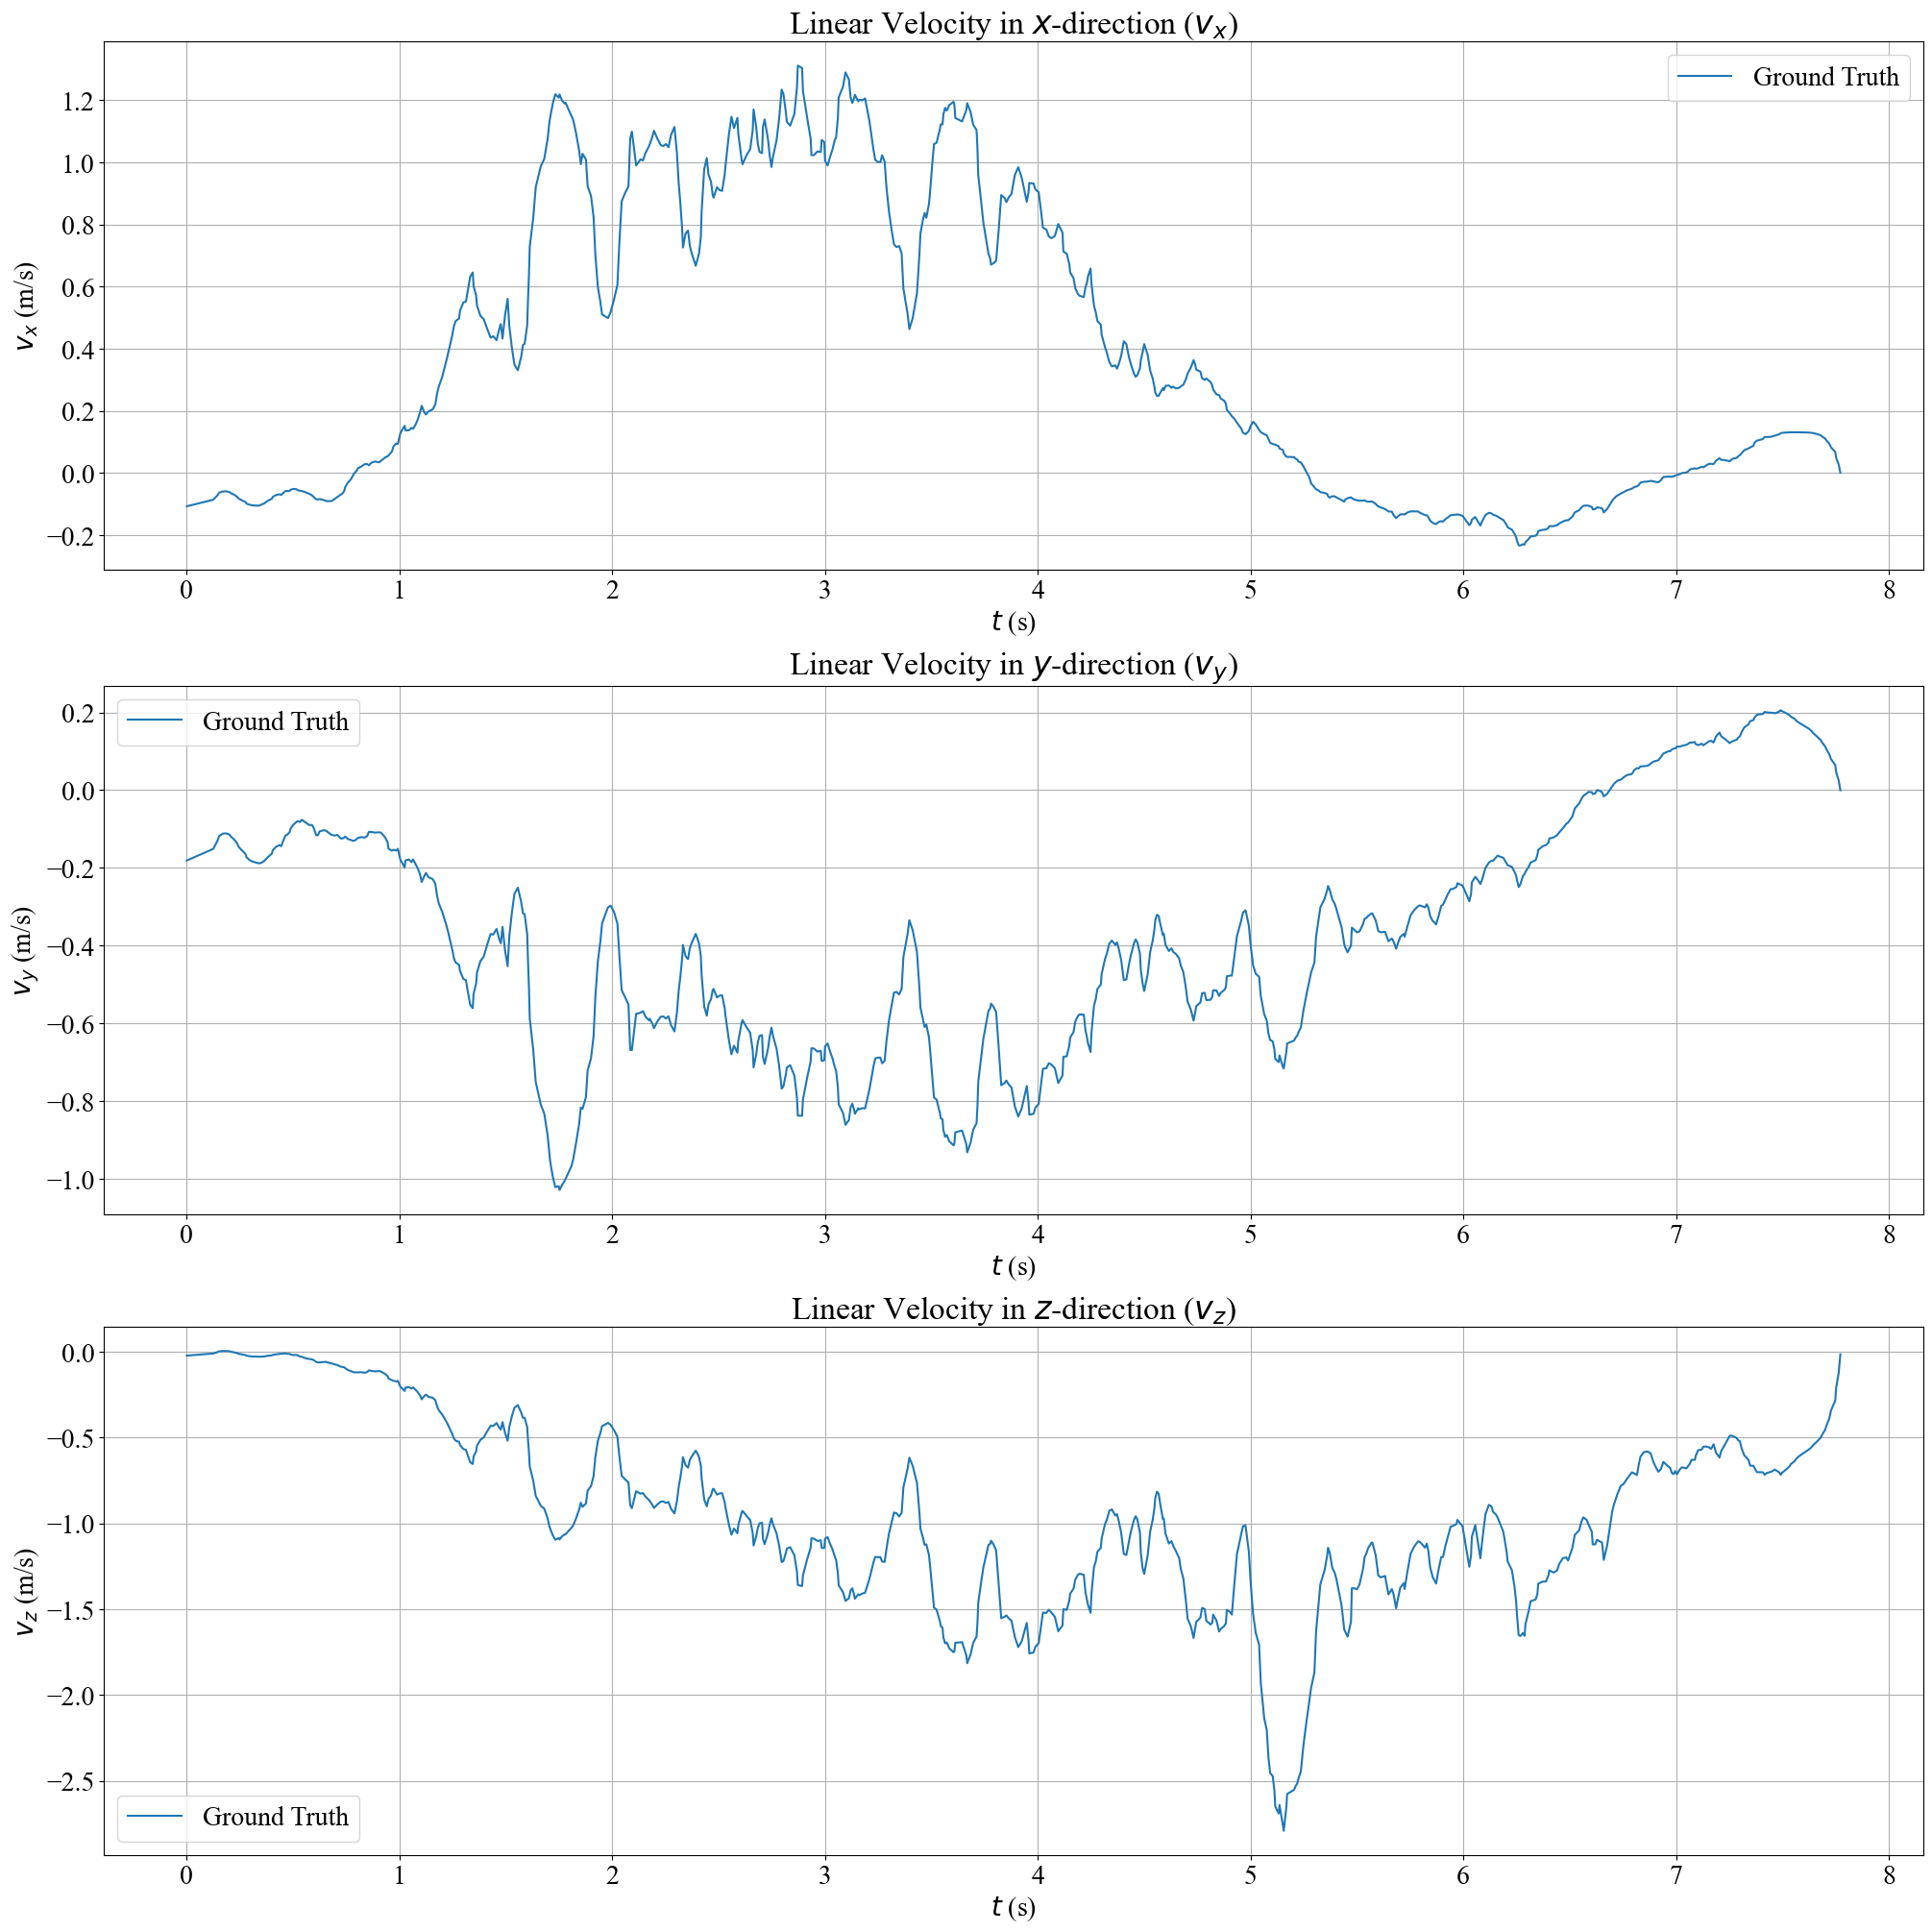

In [17]:
# Configure global plot settings
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = "20"

# Create the figure and subplots
# fig, axes = plt.subplots(1, 3, figsize=(20, 7), constrained_layout=True)
fig, axes = plt.subplots(3, 1, figsize=(20, 20), constrained_layout=True)

# Titles, labels, and data for each subplot
titles = [
    r'Linear Velocity in $x$-direction ($v_x$)',
    r'Linear Velocity in $y$-direction ($v_y$)',
    r'Linear Velocity in $z$-direction ($v_z$)'
]
y_labels = [r'$v_x$ (m/s)', r'$v_y$ (m/s)', r'$v_z$ (m/s)']

# Loop through each axis and plot the data
for i, ax in enumerate(axes):
    ax.plot(t_g, B_v_tu[:, i], label='Ground Truth')
    # ax.plot(t_g[:len(v_u)], v_u[:, i], label='Input Command')
    ax.set_title(titles[i])
    ax.set_xlabel(r'$t$ (s)')
    ax.set_ylabel(y_labels[i])
    # ax.set_xlim(t_g[0],t_g[-1])
    # ax.set_ylim(-0.5, 0.5)
    ax.legend()
    ax.grid()

# Show the plot
plt.show()

## 5. State plots

### Position ($^Br_u$) Plot

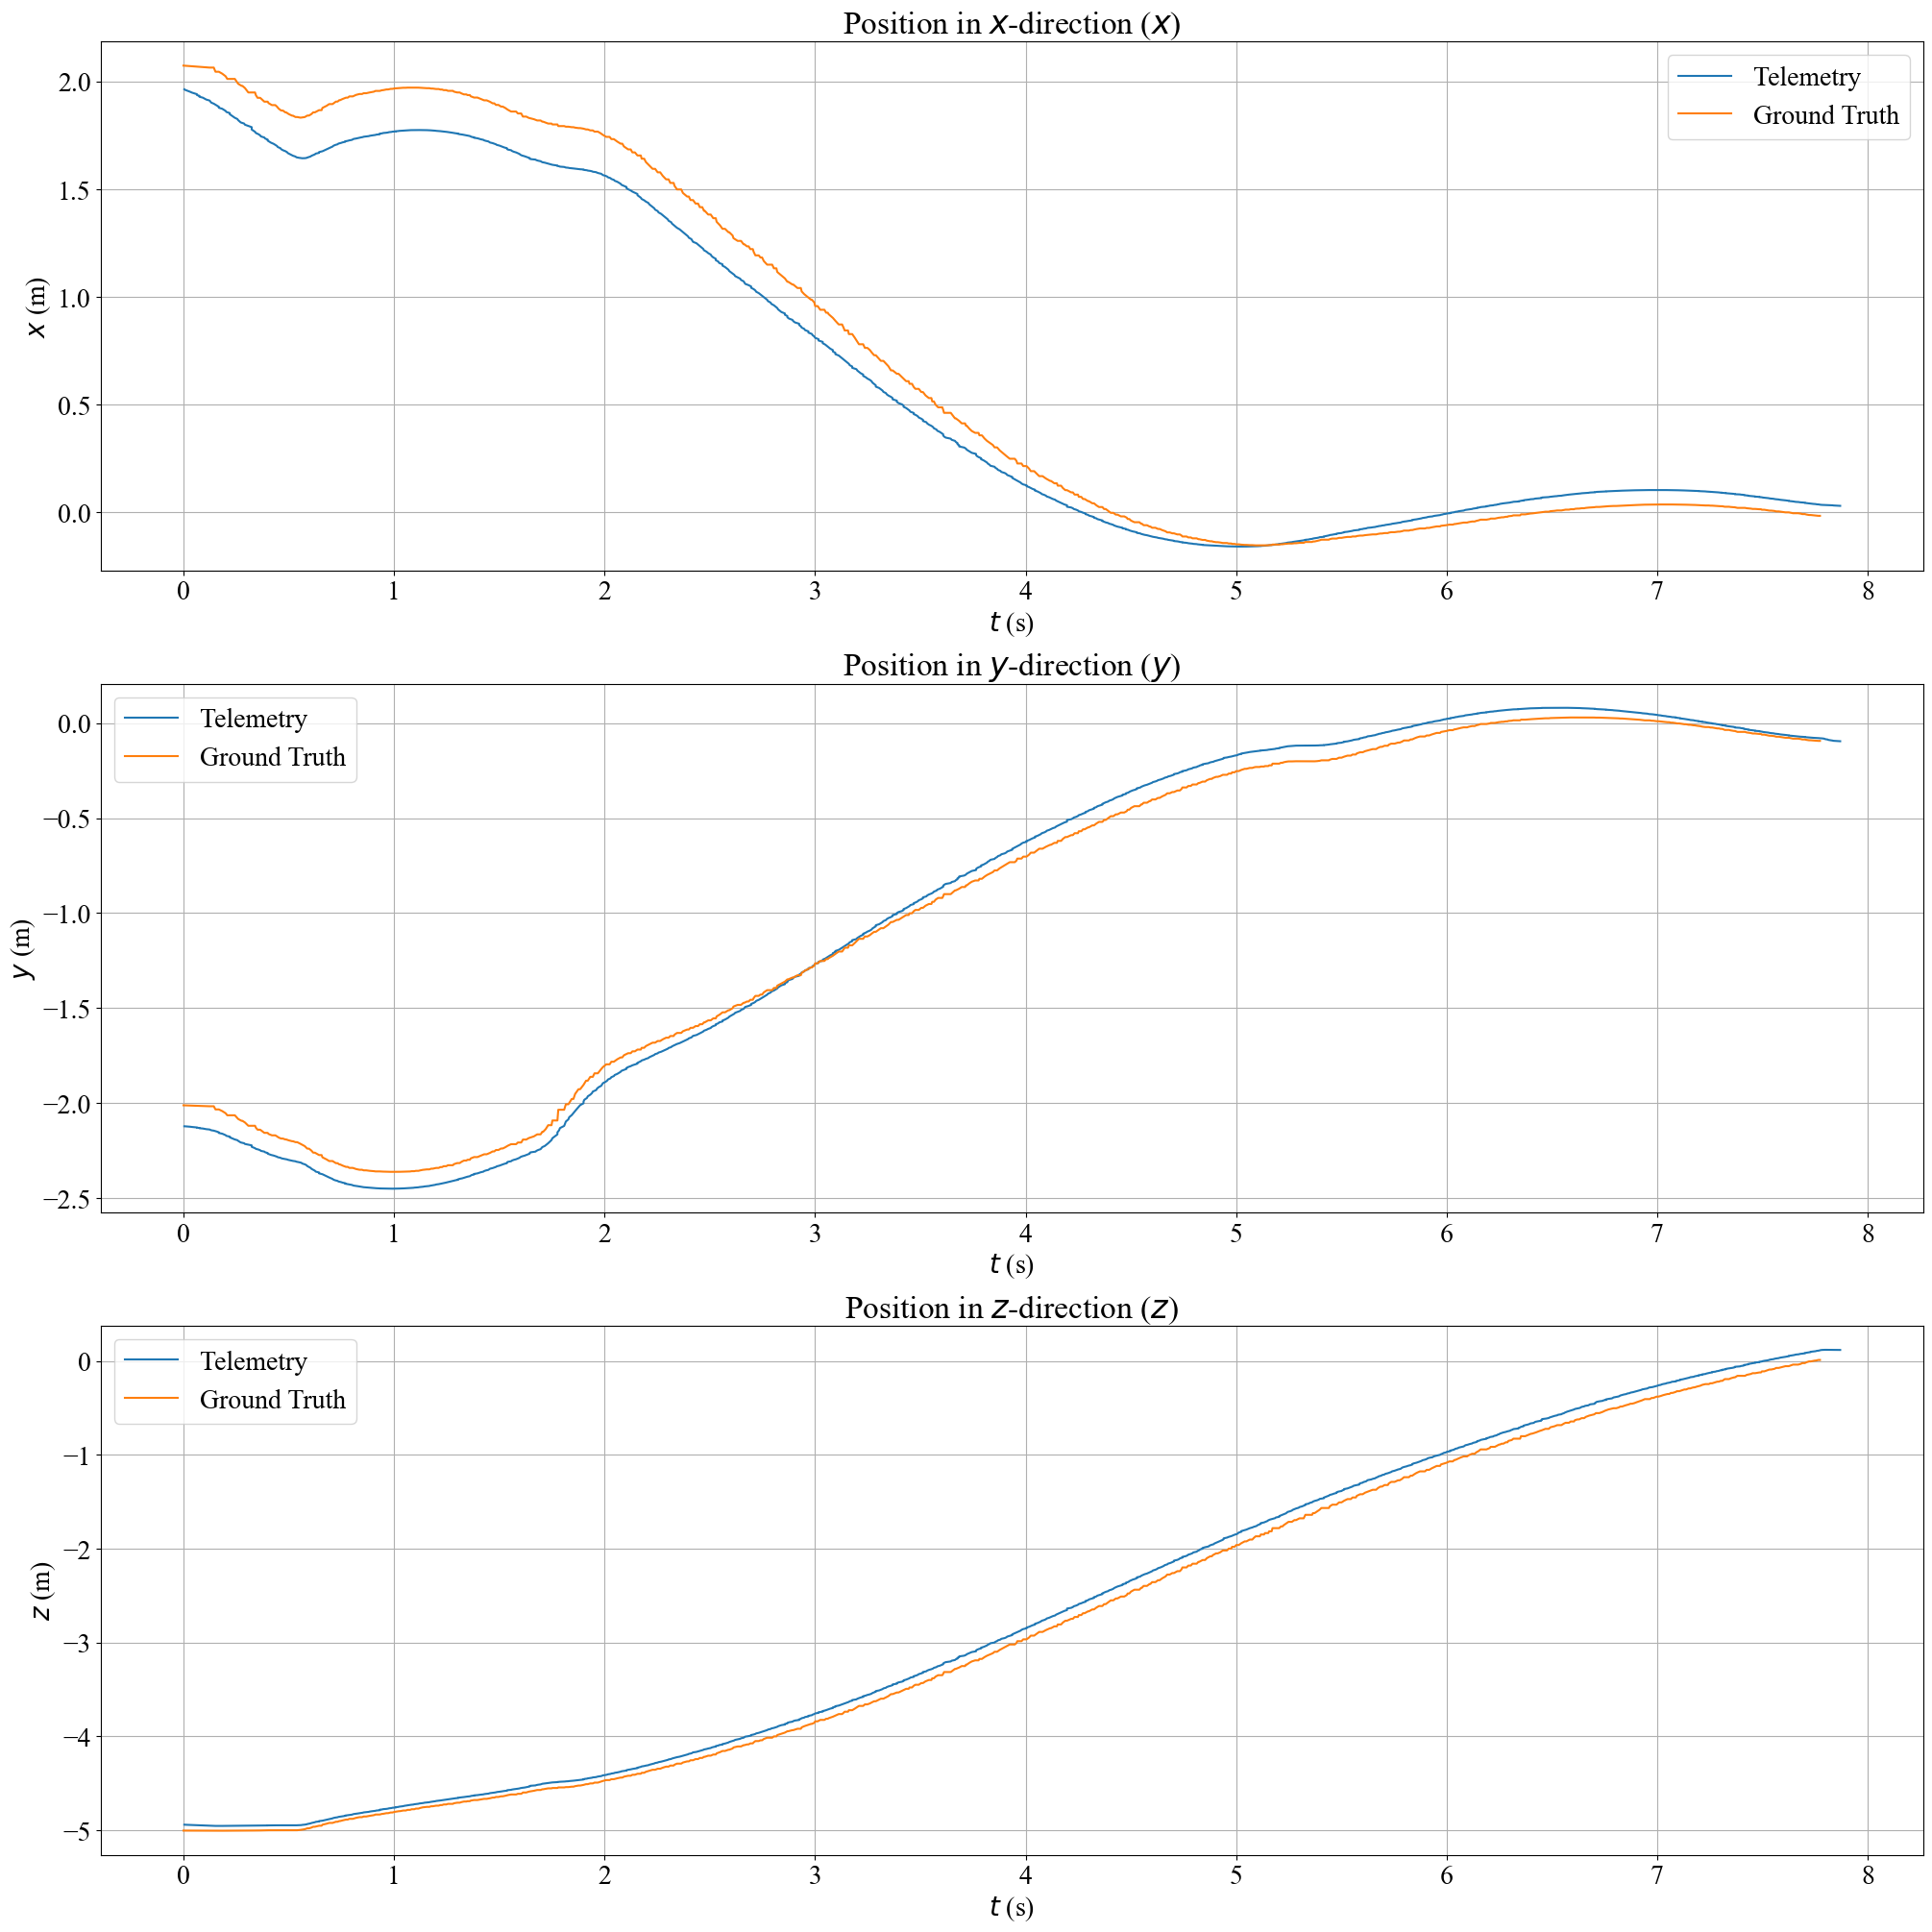

In [18]:
# Configure global plot settings
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = "20"

# Create the figure and subplots
fig, axes = plt.subplots(3, 1, figsize=(20, 20), constrained_layout=True)
# fig, axes = plt.subplots(1, 3, figsize=(20, 7), constrained_layout=True)

# Titles, labels, and data for each subplot
titles = [
    r'Position in $x$-direction ($x$)',
    r'Position in $y$-direction ($y$)',
    r'Position in $z$-direction ($z$)'
]
y_labels = [r'$x$ (m)', r'$y$ (m)', r'$z$ (m)']

# Loop through each axis and plot the data
for i, ax in enumerate(axes):
    ax.plot(t_o,B_x_ut[:, i], label='Telemetry')
    ax.plot(t_g, B_x_ug[:, i], label='Ground Truth')
    ax.set_title(titles[i])
    ax.set_xlabel(r'$t$ (s)')
    ax.set_ylabel(y_labels[i])
    # ax.set_xlim(t_g[0],t_g[-1])
    # ax.set_ylim(-0.5, 0.5)
    ax.legend()
    ax.grid()

# Show the plot
plt.show()

### Body-Fixed Linear Velocity ($^Bv$) Plot

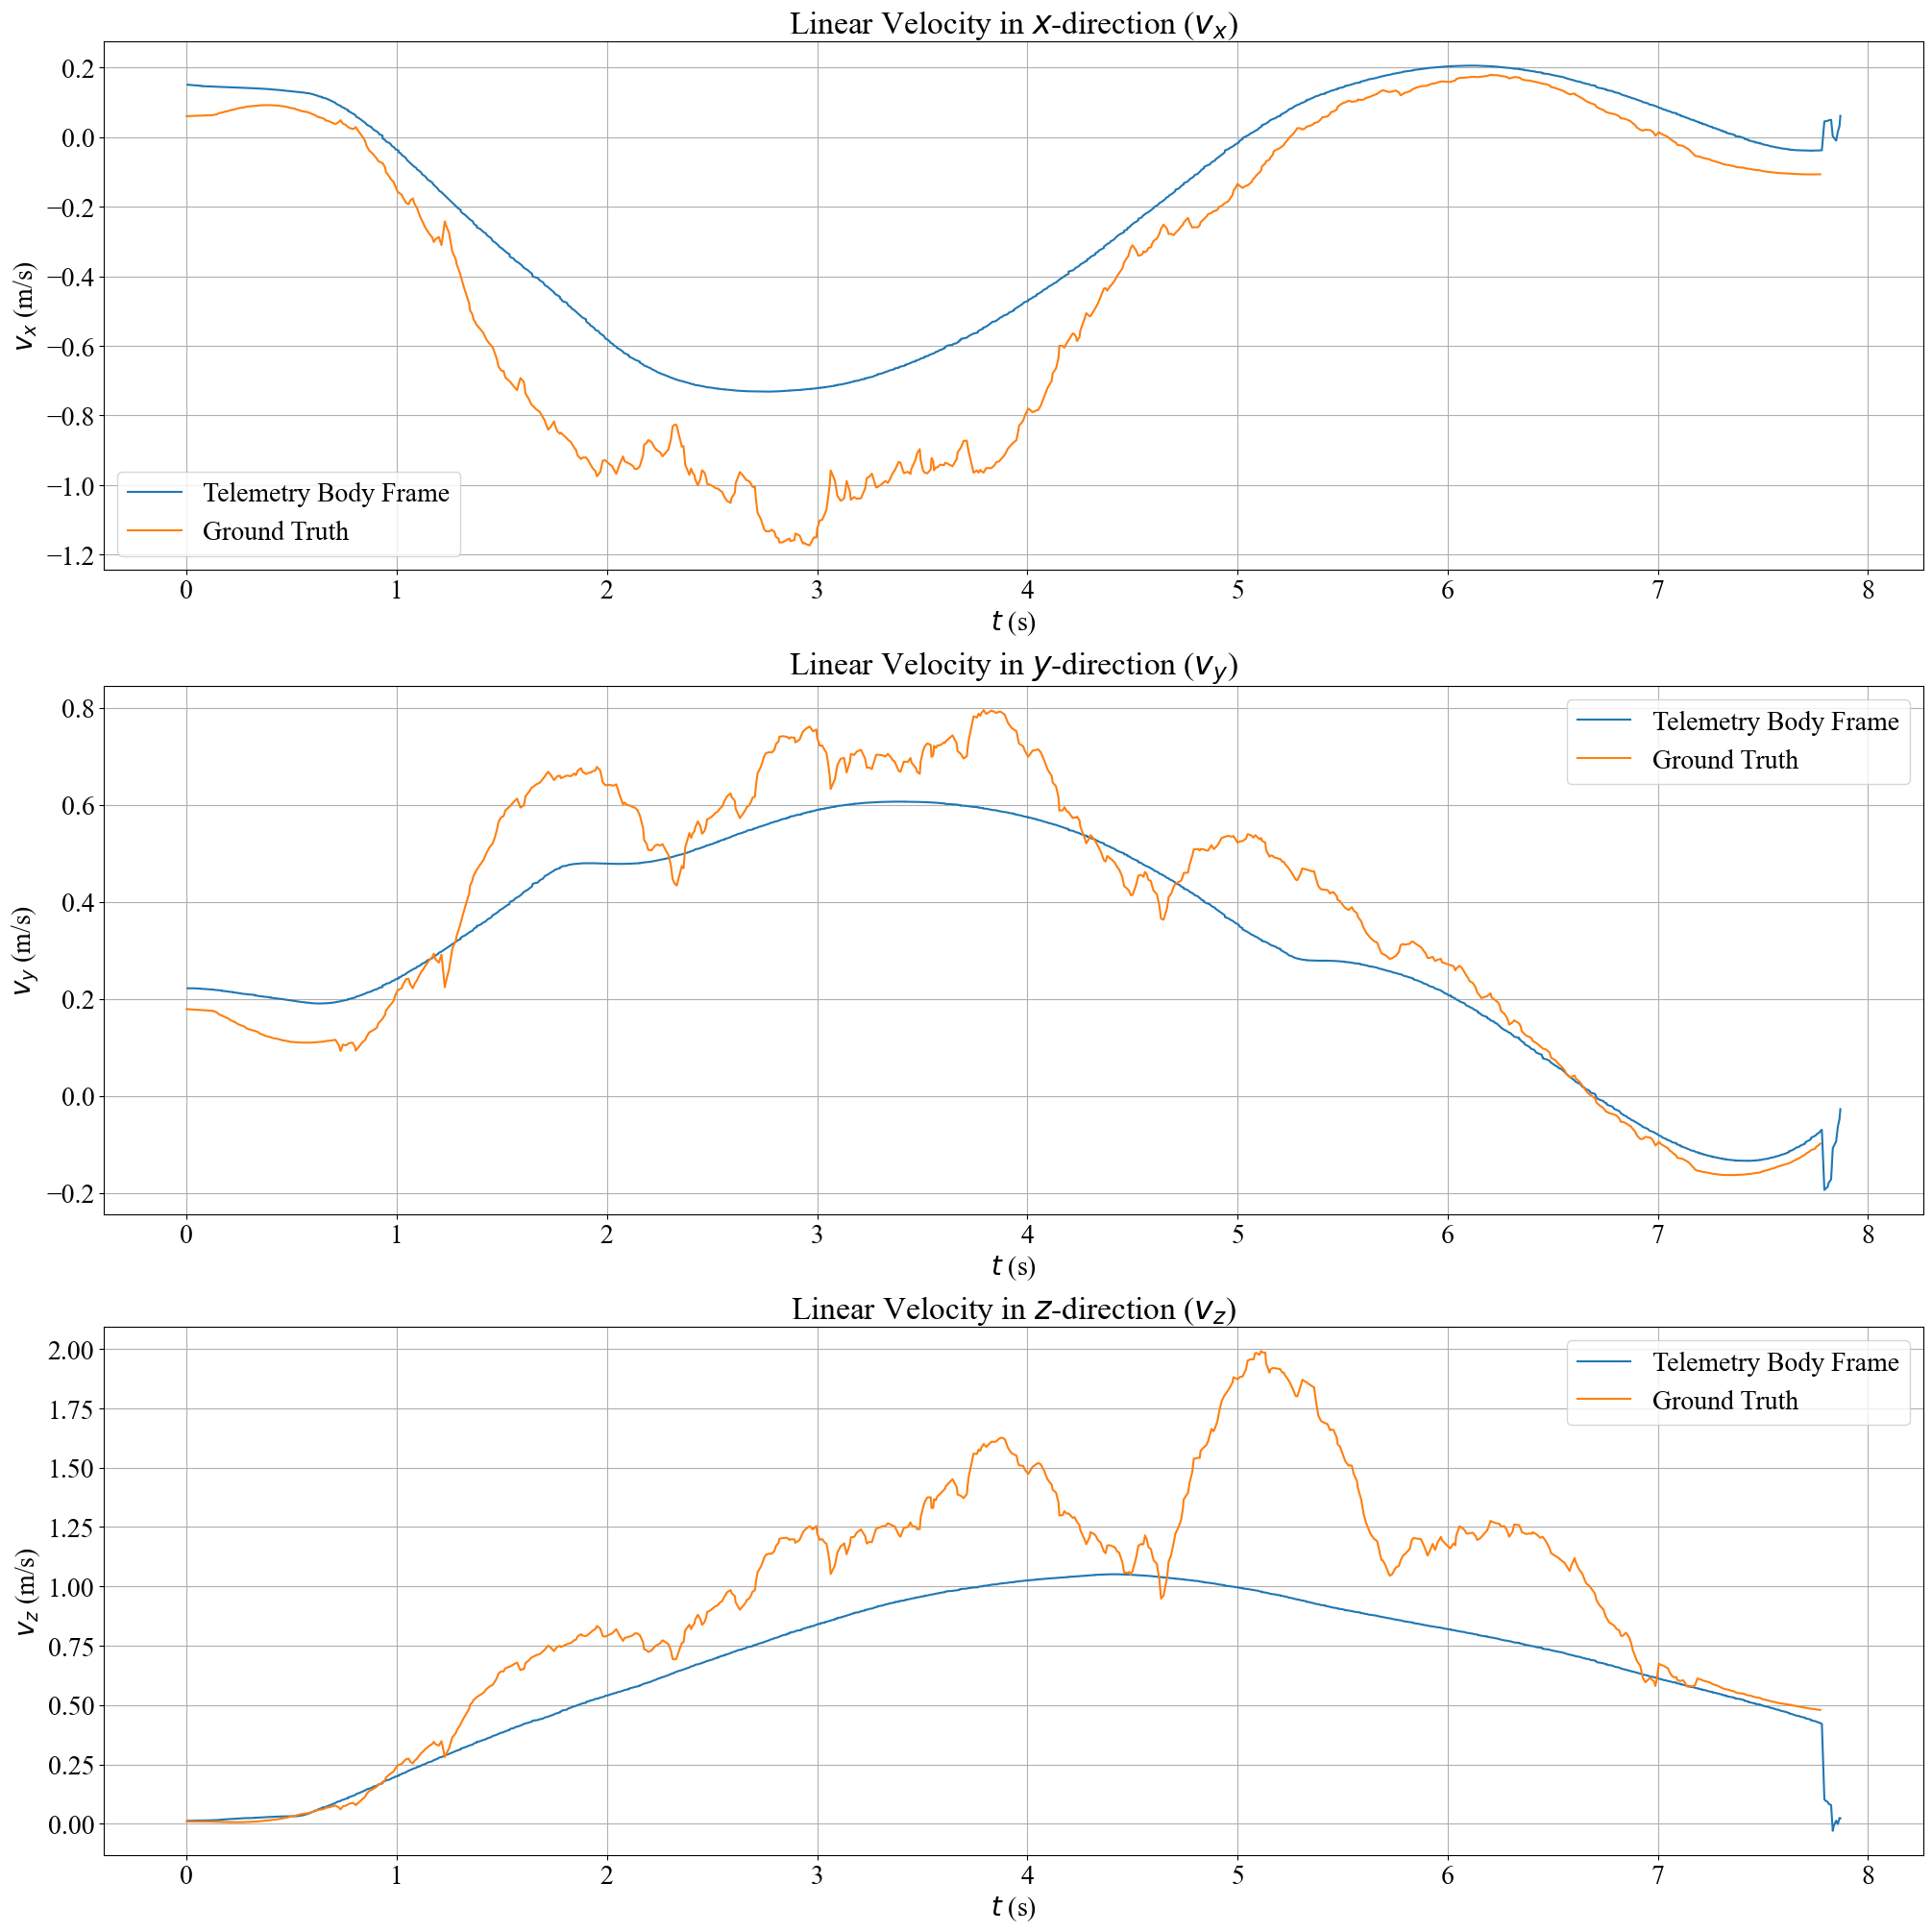

In [19]:
# Configure global plot settings
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = "20"

# Create the figure and subplots
# fig, axes = plt.subplots(1, 3, figsize=(20, 7), constrained_layout=True)
fig, axes = plt.subplots(3, 1, figsize=(20, 20), constrained_layout=True)

# Titles, labels, and data for each subplot
titles = [
    r'Linear Velocity in $x$-direction ($v_x$)',
    r'Linear Velocity in $y$-direction ($v_y$)',
    r'Linear Velocity in $z$-direction ($v_z$)'
]
y_labels = [r'$v_x$ (m/s)', r'$v_y$ (m/s)', r'$v_z$ (m/s)']

# Loop through each axis and plot the data
for i, ax in enumerate(axes):
    ax.plot(t_o, B_v_ut[:, i], label='Telemetry Body Frame')
    ax.plot(t_g, B_v_ug[:, i], label='Ground Truth')
    # ax.plot(t_g[:len(v_u)], v_u[:, i], label='Input Command')
    ax.set_title(titles[i])
    ax.set_xlabel(r'$t$ (s)')
    ax.set_ylabel(y_labels[i])
    # ax.set_xlim(t_g[0],t_g[-1])
    # ax.set_ylim(-0.5, 0.5)
    ax.legend()
    ax.grid()

# Show the plot
plt.show()

### Body-Fixed Linear Acceleration ($^Ba$) Plot

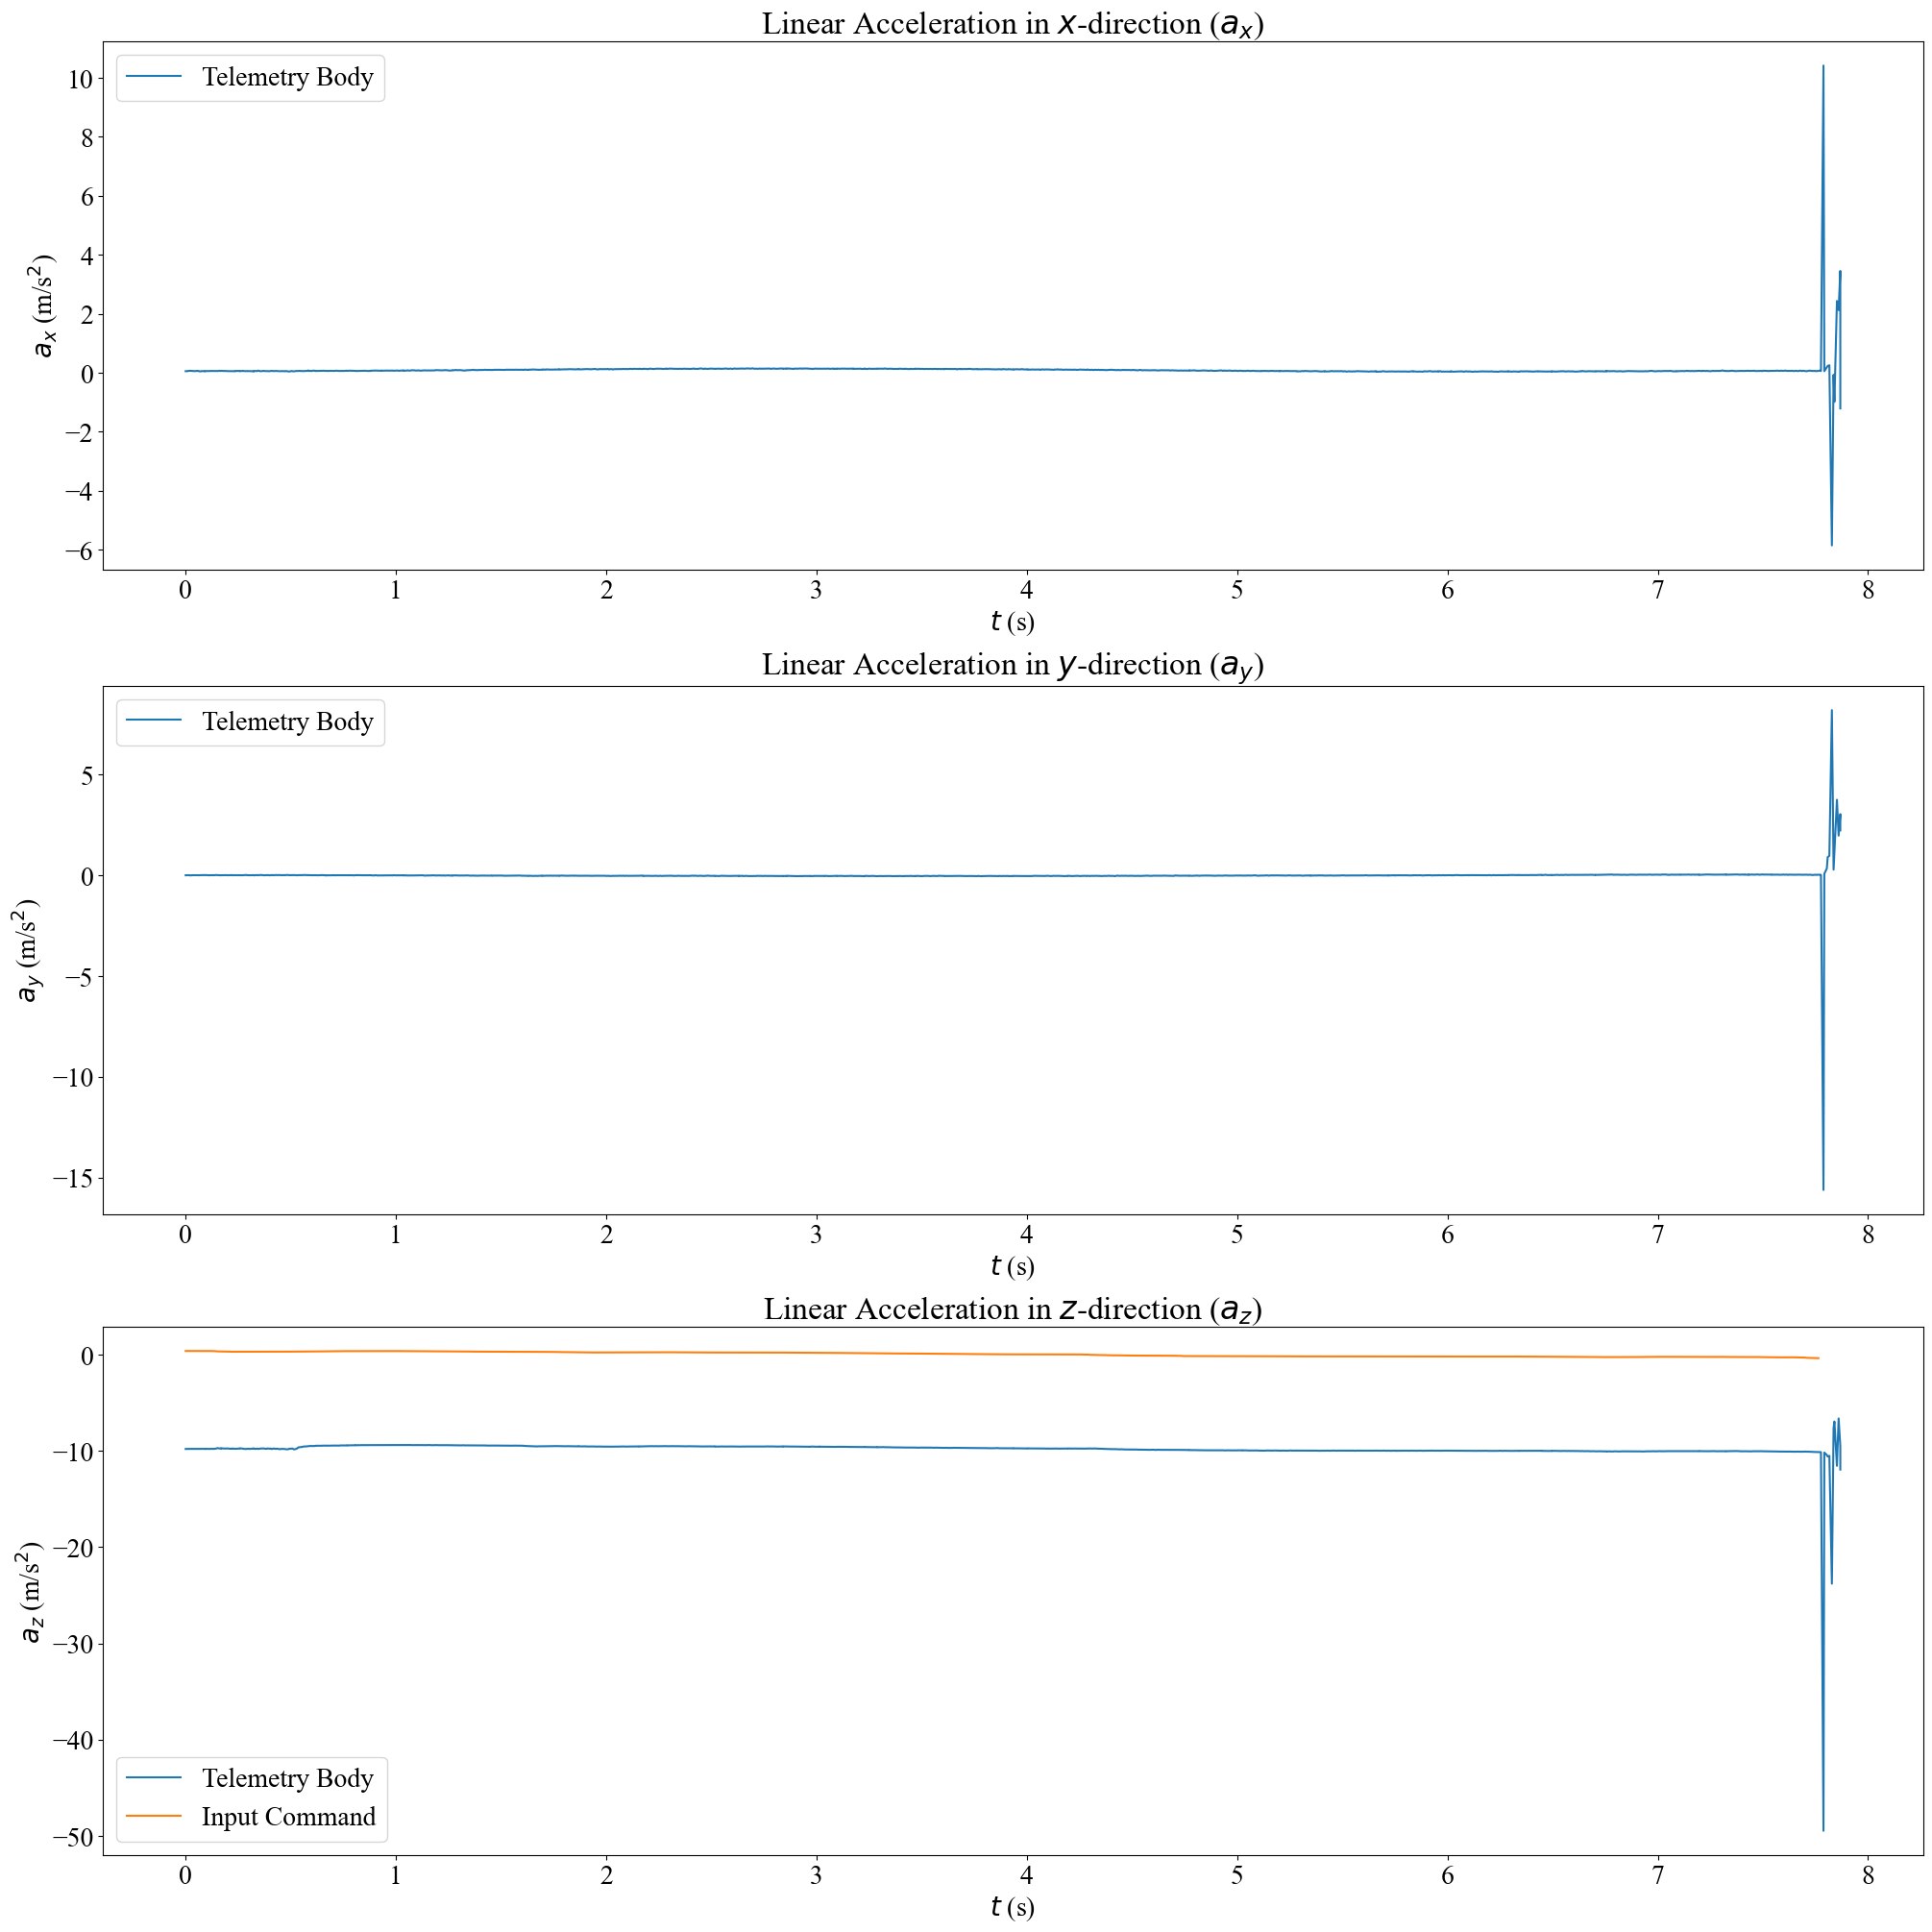

In [20]:
# Configure global plot settings
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = "20"

# Create the figure and subplots
# fig, axes = plt.subplots(1, 3, figsize=(20, 7), constrained_layout=True)
fig, axes = plt.subplots(3, 1, figsize=(20, 20), constrained_layout=True)

# Titles, labels, and data for each subplot
titles = [
    r'Linear Acceleration in $x$-direction ($a_x$)',
    r'Linear Acceleration in $y$-direction ($a_y$)',
    r'Linear Acceleration in $z$-direction ($a_z$)'
]
y_labels = [r'$a_x$ (m/s$^2$)', r'$a_y$ (m/s$^2$)', r'$a_z$ (m/s$^2$)']
g = [0,0,9.8]

# Loop through each axis and plot the data
for i, ax in enumerate(axes):
    ax.plot(t_a, a_t[:, i] + g[i]*0, label='Telemetry Body')
    if i==2:
        ax.plot(t_g[:len(T_u[1:])], T_u[1:]/mass, label='Input Command')
    ax.set_title(titles[i])
    ax.set_xlabel(r'$t$ (s)')
    ax.set_ylabel(y_labels[i])
    # ax.set_xlim(t_g[0],t_g[-1])
    # ax.set_ylim(-10.0, -9.0)
    # ax.set_ylim(-5.0, 5.0)
    ax.legend()

# Show the plot
plt.show()

### Euler Angles ($^B\Phi$) Plot

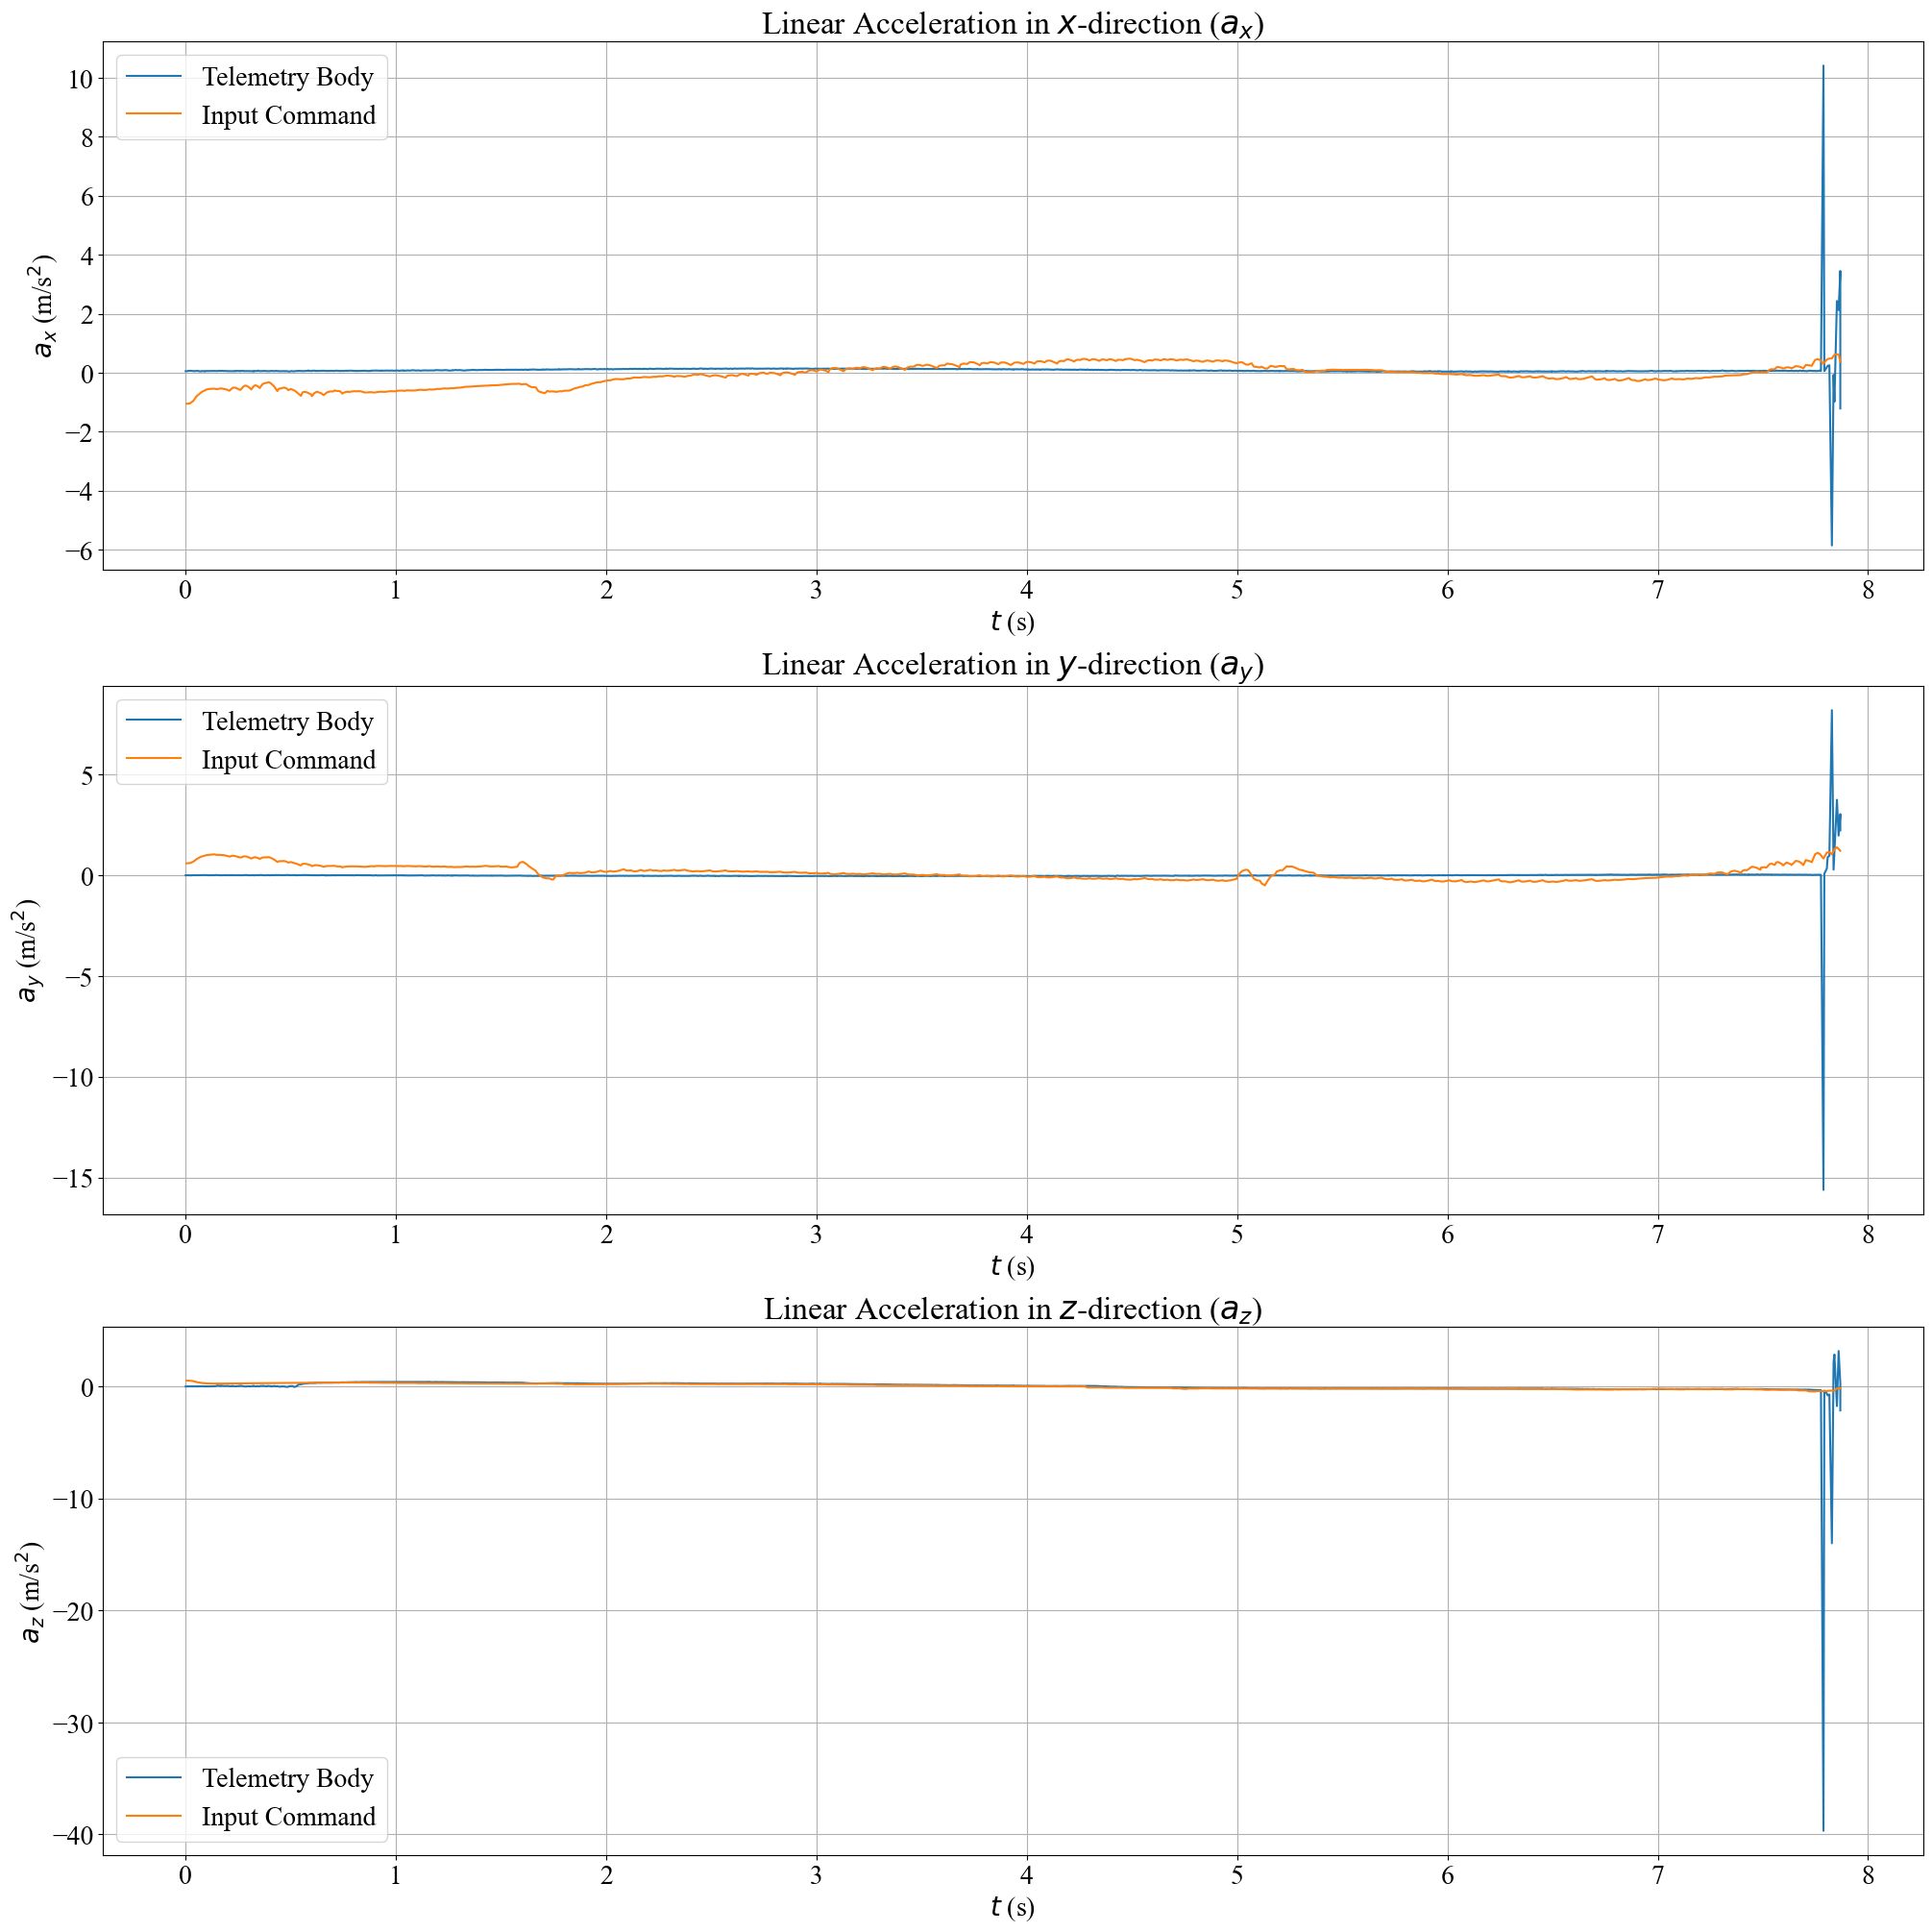

In [21]:
# Configure global plot settings
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = "20"

# Create the figure and subplots
# fig, axes = plt.subplots(1, 3, figsize=(20, 7), constrained_layout=True)
fig, axes = plt.subplots(3, 1, figsize=(20, 20), constrained_layout=True)

# Titles, labels, and data for each subplot
titles = [
    r'Linear Acceleration in $x$-direction ($a_x$)',
    r'Linear Acceleration in $y$-direction ($a_y$)',
    r'Linear Acceleration in $z$-direction ($a_z$)'
]
y_labels = [r'$a_x$ (m/s$^2$)', r'$a_y$ (m/s$^2$)', r'$a_z$ (m/s$^2$)']
g = [0,0,9.8]

# Loop through each axis and plot the data
for i, ax in enumerate(axes):
    ax.plot(t_a, a_t[:, i] + g[i], label='Telemetry Body')
    ax.plot(t_c, a_u[:, i], label='Input Command')
    ax.set_title(titles[i])
    ax.set_xlabel(r'$t$ (s)')
    ax.set_ylabel(y_labels[i])
    # ax.set_xlim(t_g[0],t_g[-1])
    # ax.set_ylim(-10.0, -9.0)
    # ax.set_ylim(-5.0, 5.0)
    ax.legend()
    ax.grid()

# Show the plot
plt.show()

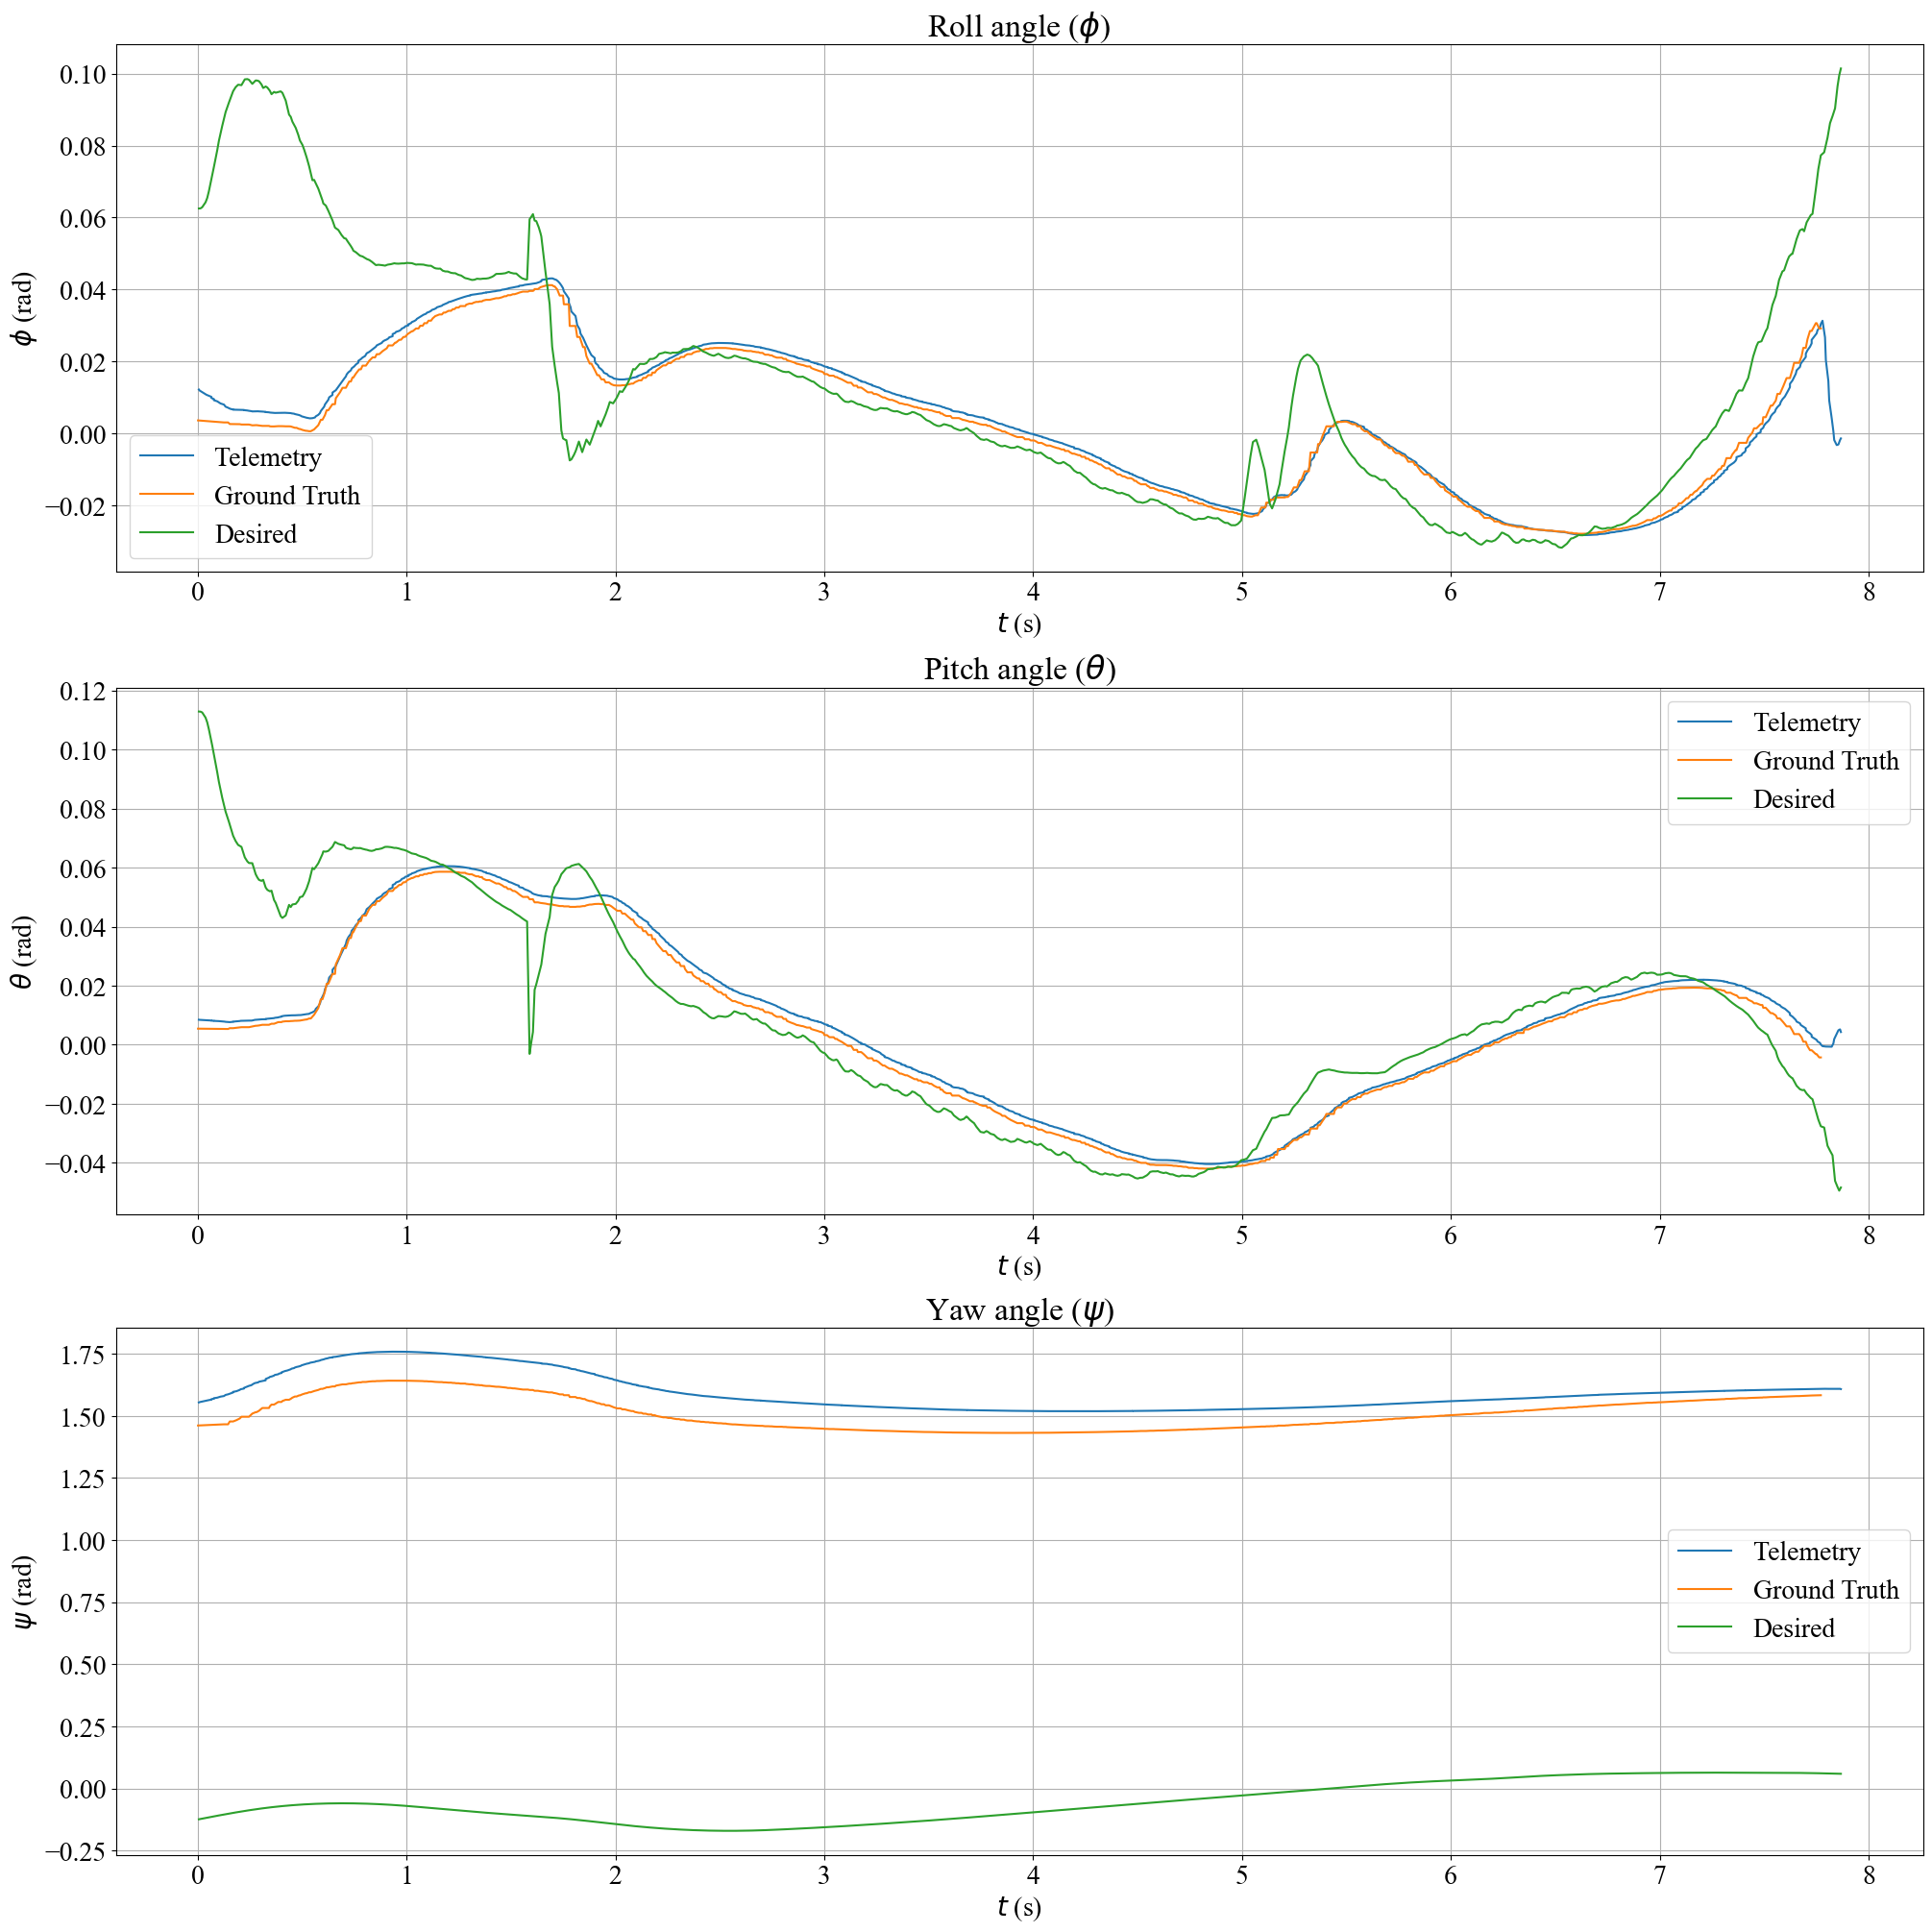

In [22]:
# Configure global plot settings
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = "20"

# Create the figure and subplots
fig, axes = plt.subplots(3, 1, figsize=(20, 20), constrained_layout=True)
# fig, axes = plt.subplots(1, 3, figsize=(20, 7), constrained_layout=True)

# Titles, labels, and data for each subplot
titles = [
    r'Roll angle ($\phi$)',
    r'Pitch angle ($\theta$)',
    r'Yaw angle ($\psi$)'
]
y_labels = [r'$\phi$ (rad)', r'$\theta$ (rad)', r'$\psi$ (rad)']

# Loop through each axis and plot the data
for i, ax in enumerate(axes):
    ax.plot(t_o,EA_t[:, i], label='Telemetry')
    ax.plot(t_g, EA_g[:, i], label='Ground Truth')
    ax.plot(t_c, EA_d[:, i], label='Desired')
    ax.set_title(titles[i])
    ax.set_xlabel(r'$t$ (s)')
    ax.set_ylabel(y_labels[i])
    # ax.set_xlim(t_g[0],t_g[-1])
    # ax.set_ylim(-0.5, 0.5)
    ax.legend()
    ax.grid()

# Show the plot
plt.show()

## 6. Output plots

### Image Parameter Error ($s_{e}$) Plot

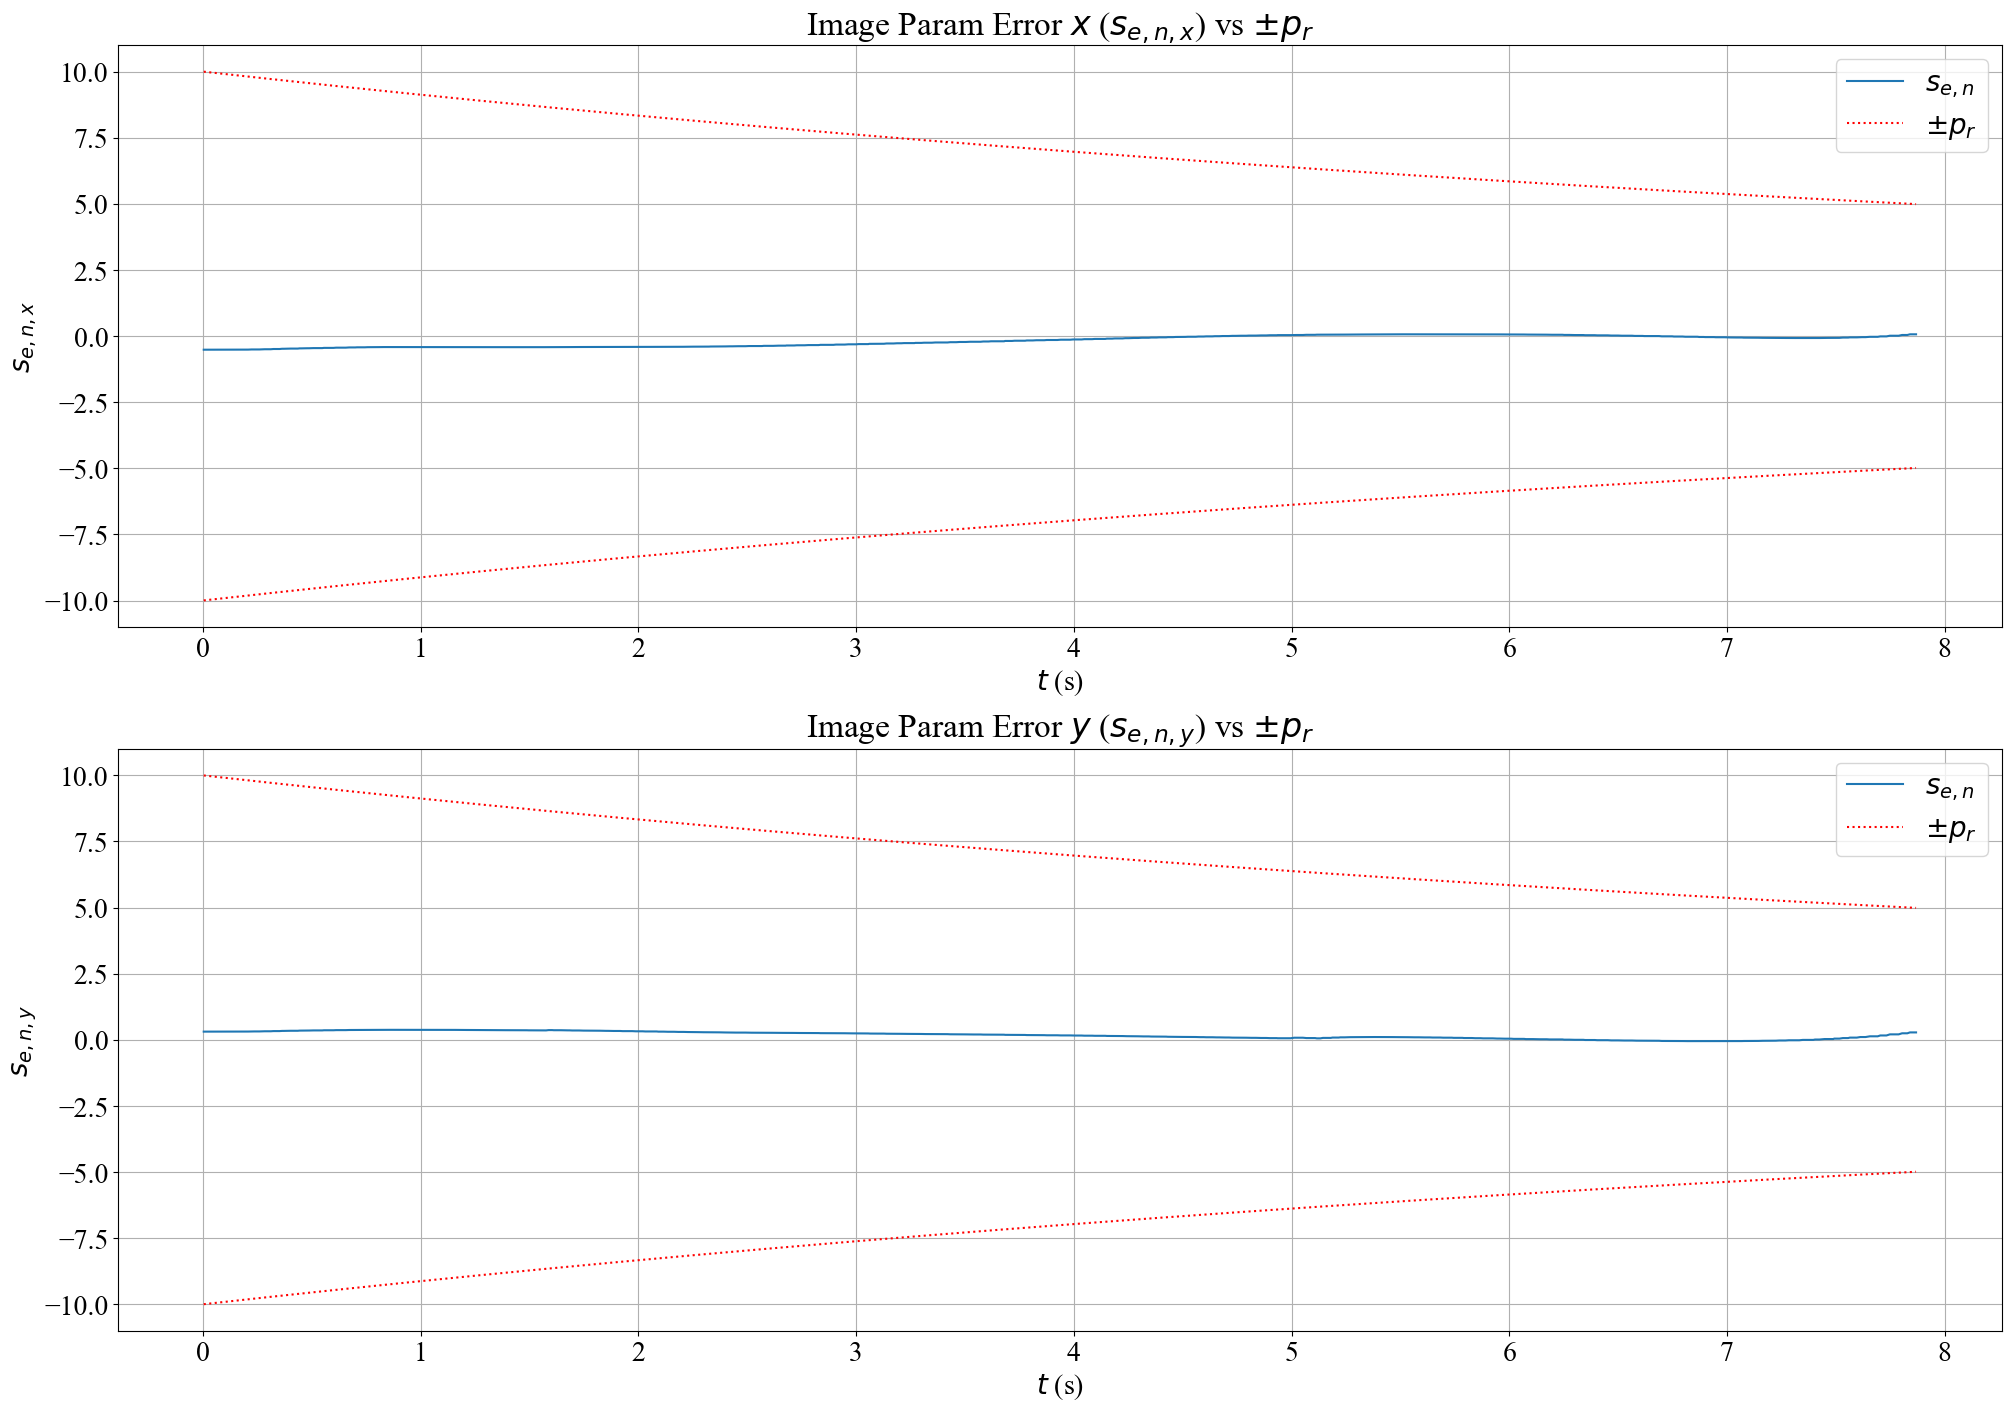

In [23]:
# Configure global plot settings
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = "20"

# s_e_n (normalized image error) vs the ACTIVE position funnel +-p_r (was the inactive +-p_v).
fig, axes = plt.subplots(2, 1, figsize=(20, 14), constrained_layout=True)
titles  = [r'Image Param Error $x$ ($s_{e,n,x}$) vs $\pm p_r$',
           r'Image Param Error $y$ ($s_{e,n,y}$) vs $\pm p_r$']
y_labels = [r'$s_{e,n,x}$', r'$s_{e,n,y}$']
for i, ax in enumerate(axes):
    ax.plot(t_c, s_e_n[:, i], label=r'$s_{e,n}$')
    if p_r is not None:
        ax.plot(t_c, p_r[:, i], ':r', label=r'$\pm p_r$'); ax.plot(t_c, -p_r[:, i], ':r')
    ax.set_title(titles[i]); ax.set_xlabel(r'$t$ (s)'); ax.set_ylabel(y_labels[i])
    ax.legend(loc='upper right'); ax.grid()
plt.show()


### $s_e$ vs GROUND TRUTH — full trajectory (re-init aware)

The Control_Data log is WIPED on a mid-flight controller re-initialization (full visibility loss →
re-acquire), so the cells above may only show the final segment. This plot reconstructs the WHOLE
flight: the GT-derived geometric centroid (via `compute_gt_signals`, the canonical V-frame GT source)
vs the measured Img feature, with the funnel clock restarting at the re-init.
Reading guide: flat stretches in the MEASURED trace are held/extrapolated phantoms (can be
sign-opposed to truth); where genuine, measured ≈ GT almost exactly.

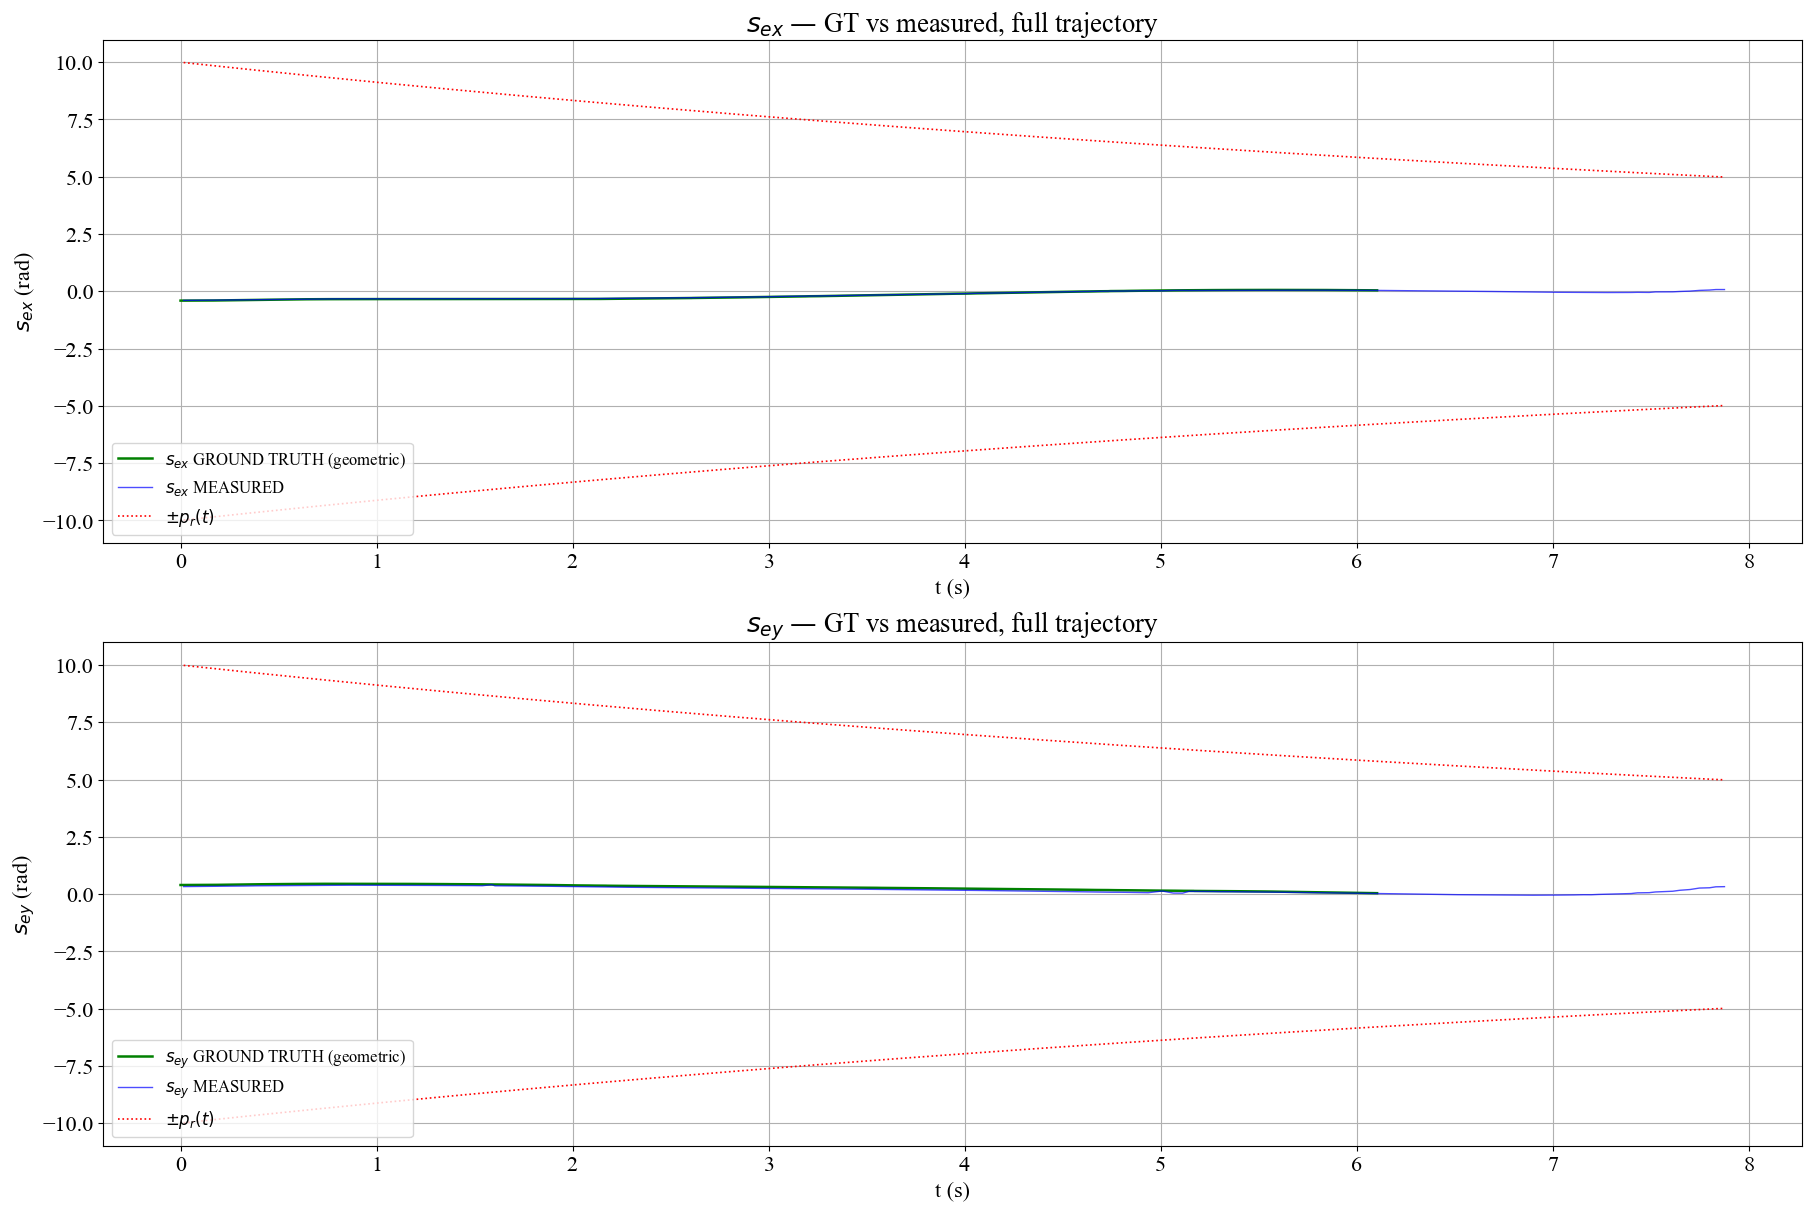

In [24]:
# ── s_e vs GROUND TRUTH, full trajectory ─────────────────────────────────────
import sys as _sys
_sys.path.insert(0, "/home/shubham/Soft-Precise-Landing/PX4_Gazebo/tools")
from aggregate_calibration_phased import compute_gt_signals as _cgs

_gtd = data["Ground_Truth"]
if len(_gtd["UAV Pose"]) == 0:
    print("✗ empty GT — skip")
else:
    _t0 = _gtd["Start Time"]
    _tg_raw, _Vh, _Vw, _Vxc, _Vyc, _vmask, _Vz = _cgs(_gtd)
    _traw = np.asarray(_gtd["Time"], dtype=float)
    _ng = min(len(_traw), len(_vmask))
    _tgt = _traw[:_ng][_vmask[:_ng]]                  # GT 'Time' is ALREADY relative to start
    _gt_s = {0: _Vxc[:len(_tgt)], 1: _Vyc[:len(_tgt)]}

    _ti = np.array(data["Img_Data"]["Time"], dtype=float) - _t0
    _fp = np.array(data["Img_Data"]["Feature Params"], dtype=float)
    _mi = _ti >= 0
    _treinit = float(np.asarray(data["Control_Data"]["t"], dtype=float)[0]) - _t0  # ~0 if no re-init

    plt.rcParams["font.family"] = "Times New Roman"; plt.rcParams["font.size"] = "16"
    _fig, _axes = plt.subplots(2, 1, figsize=(18, 12), constrained_layout=True)
    for _i, (_ax, _lab) in enumerate(zip(_axes, ["x", "y"])):
        _ax.plot(_tgt, _gt_s[_i], "g-", lw=1.8, label=f"$s_{{e{_lab}}}$ GROUND TRUTH (geometric)")
        _ax.plot(_ti[_mi], _fp[_mi][:, _i], "b-", lw=1.0, alpha=0.7, label=f"$s_{{e{_lab}}}$ MEASURED")
        if p_r is not None:                       # ACTIVE position funnel +-p_r (interp onto img clock)
            _pri = np.interp(_ti[_mi], t_c, p_r[:, _i])
            _ax.plot(_ti[_mi], _pri, "r:", lw=1.2); _ax.plot(_ti[_mi], -_pri, "r:", lw=1.2, label="$\\pm p_r(t)$")
        if _treinit > 0.5:
            _ax.axvline(_treinit, color="gray", ls="--", lw=1, label=f"controller RE-INIT @ {_treinit:.1f}s")
        _ax.set_title(f"$s_{{e{_lab}}}$ — GT vs measured, full trajectory")
        _ax.set_xlabel("t (s)"); _ax.set_ylabel(f"$s_{{e{_lab}}}$ (rad)"); _ax.grid(True)
        _ax.legend(loc="lower left", fontsize=12)
    plt.show()

### Combined-barrier position funnel ($s_{e,n}$ vs $p_r$) — convergence & terminal 1/Z

Uses the **directly-logged** combined-barrier position funnel `p_r(t)` / `zeta_r(t)` (the surface term $\chi_r\zeta_r$ acts on $\bar r_e=s_{e,n}$), not the reconstructed back-mapped sen-funnel `p_v`. Convergence/precision is governed by whether the funnel forces the error toward its steep edge ($|S_r|=|s_{e,n}|/p_r\to1$). The terminal 1/Z spike in $|\bar r_e|=\mathrm{lat}/(Z\varphi)$ breaches iff $p_r$ has collapsed (fast $\xi_r$) and can't absorb it; a wide terminal $p_r$ (large PR0 + slow XIR + $p_{r\infty}\ge1$) absorbs it.

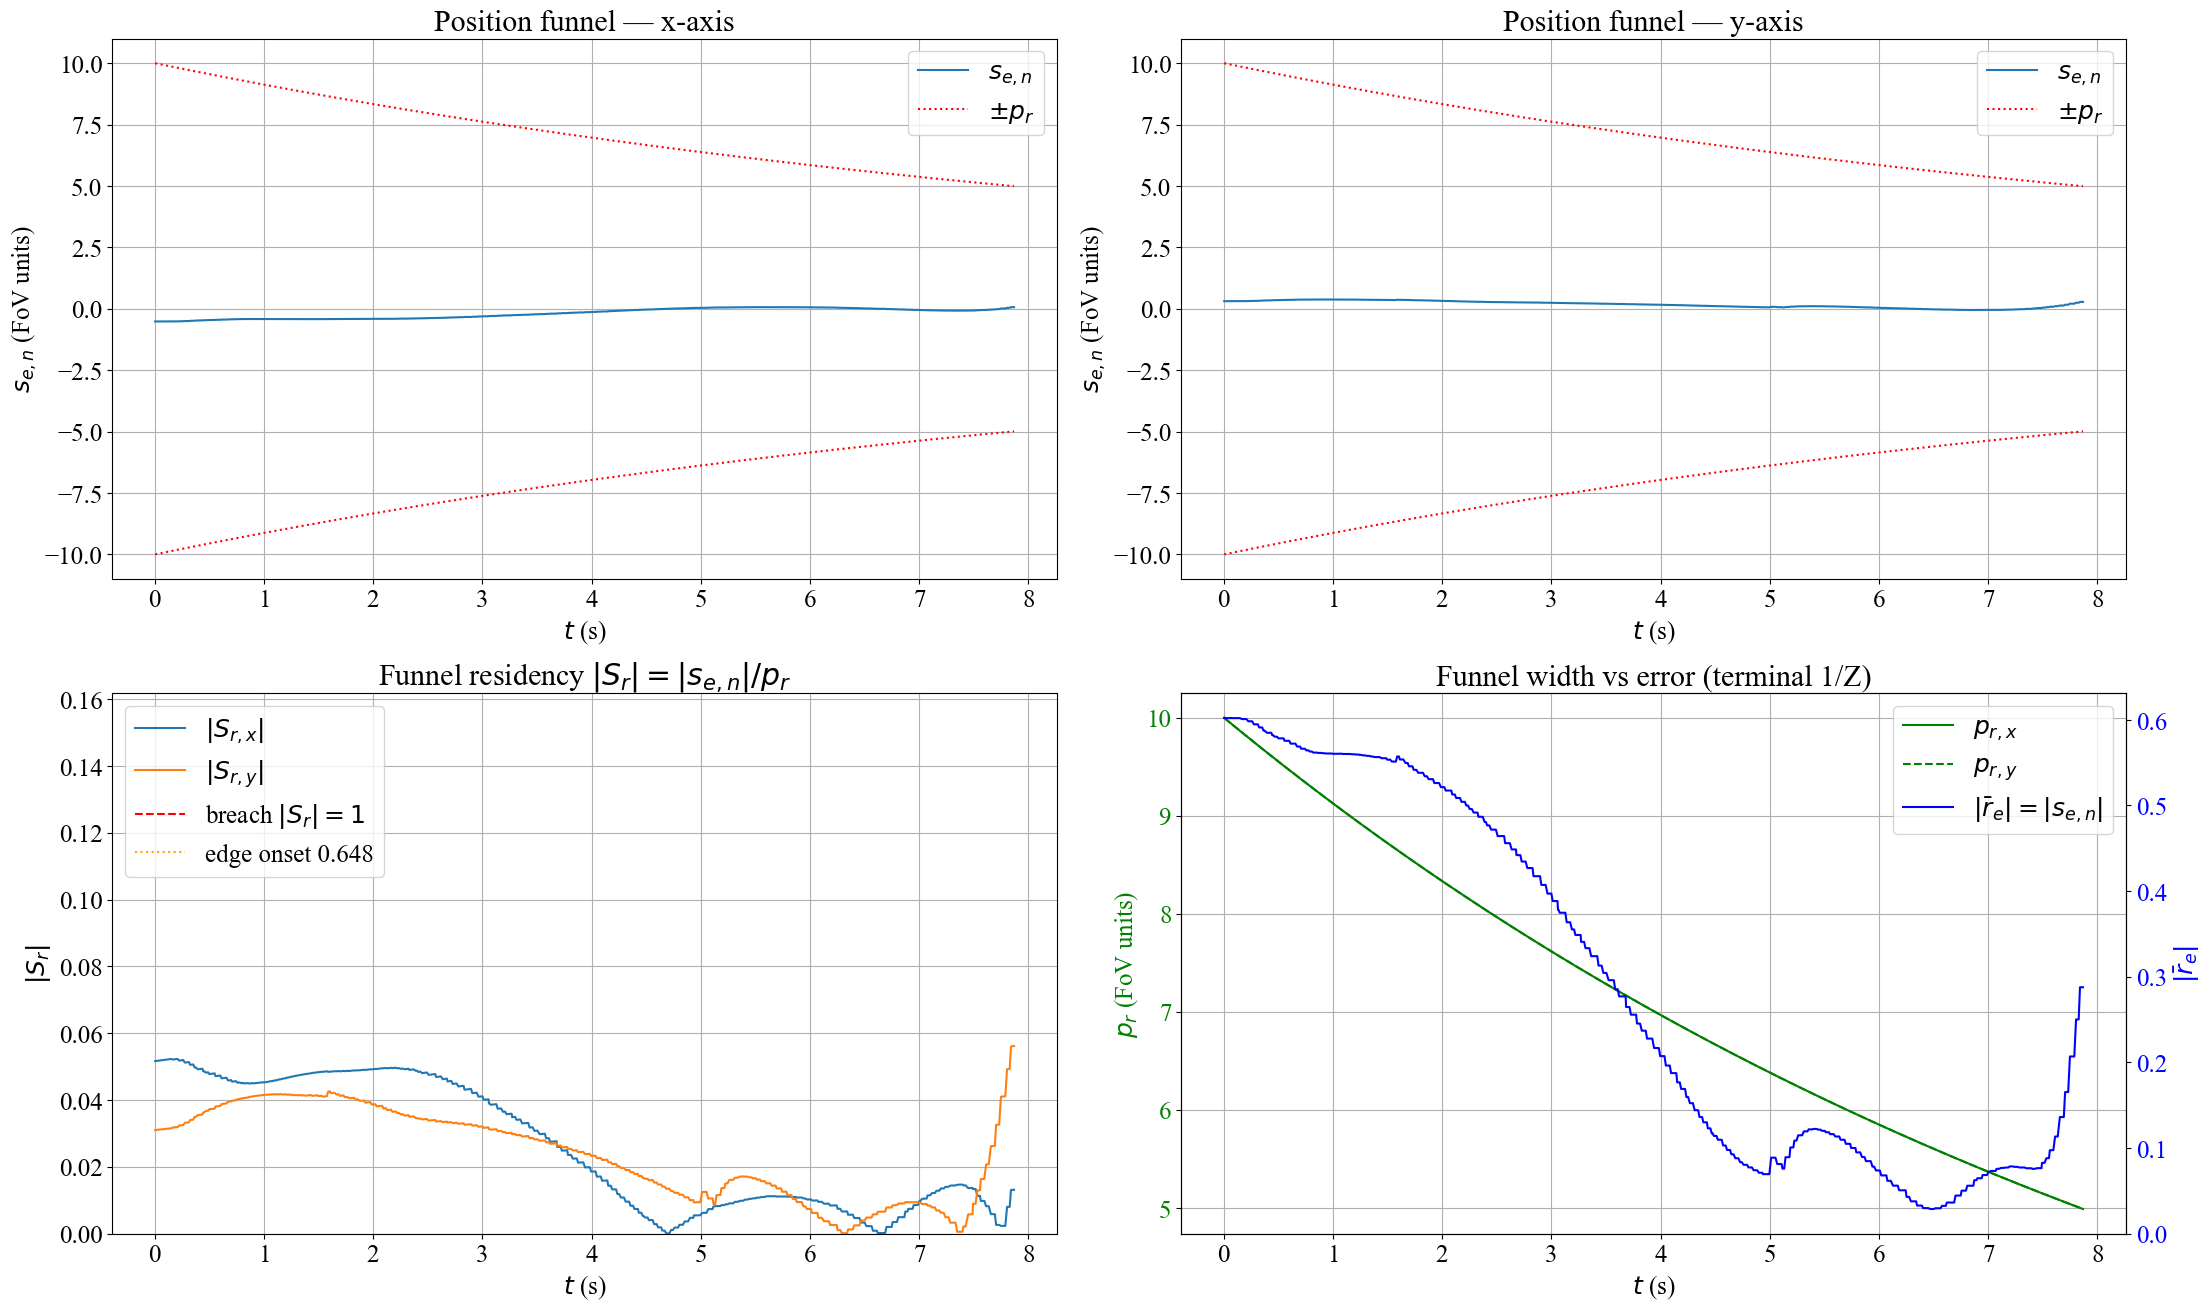

maxSr=0.06 | breach@None of flight | terminal p_r(T)=4.99 | terminal |s_e_n|=0.16 | min|s_e_n|=0.029


In [25]:
# ── Combined-barrier position funnel: s_e_n vs p_r, residency S_r, terminal 1/Z ──
# Self-contained: reuses t_c, N1, s_e_n from the control-data preprocessing cell.
if p_r is not None:                                          # global p_r from the preprocessing cell
    sen_xy  = s_e_n[:, :2]
    S_r     = sen_xy / p_r                                   # signed residency
    S_r_mag = np.max(np.abs(S_r), axis=1)                    # worst-axis |S_r|
    rbar    = np.linalg.norm(sen_xy, axis=1)                 # |r_bar_e| = |s_e_n|

    plt.rcParams['font.family'] = 'Times New Roman'; plt.rcParams['font.size'] = '18'
    fig, ax = plt.subplots(2, 2, figsize=(22, 13), constrained_layout=True)

    for j, nm in enumerate(('x', 'y')):
        a = ax[0, j]
        a.plot(t_c, sen_xy[:, j], label=r'$s_{e,n}$')
        a.plot(t_c,  p_r[:, j], ':r', label=r'$\pm p_r$'); a.plot(t_c, -p_r[:, j], ':r')
        a.set_title(f'Position funnel — {nm}-axis'); a.set_xlabel(r'$t$ (s)')
        a.set_ylabel(r'$s_{e,n}$ (FoV units)'); a.grid(); a.legend(loc='upper right')

    a = ax[1, 0]
    a.plot(t_c, np.abs(S_r[:, 0]), label=r'$|S_{r,x}|$')
    a.plot(t_c, np.abs(S_r[:, 1]), label=r'$|S_{r,y}|$')
    a.axhline(1.0, color='r', ls='--', label='breach $|S_r|=1$')
    a.axhline(0.648, color='orange', ls=':', label='edge onset 0.648')
    a.set_title(r'Funnel residency $|S_r|=|s_{e,n}|/p_r$'); a.set_xlabel(r'$t$ (s)')
    a.set_ylabel(r'$|S_r|$'); a.grid(); a.legend(loc='upper left')
    a.set_ylim(0, min(5.0, float(np.nanmax(S_r_mag)) * 1.1 + 0.1))

    a = ax[1, 1]
    a.plot(t_c, p_r[:, 0], 'g-', label=r'$p_{r,x}$'); a.plot(t_c, p_r[:, 1], 'g--', label=r'$p_{r,y}$')
    a.set_xlabel(r'$t$ (s)'); a.set_ylabel(r'$p_r$ (FoV units)', color='g')
    a.tick_params(axis='y', labelcolor='g'); a.grid()
    a2 = a.twinx(); a2.plot(t_c, rbar, 'b-', label=r'$|\bar r_e|=|s_{e,n}|$')
    a2.set_ylabel(r'$|\bar r_e|$', color='b'); a2.tick_params(axis='y', labelcolor='b')
    a.set_title('Funnel width vs error (terminal 1/Z)')
    h1, l1 = a.get_legend_handles_labels(); h2, l2 = a2.get_legend_handles_labels()
    a.legend(h1 + h2, l1 + l2, loc='upper right')
    plt.show()

    # numeric summary (matches the by-hand funnel-shape A/B)
    n = len(t_c); s0 = int(n * 0.1)
    _idx = np.where(S_r_mag[s0:] >= 1.0)[0]
    _breach = round((t_c[s0 + _idx[0]] - t_c[0]) / (t_c[-1] - t_c[0]), 2) if len(_idx) else None
    print(f'maxSr={S_r_mag.max():.2f} | breach@{_breach} of flight | '
          f'terminal p_r(T)={np.linalg.norm(p_r[-1]) / np.sqrt(2):.2f} | '
          f'terminal |s_e_n|={rbar[-max(1, int(n * 0.05)):].mean():.2f} | min|s_e_n|={rbar.min():.3f}')
else:
    print("No p_r (non-combined / back-mapped run) - position funnel unavailable.")


### Optic Flow Error ($h_{e}$) Plot

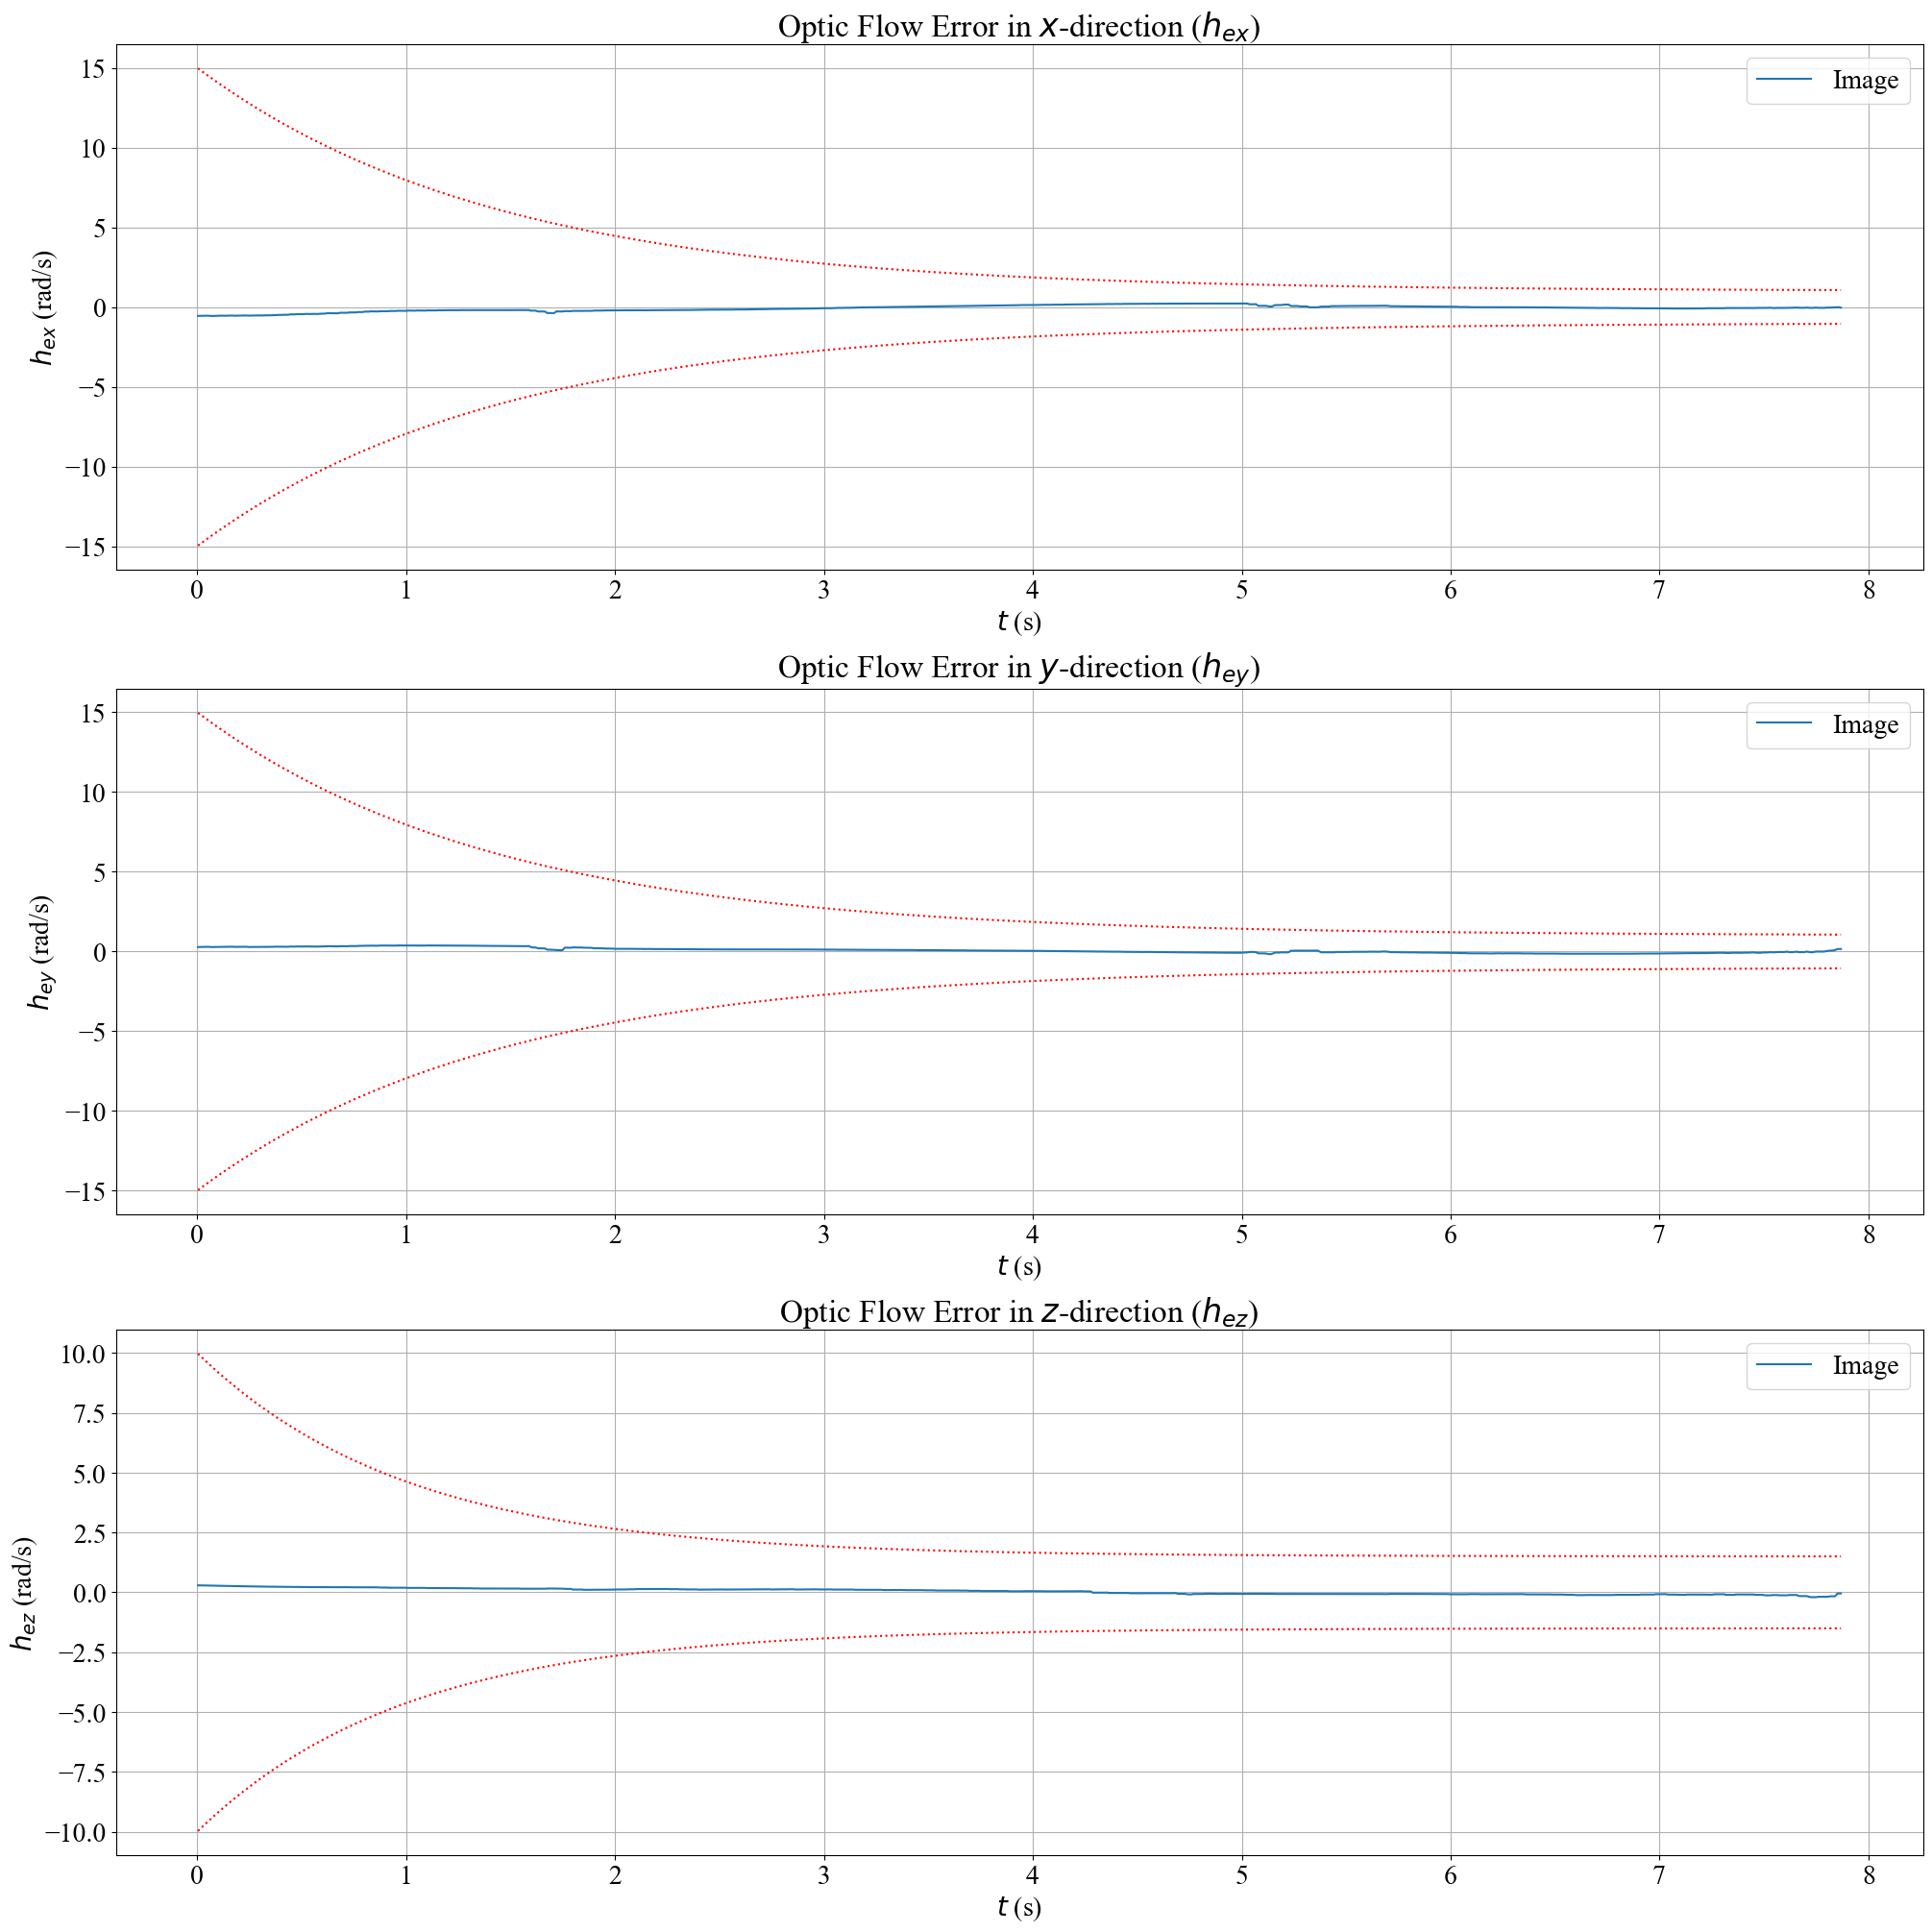

In [26]:
# Configure global plot settings
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = "20"

# Create the figure and subplots
fig, axes = plt.subplots(3, 1, figsize=(20, 20), constrained_layout=True)
# fig, axes = plt.subplots(1, 3, figsize=(20, 7), constrained_layout=True)
# fig.suptitle(metadata_str)  

# Titles, labels, and data for each subplot
titles = [
    r'Optic Flow Error in $x$-direction ($h_{ex}$)',
    r'Optic Flow Error in $y$-direction ($h_{ey}$)',
    r'Optic Flow Error in $z$-direction ($h_{ez}$)'
]
y_labels = [r'$h_{ex}$ (rad/s)', r'$h_{ey}$ (rad/s)', r'$h_{ez}$ (rad/s)']  

# Loop through each axis and plot the data
for i, ax in enumerate(axes):
    ax.plot(t_c, h_e[:, i], label='Image')
    # ax.plot(t_i, y_e[:, i], label='Image Estimated')
    ax.plot(t_c, p_h[:, i], ':r')
    ax.plot(t_c, -p_h[:, i], ':r')
    # ax.plot(t_pv, y_t[:,i], label='Telemetry')
    # ax.plot(t_o, B_y_t[:, i], label='Telemetry Body')
    # ax.plot(t_g, B_y_g[:, i], label='Ground Truth')
    ax.set_title(titles[i])
    ax.set_xlabel(r'$t$ (s)')
    ax.set_ylabel(y_labels[i])
    # ax.set_xlim(t_g[0],t_g[-1])
    # ax.set_ylim(-10.0, 10.0)
    # ax.set_ylim(-1, 1)
    ax.legend()
    ax.grid()

# Show the plot
plt.show()

## 7. Control parameters

### $S(t)$ Plot


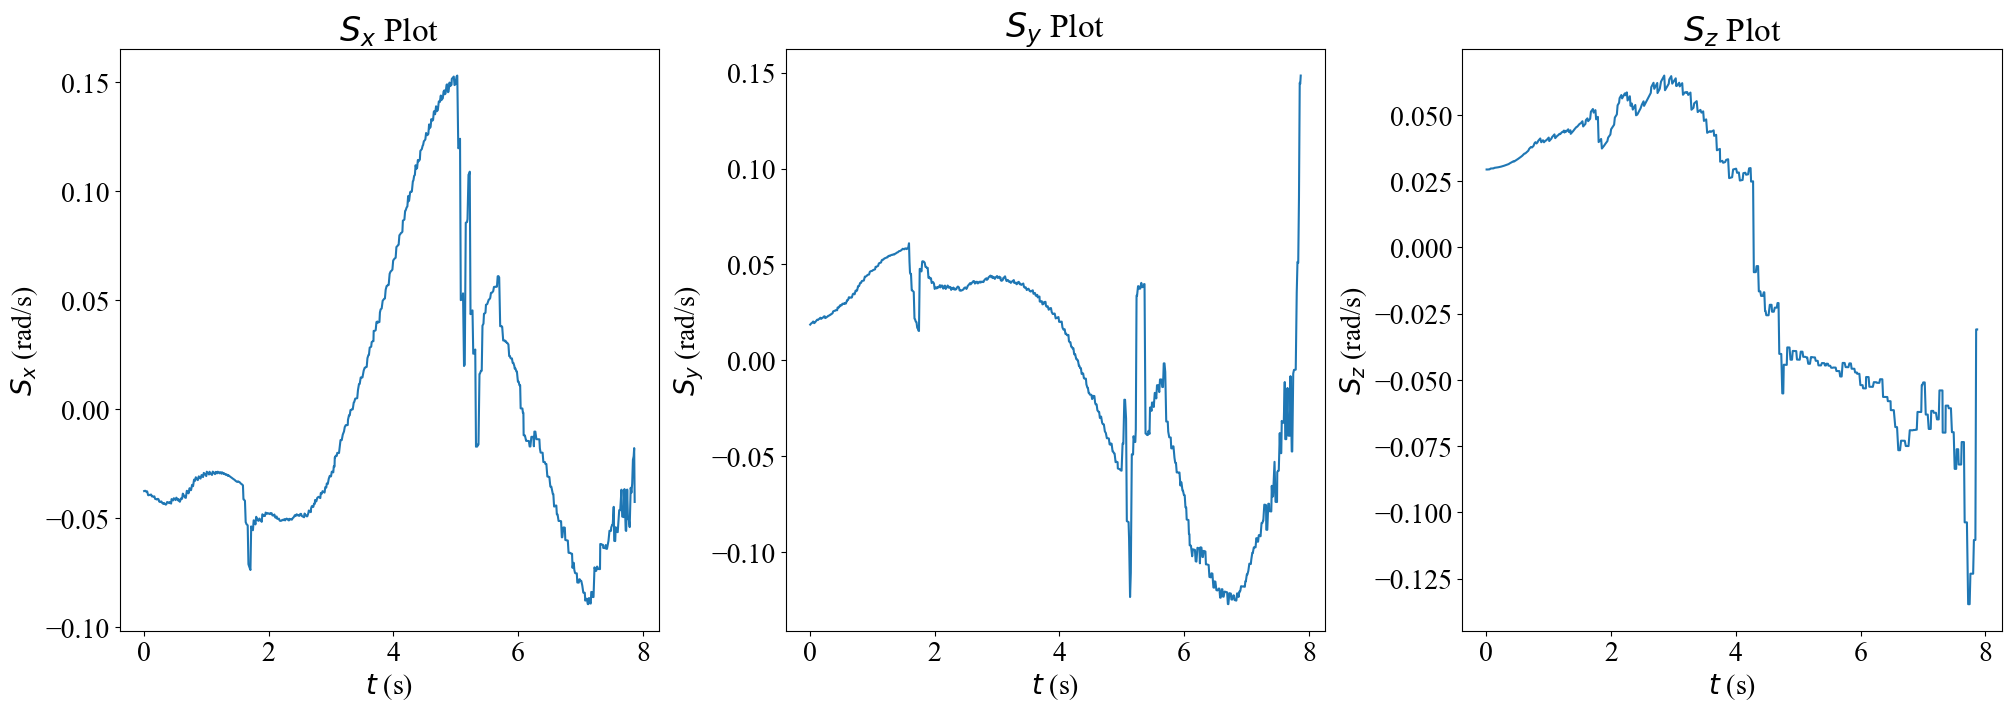

In [27]:
# Configure global plot settings
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = "20"

# Create the figure and subplots
# fig, axes = plt.subplots(3, 1, figsize=(20, 20), constrained_layout=True)
fig, axes = plt.subplots(1, 3, figsize=(20, 7), constrained_layout=True)
# fig.suptitle(metadata_str)  

# Titles, labels, and data for each subplot
titles = [r'$S_{x}$ Plot', r'$S_{y}$ Plot', r'$S_{z}$ Plot']
y_labels = [r'$S_{x}$ (rad/s)', r'$S_{y}$ (rad/s)', r'$S_{z}$ (rad/s)']

# Loop through each axis and plot the data
for i, ax in enumerate(axes):
    ax.plot(t_c, S[:, i, i])
    ax.set_title(titles[i])
    ax.set_xlabel(r'$t$ (s)')
    ax.set_ylabel(y_labels[i])

# Show the plot
plt.show()

### $\zeta(t)$ Plot

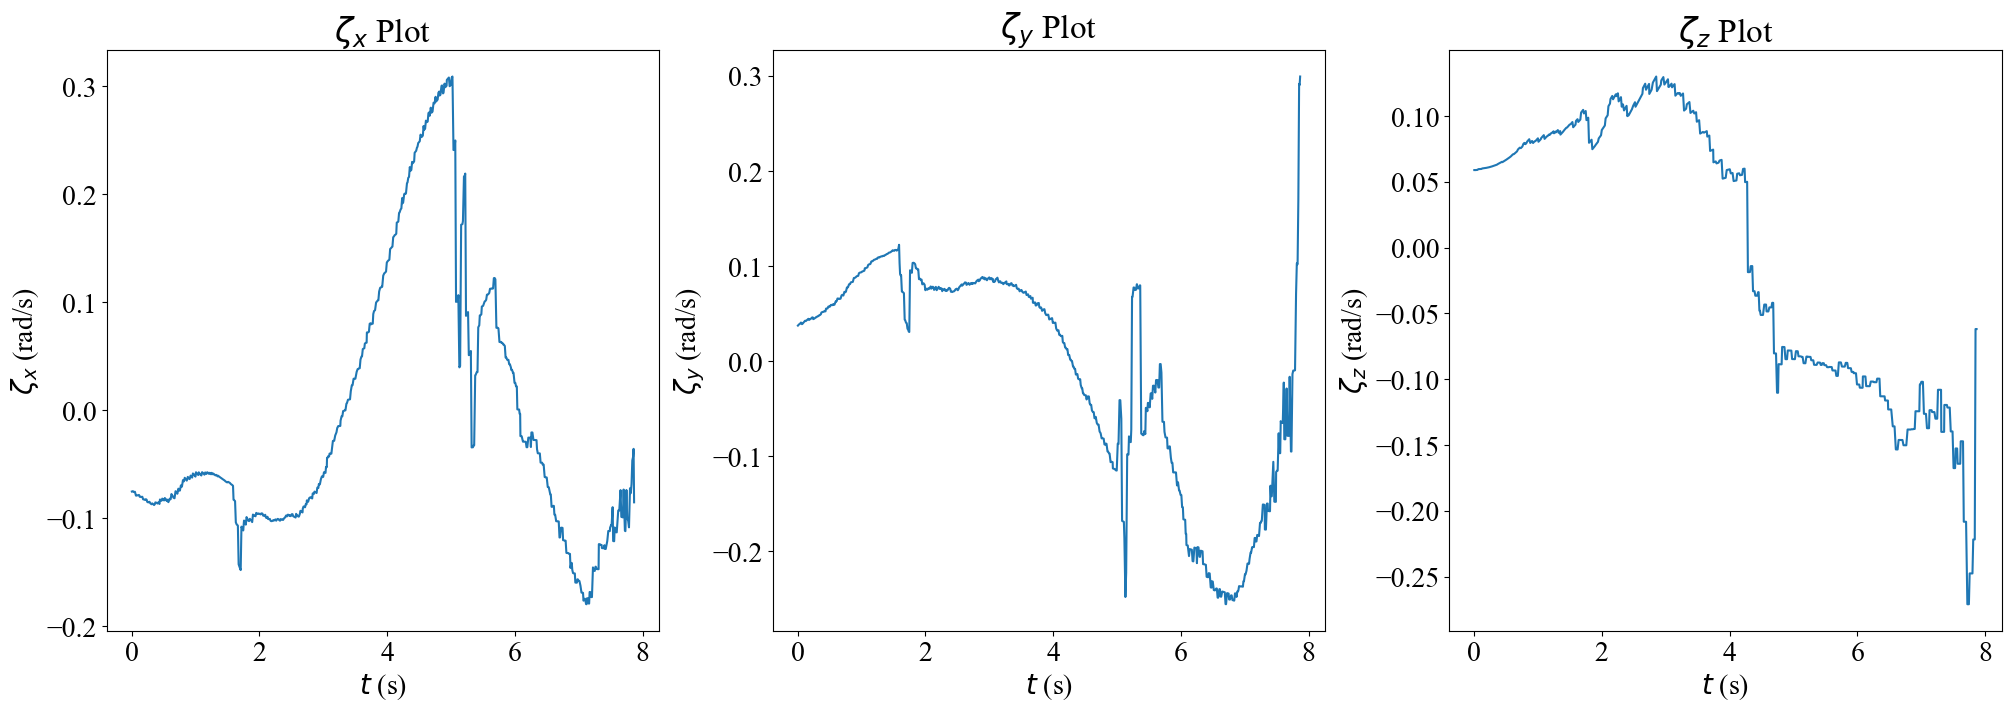

In [28]:
# Configure global plot settings
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = "20"

# Create the figure and subplots
# fig, axes = plt.subplots(3, 1, figsize=(20, 20), constrained_layout=True)
fig, axes = plt.subplots(1, 3, figsize=(20, 7), constrained_layout=True)
# fig.suptitle(metadata_str)  

# Titles, labels, and data for each subplot
titles = [r'$\zeta_{x}$ Plot', r'$\zeta_{y}$ Plot', r'$\zeta_{z}$ Plot']
y_labels = [r'$\zeta_{x}$ (rad/s)', r'$\zeta_{y}$ (rad/s)', r'$\zeta_{z}$ (rad/s)']

# Loop through each axis and plot the data
for i, ax in enumerate(axes):
    ax.plot(t_c, zeta[:, i])
    ax.set_title(titles[i])
    ax.set_xlabel(r'$t$ (s)')
    ax.set_ylabel(y_labels[i])

# Show the plot
plt.show()

### $\int\zeta(t)$ Plot

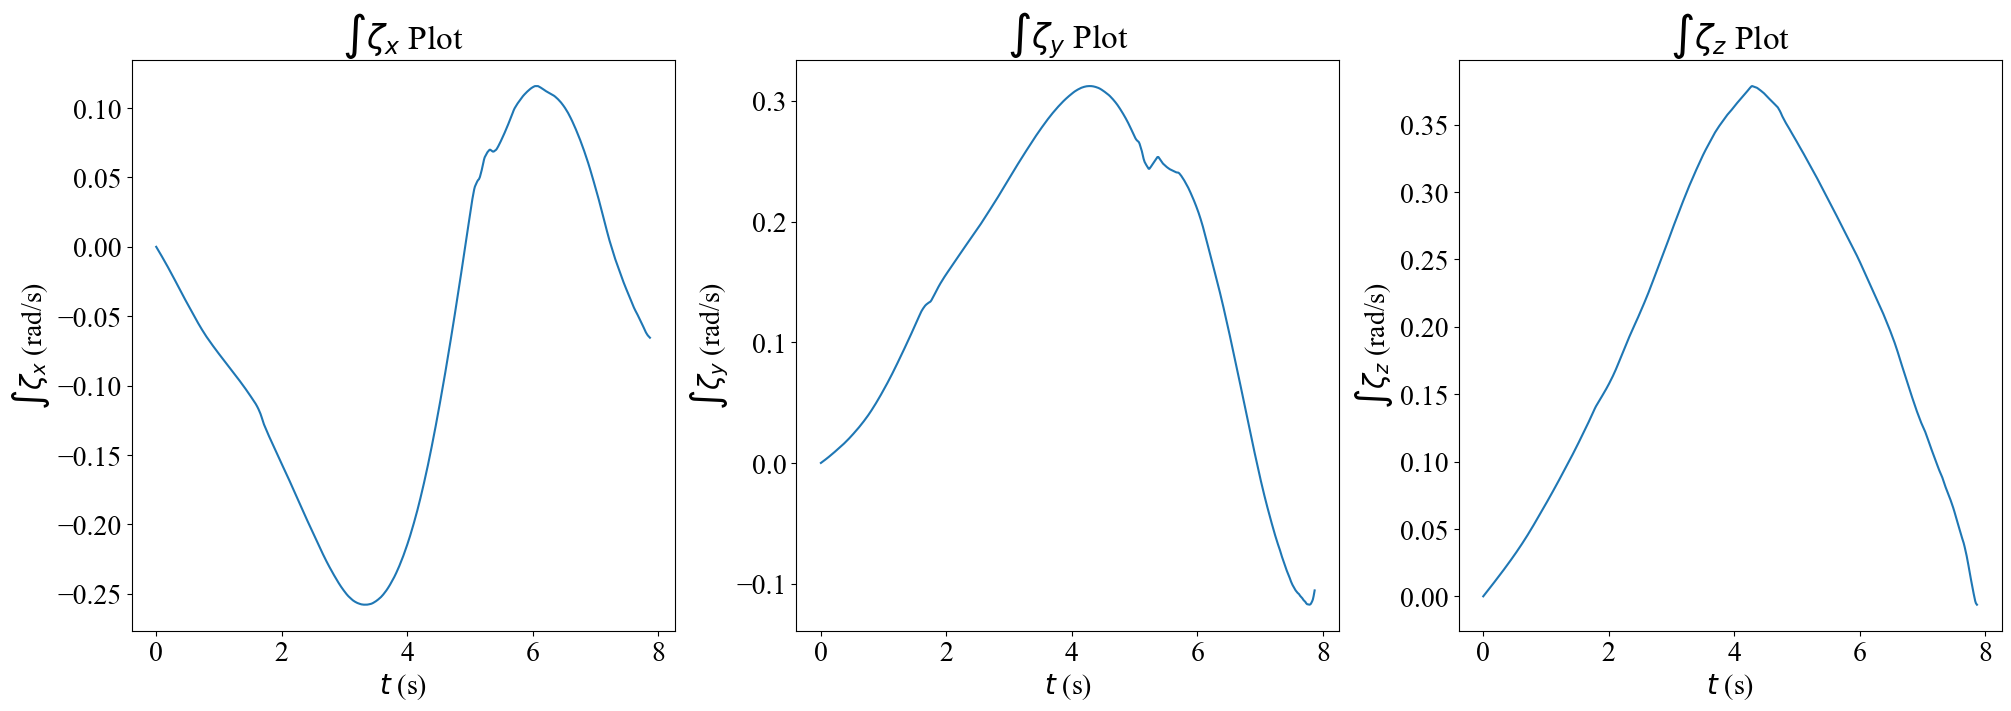

In [29]:
# Configure global plot settings
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = "20"

# Create the figure and subplots
# fig, axes = plt.subplots(3, 1, figsize=(20, 20), constrained_layout=True)
fig, axes = plt.subplots(1, 3, figsize=(20, 7), constrained_layout=True)
# fig.suptitle(metadata_str)  

# Titles, labels, and data for each subplot
titles = [r'$\int\zeta_{x}$ Plot', r'$\int\zeta_{y}$ Plot', r'$\int\zeta_{z}$ Plot']
y_labels = [r'$\int\zeta_{x}$ (rad/s)', r'$\int\zeta_{y}$ (rad/s)', r'$\int\zeta_{z}$ (rad/s)']

# Loop through each axis and plot the data
for i, ax in enumerate(axes):
    ax.plot(t_c, izeta[:, i])
    ax.set_title(titles[i])
    ax.set_xlabel(r'$t$ (s)')
    ax.set_ylabel(y_labels[i])

# Show the plot
plt.show()

### $\kappa(t)$ Plot

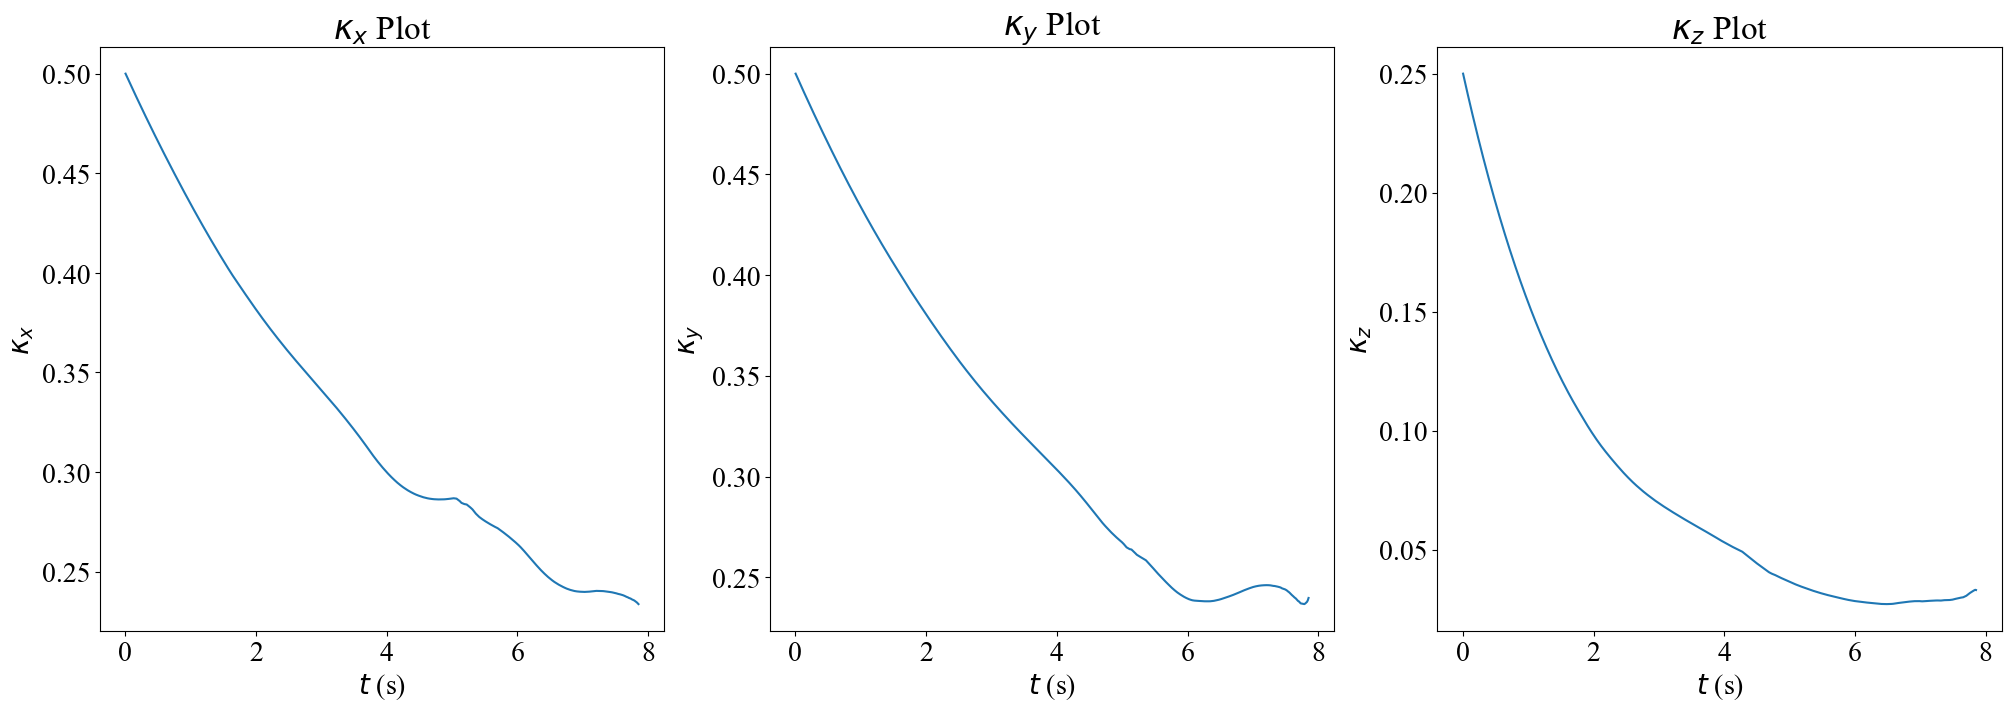

In [30]:
# Configure global plot settings
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = "20"

# Create the figure and subplots
# fig, axes = plt.subplots(3, 1, figsize=(20, 20), constrained_layout=True)
fig, axes = plt.subplots(1, 3, figsize=(20, 7), constrained_layout=True)
# fig.suptitle(metadata_str)  

# Titles, labels, and data for each subplot
titles = [r'$\kappa_{x}$ Plot', r'$\kappa_{y}$ Plot', r'$\kappa_{z}$ Plot']
y_labels = [r'$\kappa_{x}$', r'$\kappa_{y}$', r'$\kappa_{z}$']

# Loop through each axis and plot the data
for i, ax in enumerate(axes):
    ax.plot(t_c[:-2], kappa[:-2, i])
    ax.set_title(titles[i])
    ax.set_xlabel(r'$t$ (s)')
    ax.set_ylabel(y_labels[i])

# Show the plot
plt.show()

### $G(t)$ Plot

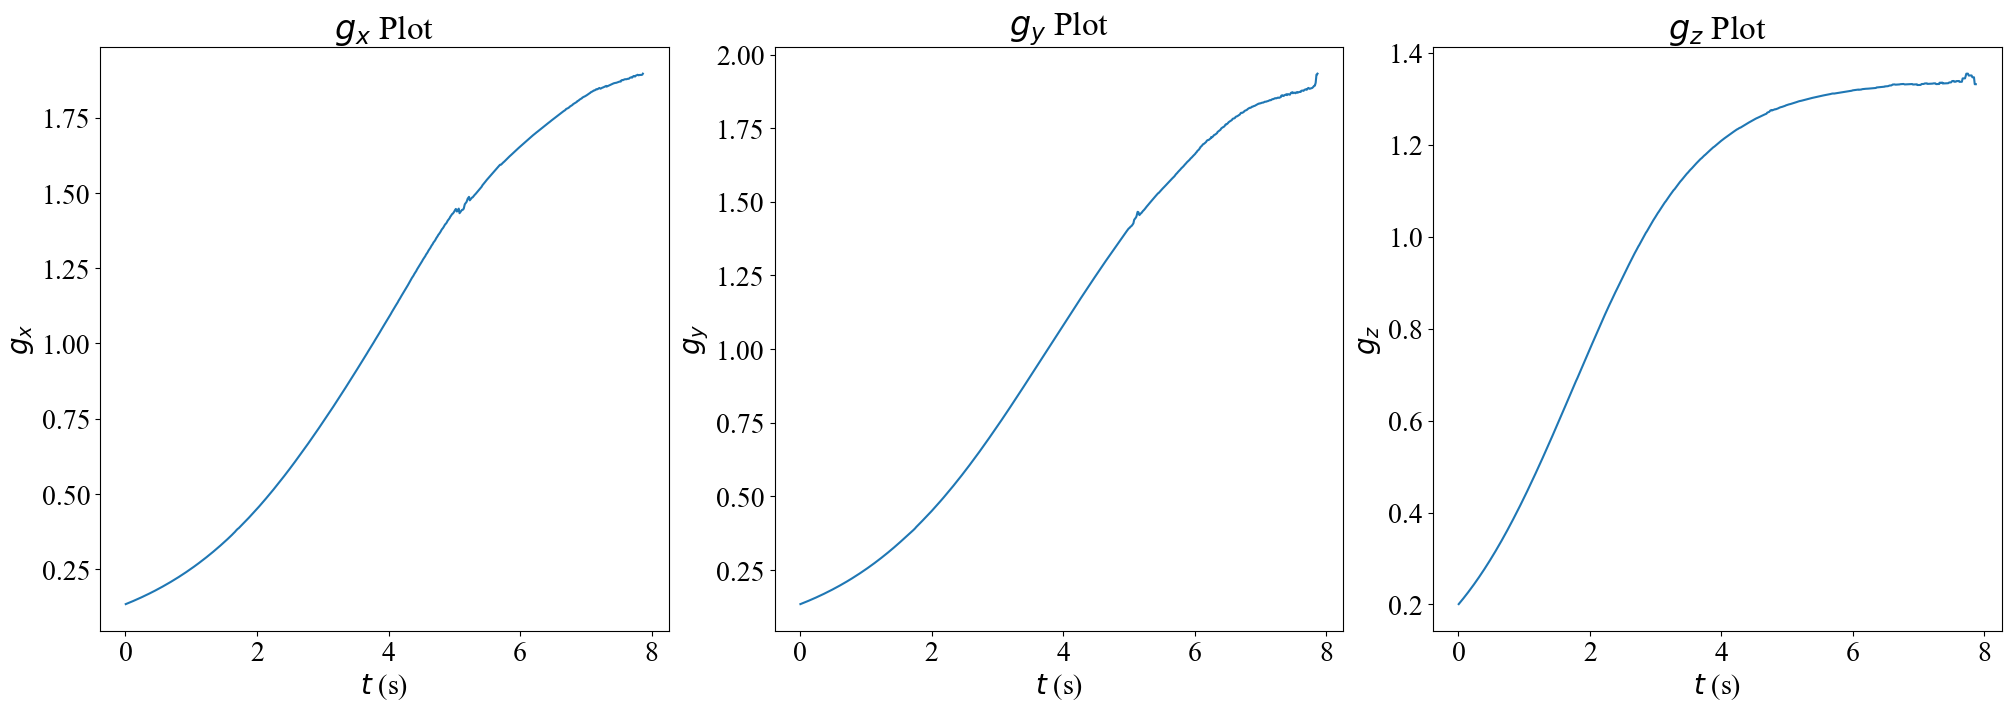

In [31]:
# Configure global plot settings
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = "20"

# Create the figure and subplots
# fig, axes = plt.subplots(3, 1, figsize=(20, 20), constrained_layout=True)
fig, axes = plt.subplots(1, 3, figsize=(20, 7), constrained_layout=True)
# fig.suptitle(metadata_str)  

# Titles, labels, and data for each subplot
titles = [r'$g_{x}$ Plot',  r'$g_{y}$ Plot',  r'$g_{z}$ Plot']
y_labels = [r'$g_{x}$', r'$g_{y}$', r'$g_{z}$']

# Loop through each axis and plot the data
for i, ax in enumerate(axes):
    ax.plot(t_c, G[:, i, i])
    ax.set_title(titles[i])
    ax.set_xlabel(r'$t$ (s)')
    ax.set_ylabel(y_labels[i])

# Show the plot
plt.show()

### $\theta(t)$ Plot

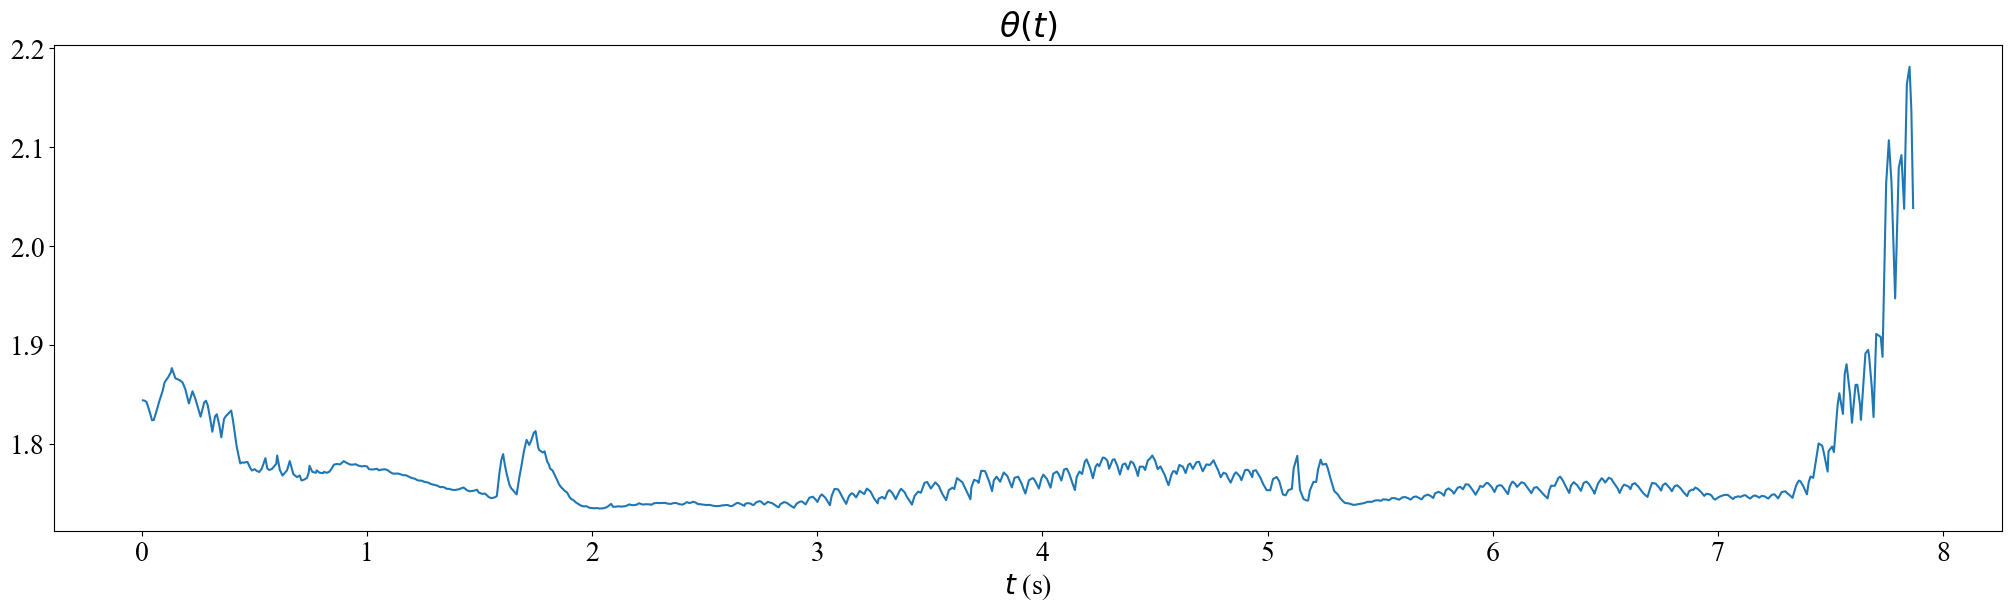

In [32]:
# Configure global plot settings
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = "20"

# Create the figure and subplots
plt.figure(figsize=(20, 6), constrained_layout=True)

plt.plot(t_c, theta)
plt.title(r'$\theta(t)$')
plt.xlabel(r'$t$ (s)')
# plt.ylabel(r'$T$ (N)')

# Show the plot
plt.show()

### $\sigma(t)$ Plot

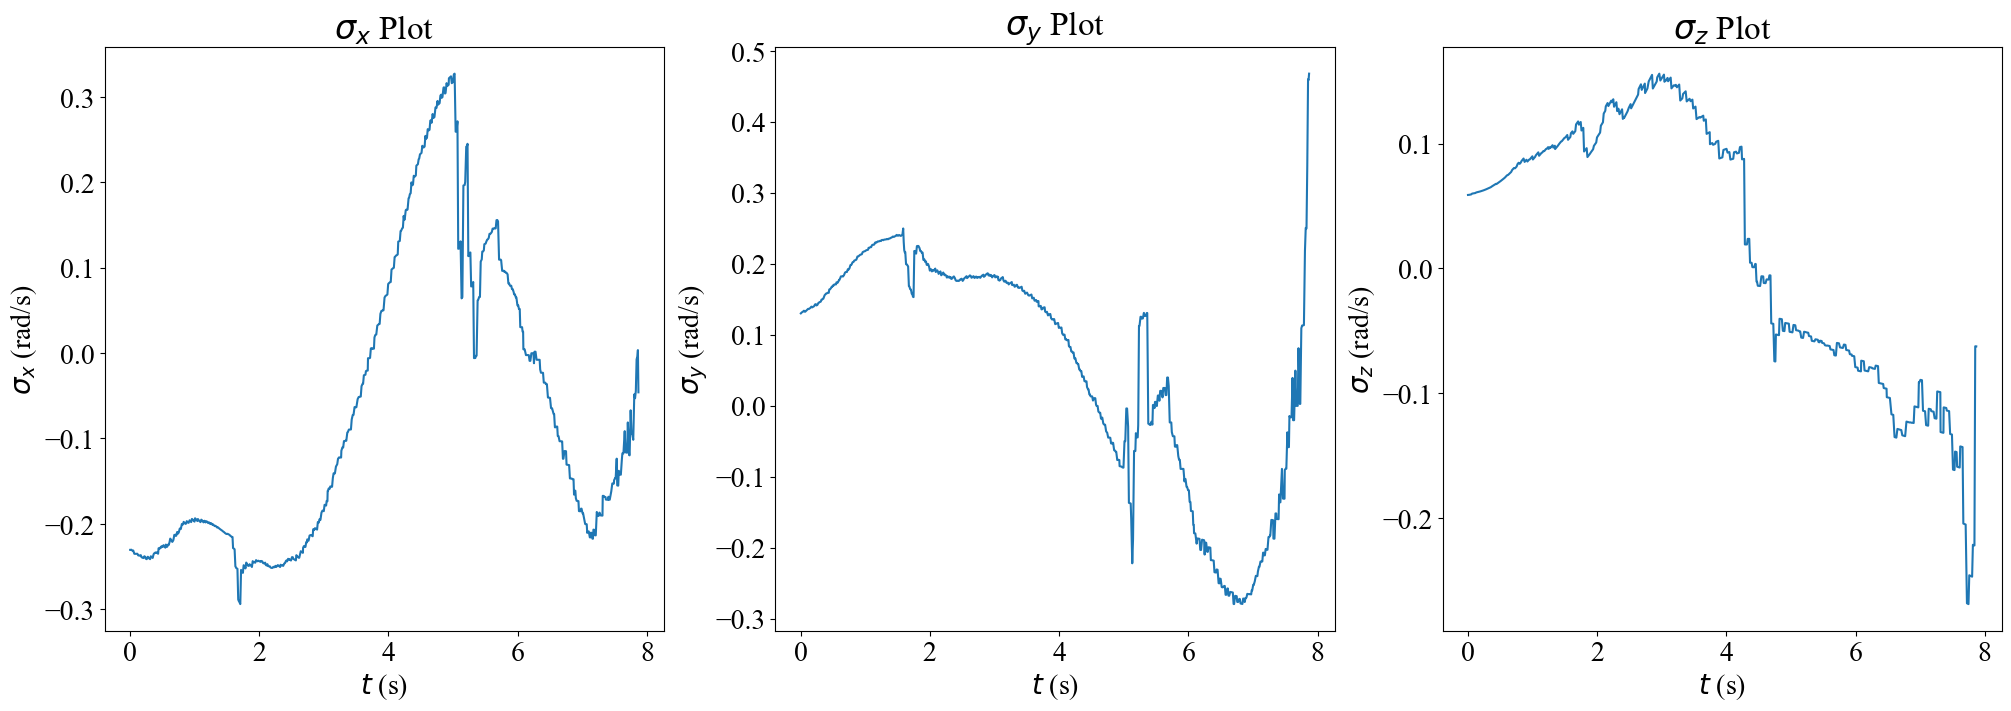

In [33]:
# Configure global plot settings
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = "20"

# Create the figure and subplots
# fig, axes = plt.subplots(3, 1, figsize=(20, 20), constrained_layout=True)
fig, axes = plt.subplots(1, 3, figsize=(20, 7), constrained_layout=True)
# fig.suptitle(metadata_str)  

# Titles, labels, and data for each subplot
titles = [r'$\sigma_{x}$ Plot', r'$\sigma_{y}$ Plot', r'$\sigma_{z}$ Plot']
y_labels = [r'$\sigma_{x}$ (rad/s)', r'$\sigma_{y}$ (rad/s)', r'$\sigma_{z}$ (rad/s)']

# Loop through each axis and plot the data
for i, ax in enumerate(axes):
    ax.plot(t_c, sigma[:, i])
    ax.set_title(titles[i])
    ax.set_xlabel(r'$t$ (s)')
    ax.set_ylabel(y_labels[i])

# Show the plot
plt.show()

### $a_v(t)$ Plot

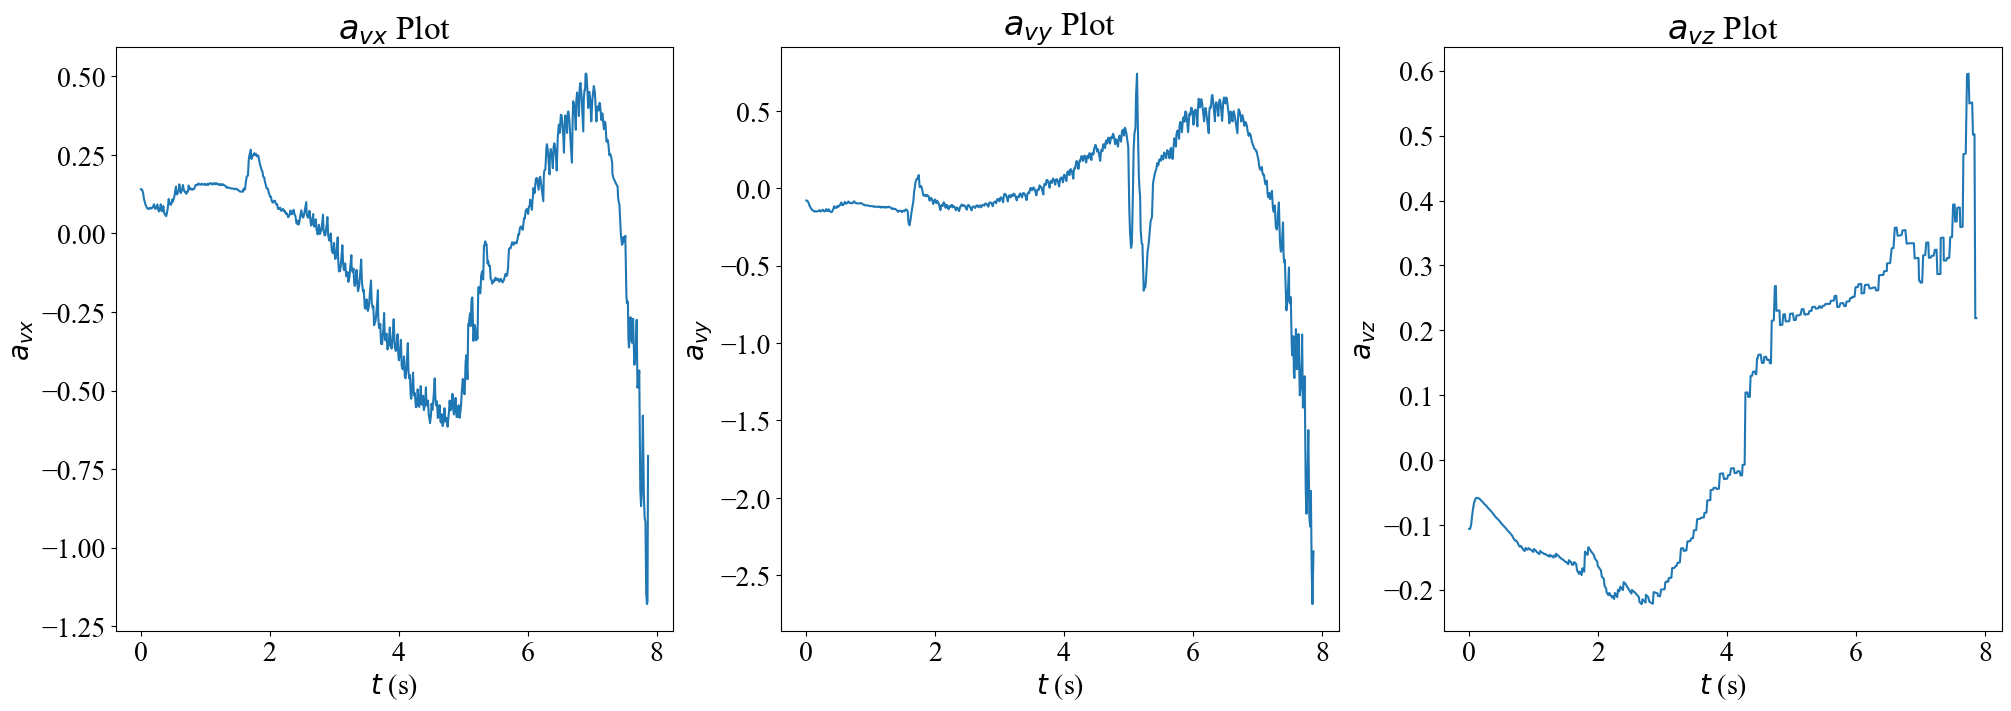

In [34]:
# Configure global plot settings
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = "20"

# Create the figure and subplots
# fig, axes = plt.subplots(3, 1, figsize=(20, 20), constrained_layout=True)
fig, axes = plt.subplots(1, 3, figsize=(20, 7), constrained_layout=True)
# fig.suptitle(metadata_str)  

# Titles, labels, and data for each subplot
titles = [r'$a_{vx}$ Plot',  r'$a_{vy}$ Plot',  r'$a_{vz}$ Plot']
y_labels = [r'$a_{vx}$', r'$a_{vy}$', r'$a_{vz}$']

# Loop through each axis and plot the data
for i, ax in enumerate(axes):
    ax.plot(t_c, a_v[:, i])
    ax.set_title(titles[i])
    ax.set_xlabel(r'$t$ (s)')
    ax.set_ylabel(y_labels[i])

# Show the plot
plt.show()

### $\dot{h}_d(t)$ Plot

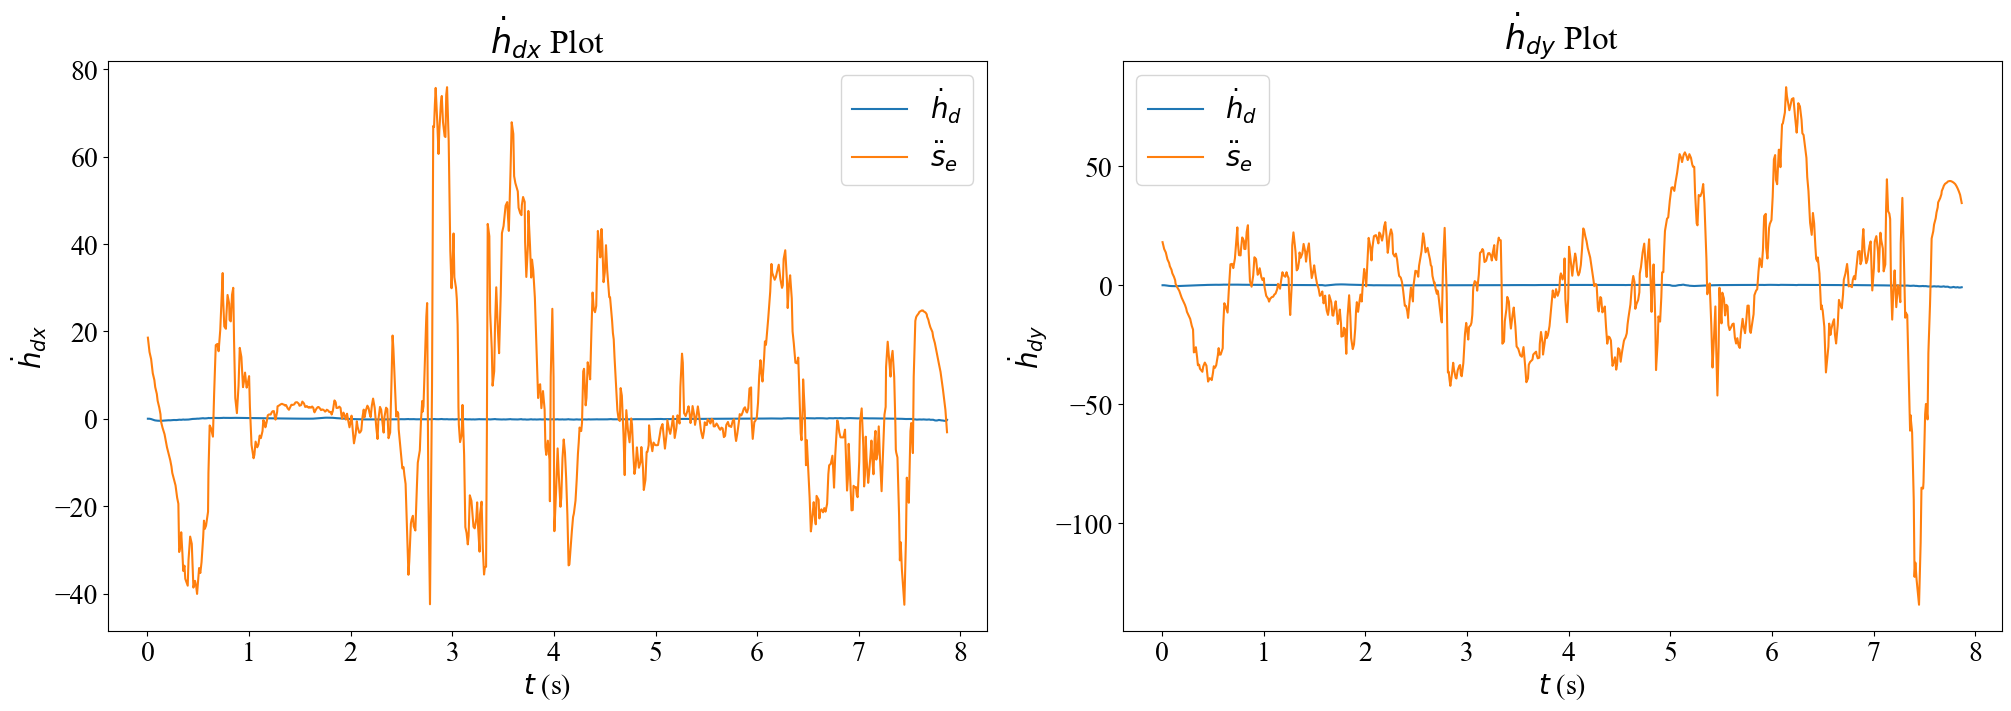

In [35]:
dds_e_filtered = sgf(np.gradient(ds_e, t_c, axis=0), 51, 2, axis=0)
# Configure global plot settings
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = "20"

# Create the figure and subplots
# fig, axes = plt.subplots(2, 1, figsize=(20, 20), constrained_layout=True)
fig, axes = plt.subplots(1, 2, figsize=(20, 7), constrained_layout=True)
# fig.suptitle(metadata_str)  

# Titles, labels, and data for each subplot
titles = [r'$\dot{h}_{dx}$ Plot',  r'$\dot{h}_{dy}$ Plot',  r'$\dot{h}_{dz}$ Plot']
y_labels = [r'$\dot{h}_{dx}$', r'$\dot{h}_{dy}$', r'$\dot{h}_{dz}$']

# Loop through each axis and plot the data
for i, ax in enumerate(axes):
    ax.plot(t_c, dh_d[:, i], label='$\dot{h}_d$')
    ax.plot(t_c, dds_e_filtered[:, i]*10, label='$\ddot{s}_e$')
    ax.set_title(titles[i])
    ax.set_xlabel(r'$t$ (s)')
    ax.set_ylabel(y_labels[i])
    ax.legend()

# Show the plot
plt.show()

### $h_d(t)$ Plot

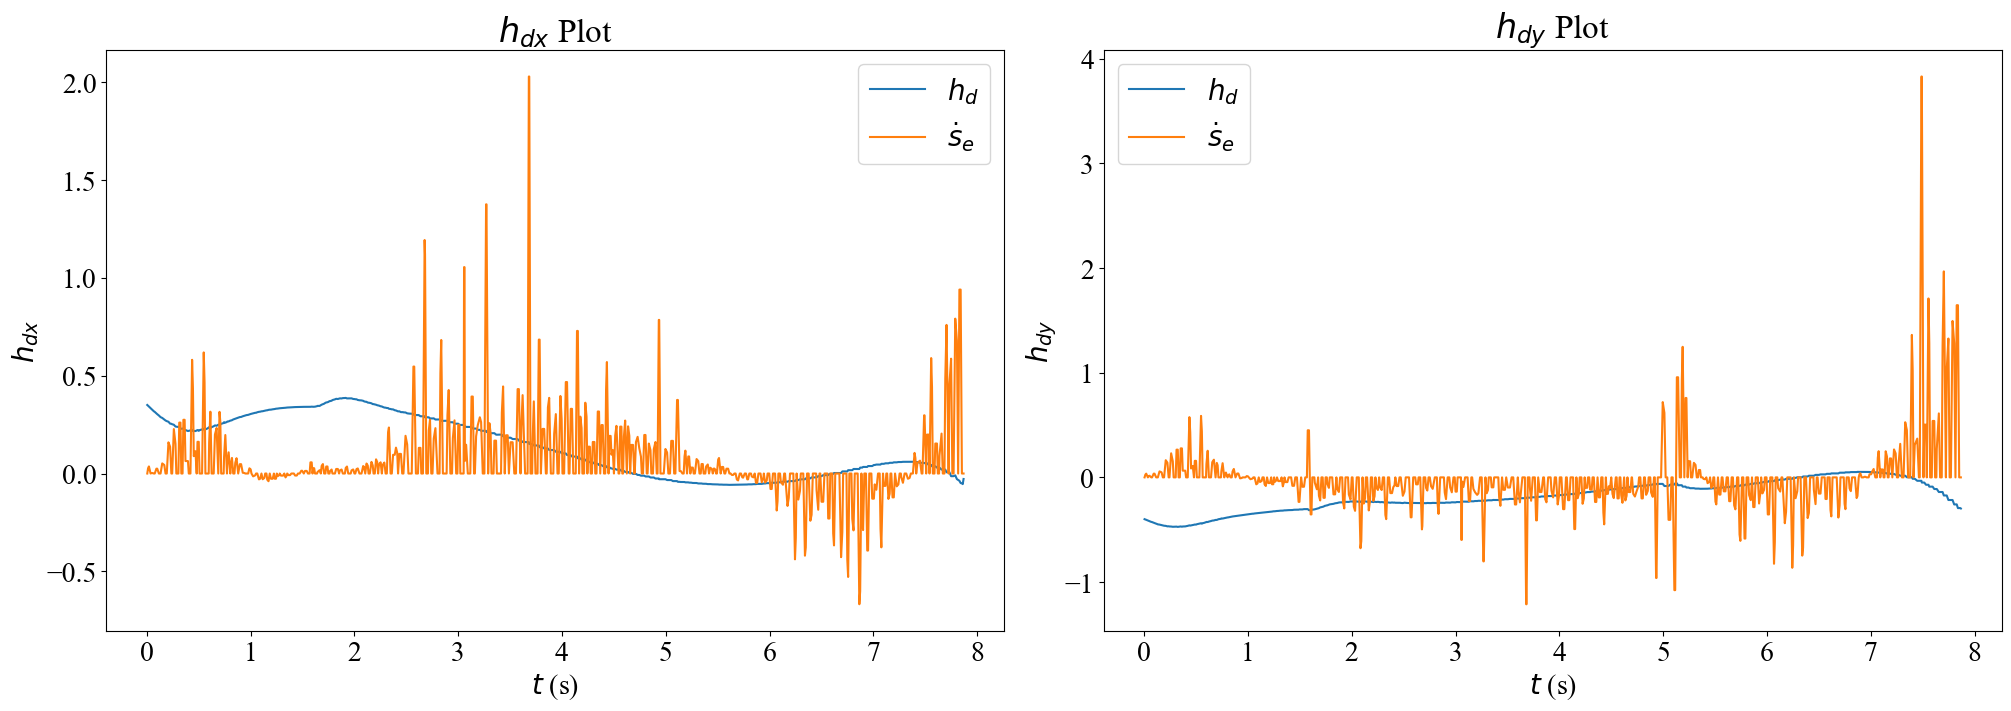

In [36]:
# Configure global plot settings
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = "20"

fig, axes = plt.subplots(1, 2, figsize=(20, 7), constrained_layout=True)
titles  = [r'$h_{dx}$ Plot', r'$h_{dy}$ Plot', r'$h_{dz}$ Plot']
y_labels = [r'$h_{dx}$', r'$h_{dy}$', r'$h_{dz}$']
for i, ax in enumerate(axes):
    ax.plot(t_c, h_d[:, i], label=r'$h_d$')
    ax.plot(t_c, ds_e[:, i], label=r'$\dot{s}_e$')
    ax.set_title(titles[i]); ax.set_xlabel(r'$t$ (s)'); ax.set_ylabel(y_labels[i]); ax.legend()
plt.show()


### $s_e(t)$ Plot

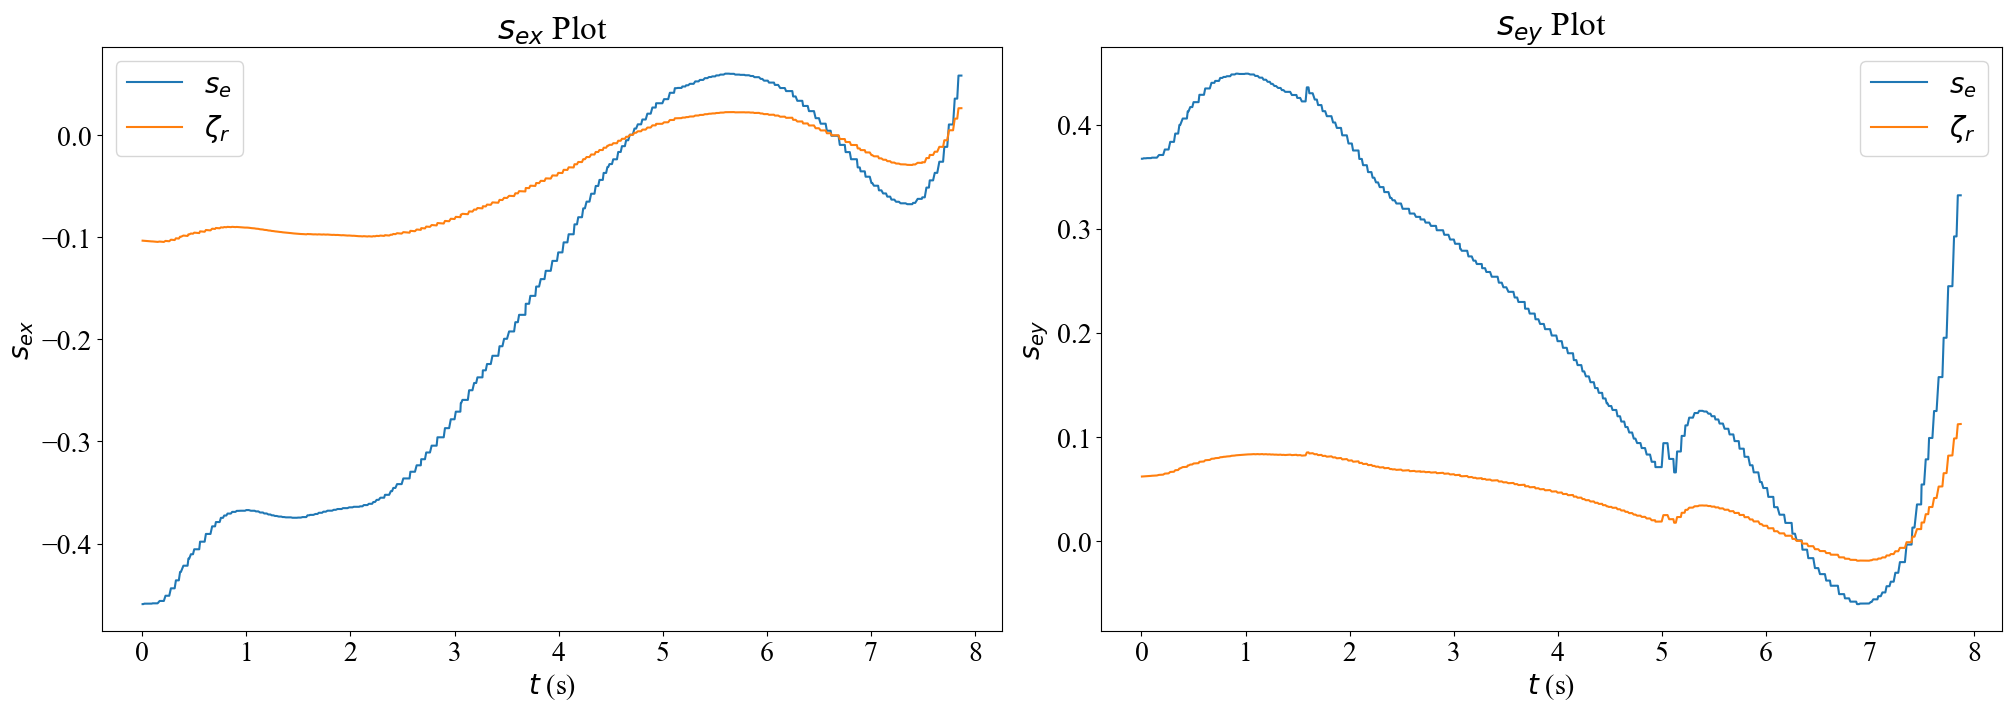

In [37]:
# Configure global plot settings
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = "20"

fig, axes = plt.subplots(1, 2, figsize=(20, 7), constrained_layout=True)
titles  = [r'$s_{ex}$ Plot', r'$s_{ey}$ Plot']
y_labels = [r'$s_{ex}$', r'$s_{ey}$']
for i, ax in enumerate(axes):
    ax.plot(t_c, s[:, i] - s_d[i], label=r'$s_e$')
    if zeta_r is not None:
        ax.plot(t_c, zeta_r[:, i], label=r'$\zeta_r$')
    ax.set_title(titles[i]); ax.set_xlabel(r'$t$ (s)'); ax.set_ylabel(y_labels[i]); ax.legend()
plt.show()


## 8. Calibration plots

<h2>Input Calibration<h2>

### Body-Fixed Angular velocity ($^B\omega$) Plot

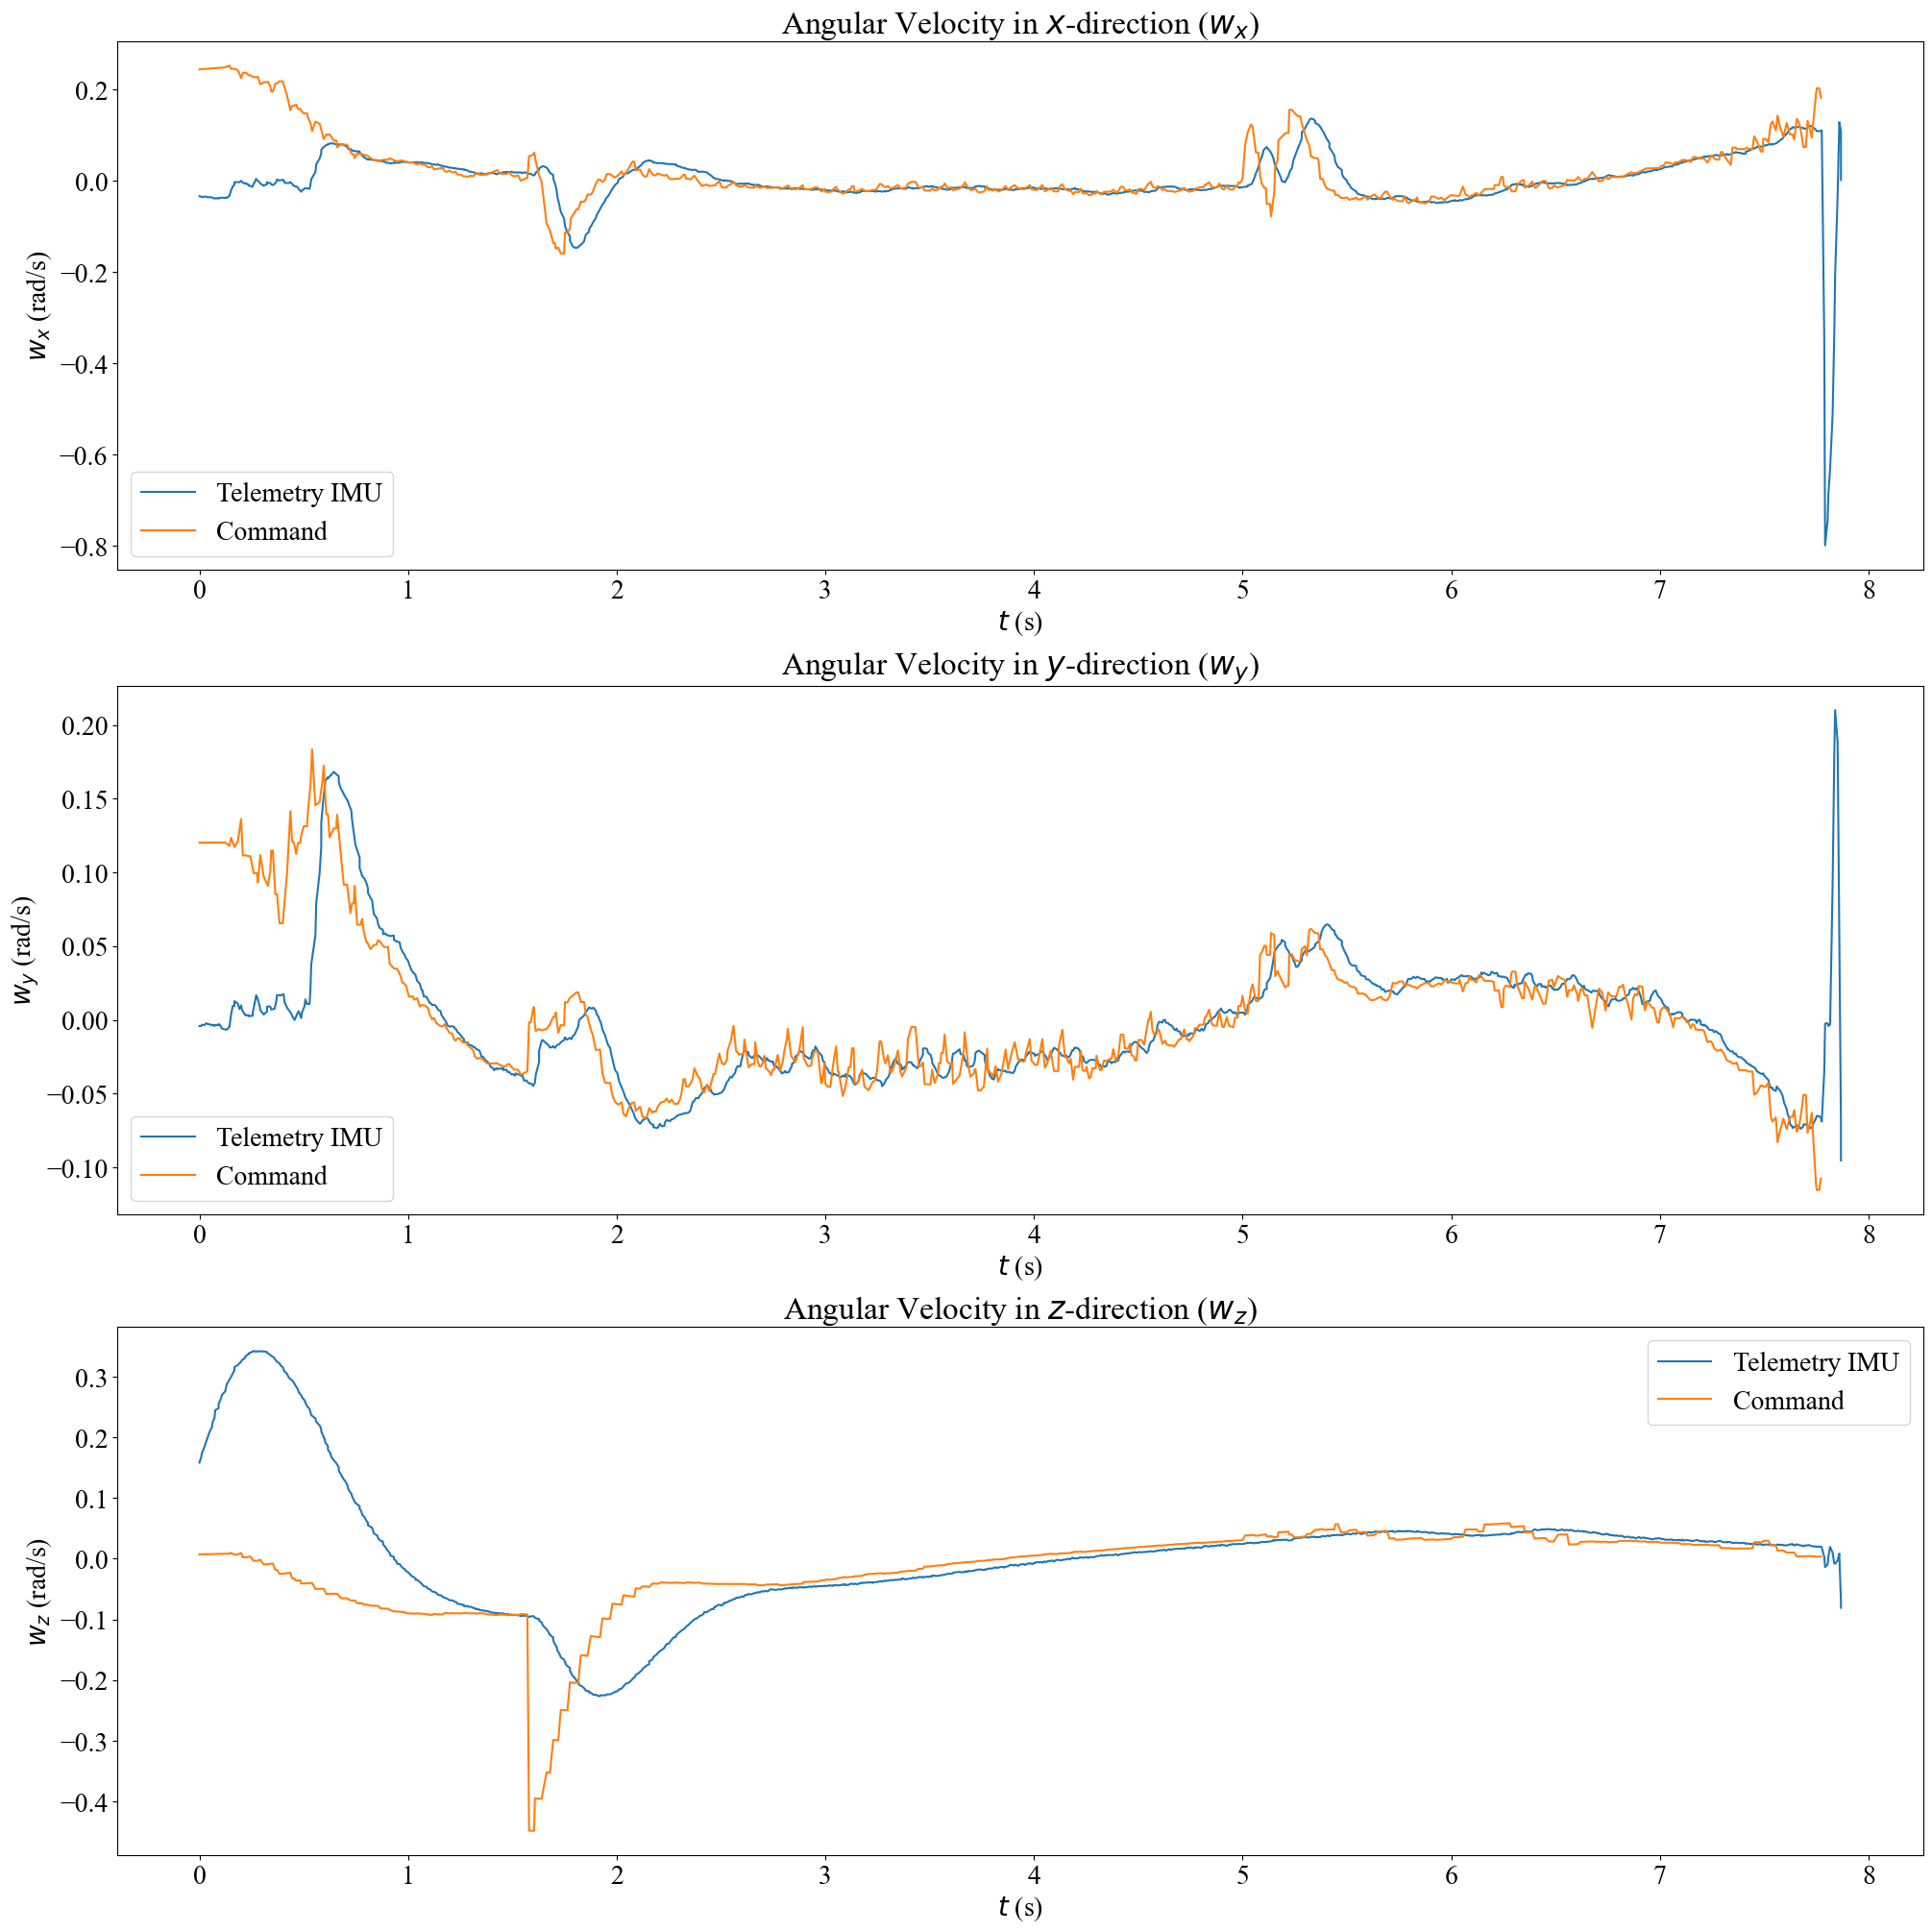

In [38]:
# Configure global plot settings
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = "20"

# Create the figure and subplots
fig, axes = plt.subplots(3, 1, figsize=(20, 20), constrained_layout=True)
# fig, axes = plt.subplots(1, 3, figsize=(20, 7), constrained_layout=True)

# Titles, labels, and data for each subplot
titles = [
    r'Angular Velocity in $x$-direction ($w_x$)',
    r'Angular Velocity in $y$-direction ($w_y$)',
    r'Angular Velocity in $z$-direction ($w_z$)'
]
y_labels = [r'$w_x$ (rad/s)', r'$w_y$ (rad/s)', r'$w_z$ (rad/s)']

# Loop through each axis and plot the data
for i, ax in enumerate(axes):
    # ax.plot(t_i[:len(w_i)], w_i[:, i], label='Image')
    # ax.plot(t_o, B_w_ut[:,i], label='Telemetry')
    ax.plot(t_a, w_t[:,i], label='Telemetry IMU')
    # ax.plot(t_g, B_w_ug[:,i], label='Ground Truth')
    ax.plot(t_g[:len(w_u)], w_u[:,i], label='Command')
    ax.set_title(titles[i])
    ax.set_xlabel(r'$t$ (s)')
    ax.set_ylabel(y_labels[i])
    # ax.set_xlim(t_g[0],t_g[-1])
    # ax.set_ylim(-0.02, 0.02)
    # ax.set_ylim(-1.0, 1.0)
    # ax.set_ylim(-5.0, 5.0)
    # ax.set_ylim(-0.5, 0.5)
    ax.legend()

# Show the plot
plt.show()

### Body-Fixed Thrust ($^BT$) Plot

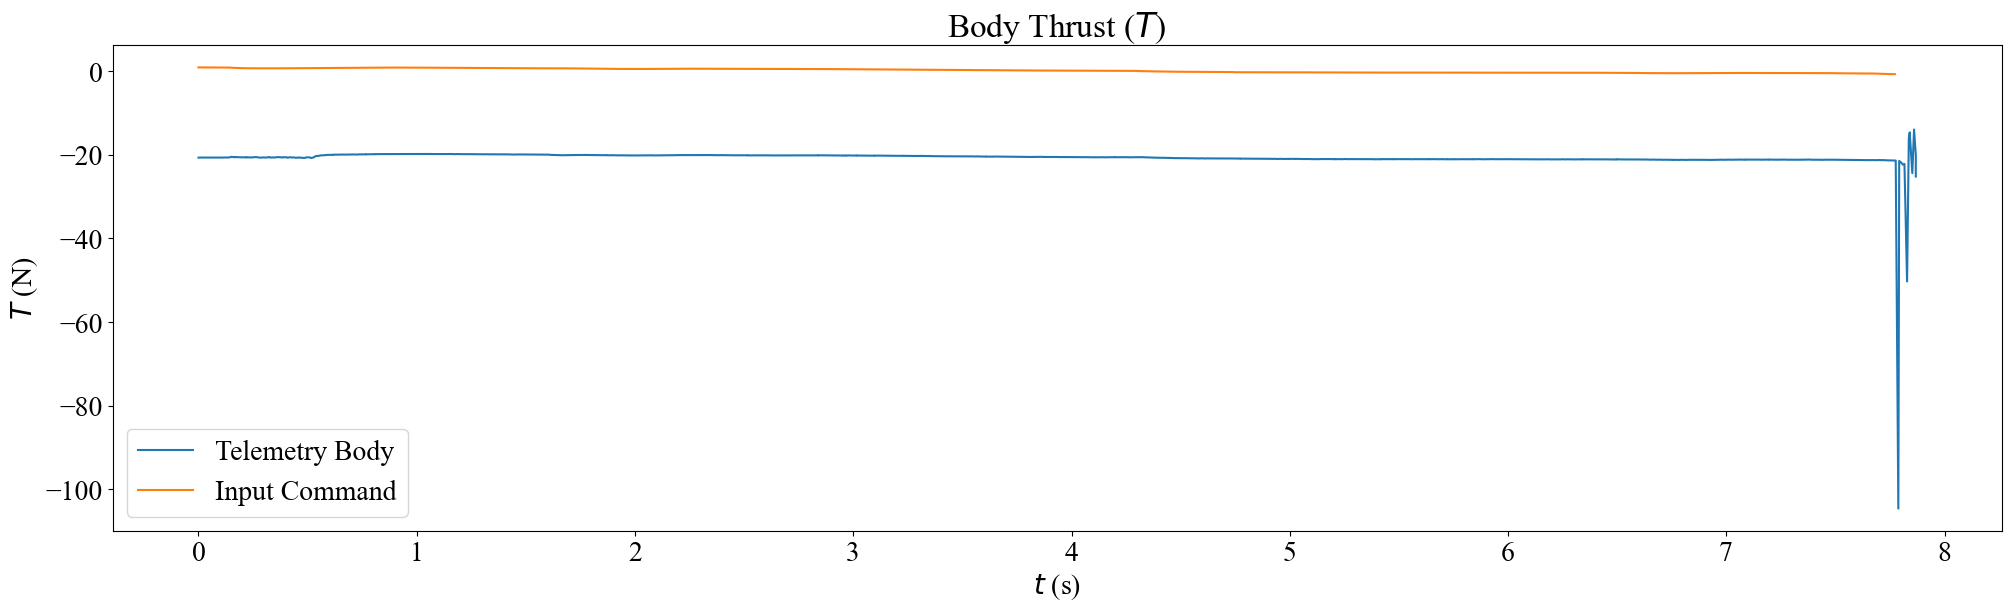

In [39]:
# Configure global plot settings
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = "20"

# Create the figure and subplots
# fig, axes = plt.subplots(1, 3, figsize=(20, 7), constrained_layout=True)
plt.figure(figsize=(20, 6), constrained_layout=True)

plt.plot(t_a, T_t, label='Telemetry Body')
plt.plot(t_g[:len(T_u)], T_u, label='Input Command')
plt.title(r'Body Thrust ($T$)')
plt.xlabel(r'$t$ (s)')
plt.ylabel(r'$T$ (N)')
# plt.xlim(t_g[0],t_g[-1])
# plt.ylim(-50.0, 50.0)
# plt.ylim(-1.0, 1.0)
# plt.ylim(-1.0, 30.0)
plt.legend()

# Show the plot
plt.show()

<h2>Output Calibration<h2>

### Optic Flow ($h$) Plot

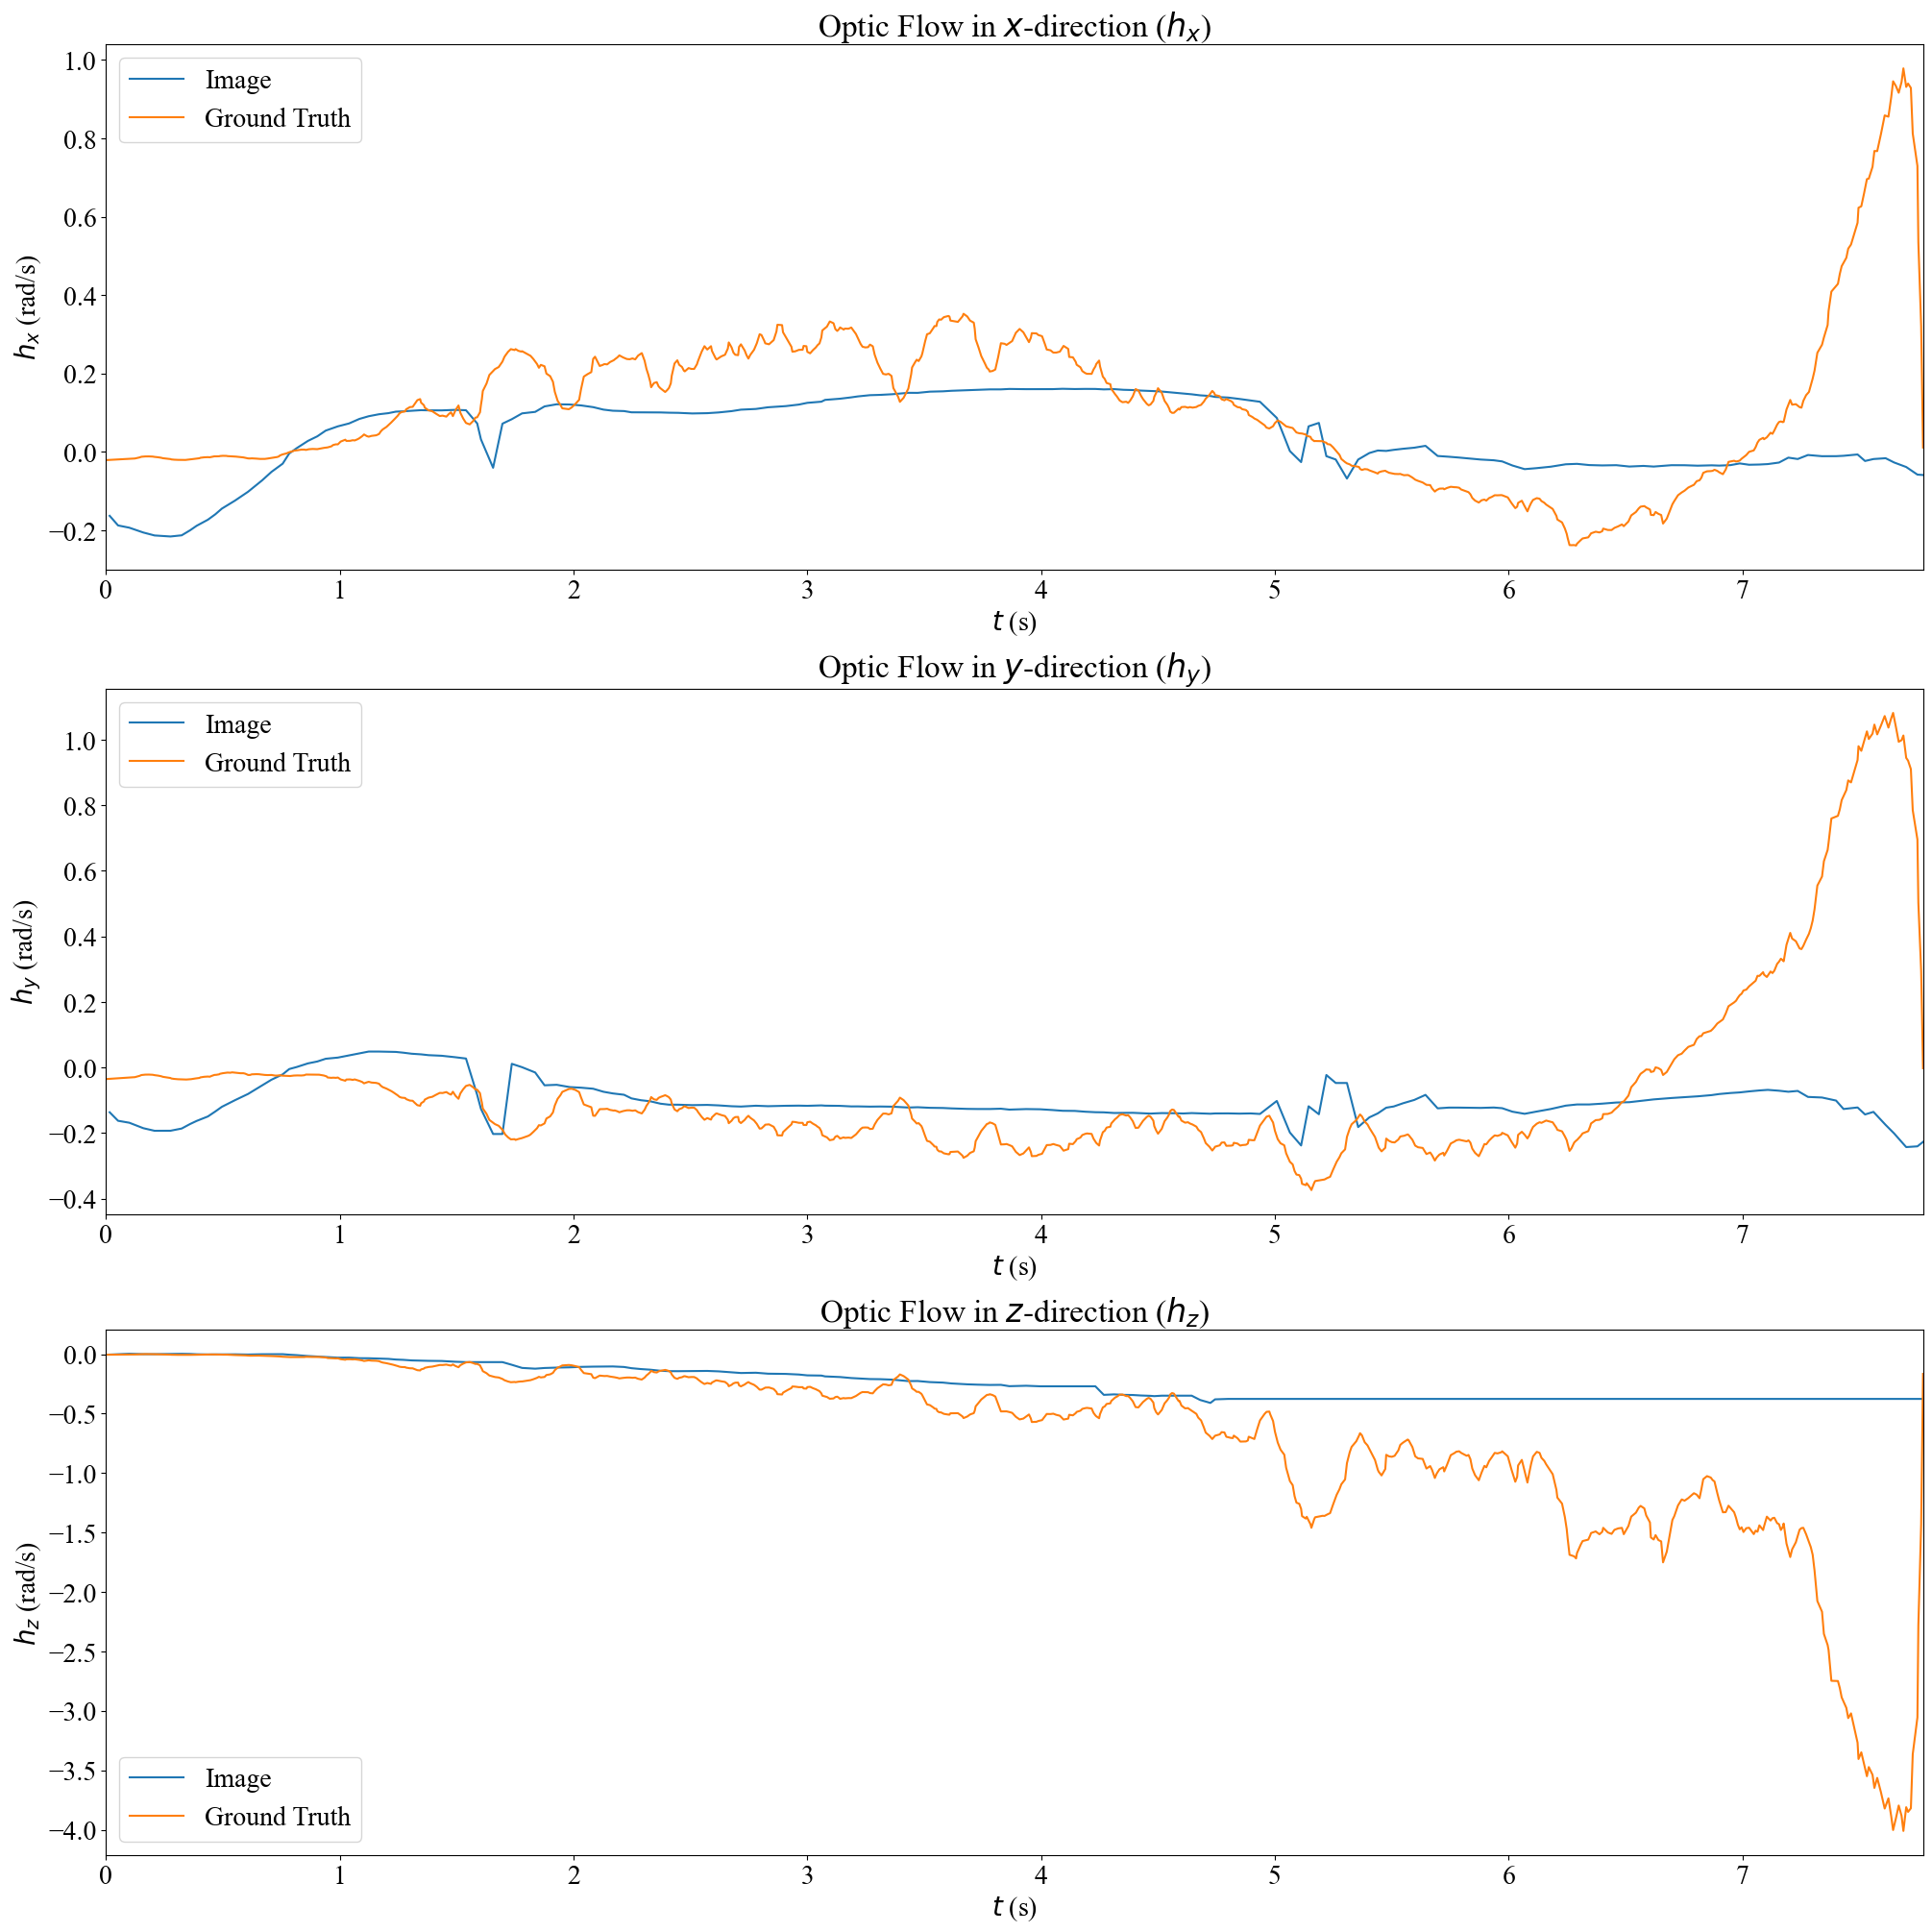

In [40]:
# Configure global plot settings
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = "20"

# Create the figure and subplots
fig, axes = plt.subplots(3, 1, figsize=(20, 20), constrained_layout=True)
# fig, axes = plt.subplots(1, 3, figsize=(20, 7), constrained_layout=True)

# Titles, labels, and data for each subplot
titles = [
    r'Optic Flow in $x$-direction ($h_x$)',
    r'Optic Flow in $y$-direction ($h_y$)',
    r'Optic Flow in $z$-direction ($h_z$)'
]
y_labels = [r'$h_x$ (rad/s)', r'$h_y$ (rad/s)', r'$h_z$ (rad/s)']

# Loop through each axis and plot the data
for i, ax in enumerate(axes):
    ax.plot(t_i[:len(y_i[:, i])], y_i[:, i], label='Image')
    # ax.plot(t_i, y_e[:, i], label='Image Estimated')
    # ax.plot(t_pv, y_t[:,i], label='Telemetry')
    # ax.plot(t_o, B_y_t[:, i], label='Telemetry Body')
    ax.plot(t_g, B_y_g[:, i], label='Ground Truth')
    ax.set_title(titles[i])
    ax.set_xlabel(r'$t$ (s)')
    ax.set_ylabel(y_labels[i])
    ax.set_xlim(t_g[0],t_g[-1])
    # ax.set_ylim(-2.0, 2.0)
    ax.legend()

# Show the plot
plt.show()

## 9. Numerical scratchpad
Ad-hoc single-value checks (grouped here from cells that were scattered through the original).

## Numerical Analysis of control input

In [41]:
idx = -1
dim = 0
print(f'Time = {t_c[idx]} s')
print(f'p_h(t) = {p_h[idx][dim]} \nS(t) = {S[idx][idx][dim]} \nzeta(t) = {zeta[idx][dim]} \nkappa(t) = {kappa[idx][dim]} \
      \nG(t) = {G[idx][idx][dim]} \ntheta(t) = {theta[idx]} \nsigma(t) = {sigma[idx][dim]} \na_v(t) = {a_v[idx][dim]} \
      \na_u(t) = {a_u[idx][dim]}')


Time = 7.867999999999995 s
p_h(t) = 1.0567816158428265 
S(t) = 0.0 
zeta(t) = -0.08526880582936022 
kappa(t) = 0.23321950521253826       
G(t) = 0.0 
theta(t) = 2.038268006868453 
sigma(t) = -0.04593941752532939 
a_v(t) = -0.7081186787298089       
a_u(t) = 0.37348411013181965


In [42]:
dh_d[idx]

array([-2.61464119e-01, -8.42081485e-01, -2.43684345e-06])

In [43]:
h_d[idx-1:]

array([[-0.05410128, -0.29266623, -0.29999887],
       [-0.02799133, -0.29723361, -0.29999889]])

In [44]:
(h_d[idx]-h_d[idx-1]) / (t_c[idx] - t_c[idx-1])

array([ 3.26374383e+00, -5.70922529e-01, -2.25711146e-06])

In [45]:
e3 = np.eye(3)[:,2]

dw = (w[idx]-w[idx-1])/(t_c[idx]-t_c[idx-1])

c = np.cross(dw, s[idx][:3]) + np.cross(w[idx], np.cross(w[idx], s[idx][:3])) + 2*np.cross(w[idx], h[idx]) \
        -(h[idx][2] + np.dot(np.cross(w[idx], s[idx][:3]), e3)) * h[-1] - dh_d[idx]

T1 = - Gamma[dim][dim] * sigma[idx][dim] / G[idx][dim][dim]
T2 = - kappa[idx][dim] * theta[idx] * np.clip(sigma[idx][dim]/epsilon[dim], a_min=-1, a_max=1)
T3 = - c[dim] + S[idx][dim][dim] * dp_h[idx][dim]
T4 = - Omega[dim][dim] * zeta[idx][dim] / G[idx][dim][dim]
print(f'Term 1 = {T1}')
print(f'Term 2 = {T2}')
print(f'Term 3 = {T3}')
print(f'Term 4 = {T4}')
print(f'Total = {T1 + T2 + T3 + T4}')
print(f'c(t) = {c}')

Term 1 = 0.006057474188224481
Term 2 = 0.021837938659642106
Term 3 = 19.27843813148565
Term 4 = 0.004497345575505281
Total = 19.31083088990902
c(t) = [-19.27674456   3.93622693  -0.04968   ]


In [46]:
theta[idx] * np.clip(sigma[idx][dim]/epsilon[dim], a_min=-1, a_max=1)

-0.09363684499605081

In [47]:
kappa[idx][dim]

0.23321950521253826

In [48]:
kappa[idx][dim] * theta[idx] * np.clip(sigma[idx][dim]/epsilon[dim], a_min=-1, a_max=1)

-0.021837938659642106

In [49]:
np.clip(sigma[idx][dim]/epsilon[dim], a_min=-1, a_max=1)

-0.04593941752532939

In [50]:
vec = - c + S[idx] @ dp_h[idx] - np.linalg.inv(G[idx]) @ Omega @ zeta[idx]
print(f'vec = {vec}')

vec = [19.28293548 -3.9575915   0.05443089]


In [51]:
np.linalg.norm(np.hstack([vec.reshape(-1, 1), np.eye(3)]))

19.760999311312784

In [52]:
theta[idx]

2.038268006868453

In [53]:
kappa[idx]

array([0.23321951, 0.24119159, 0.03293268])

In [54]:
np.argmax(EA_d[:,1])

0

In [55]:
t_c[np.argmax(EA_d[:,1])]

0.003999999999997783

In [56]:
np.argmax(a_u[:,1])

670

In [57]:
a_u[np.argmax(a_u[:,1])]

array([ 0.62361408,  1.39057116, -0.16416455])

In [58]:
np.clip(a_u[np.argmax(a_u[:,1])], a_min=-5, a_max=5)

array([ 0.62361408,  1.39057116, -0.16416455])

In [59]:
min(EA_d[:, 1])

-0.049423605352121466

In [60]:
np.pi - max(EA_d[:, 1])

3.0287463661758363

In [61]:
abs(abs(max(EA_d[:, 1])) - np.pi) < 1e-2

False

## 10. Test plots

### Test Plots

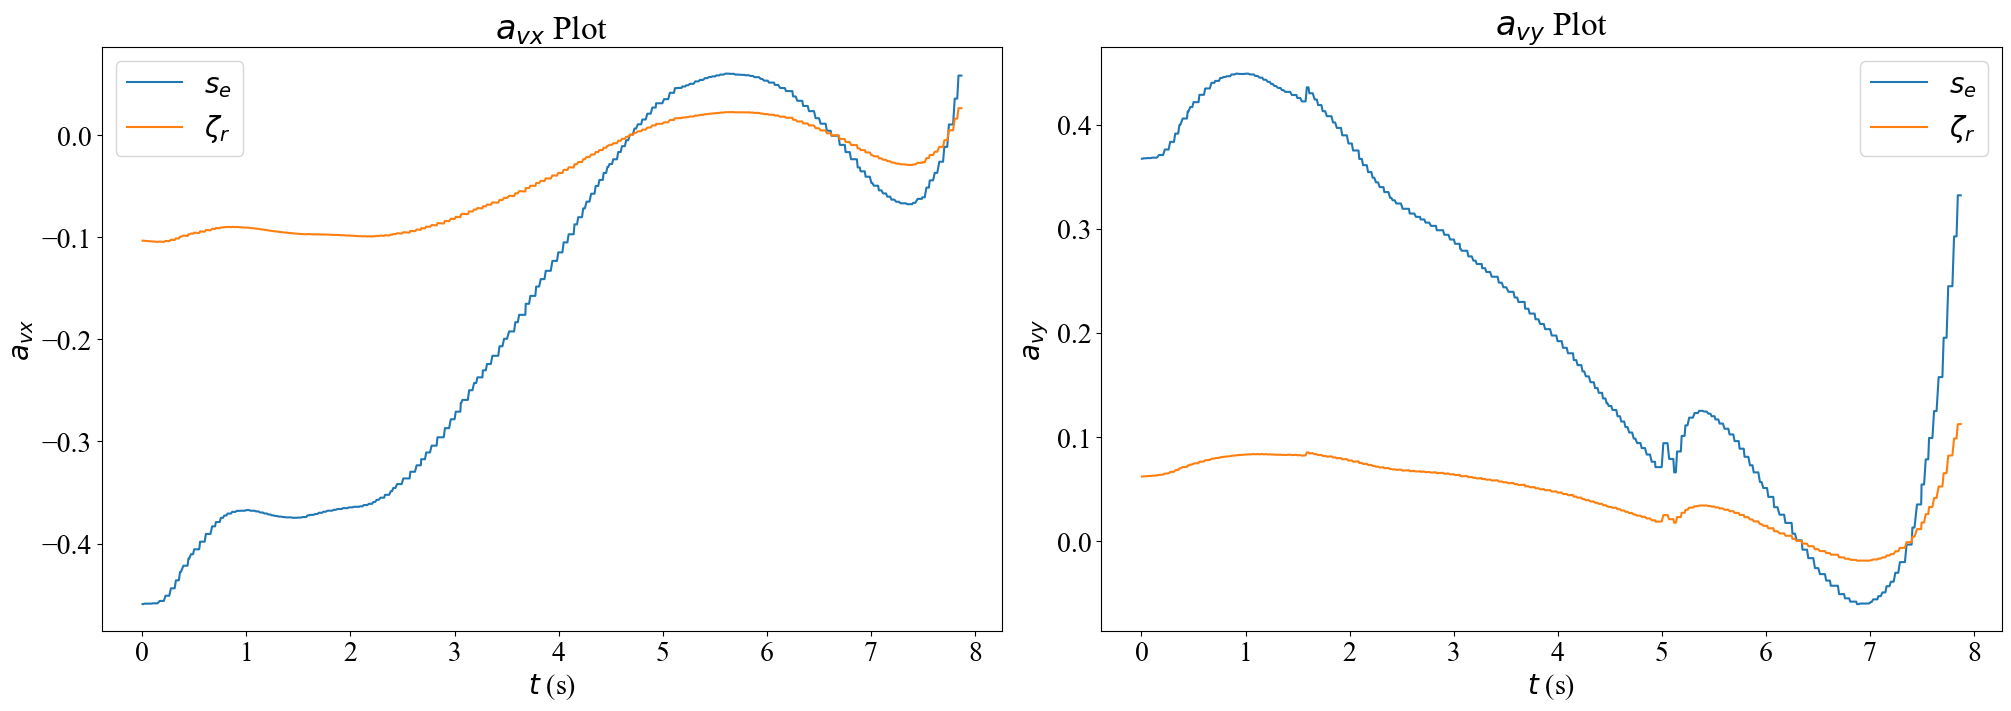

In [62]:
dds_e_filtered = sgf(np.gradient(-ds_e, t_c, axis=0), 11, 2, axis=0)
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = "20"

fig, axes = plt.subplots(1, 2, figsize=(20, 7), constrained_layout=True)
titles  = [r'$a_{vx}$ Plot', r'$a_{vy}$ Plot']
y_labels = [r'$a_{vx}$', r'$a_{vy}$']
for i, ax in enumerate(axes):
    ax.plot(t_c, s[:, i] - s_d[i], label=r'$s_e$')
    if zeta_r is not None:
        ax.plot(t_c, zeta_r[:, i], label=r'$\zeta_r$')
    ax.set_title(titles[i]); ax.set_xlabel(r'$t$ (s)'); ax.set_ylabel(y_labels[i]); ax.legend()
plt.show()
